**An Investigation of Non-Convolutional VAE decoders**

In [14]:
"""
Import PyTorch libraries.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np
import random

In [15]:
"""
Enable CUDA if the GPU is available
"""
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

Ankle Boot


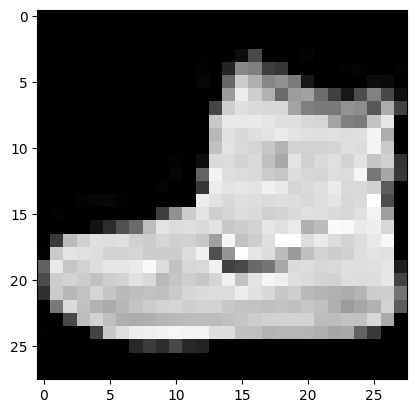

In [16]:
"""
Define the dataloader for the Fashion MNIST dataset.
"""
train_set = torchvision.datasets.FashionMNIST("./data", download=True, transform=
                                                transforms.Compose([transforms.ToTensor()]))
test_set = torchvision.datasets.FashionMNIST("./data", download=True, train=False, transform=
                                               transforms.Compose([transforms.ToTensor()]))
train_loader = torch.utils.data.DataLoader(train_set,
                                           batch_size=100)
test_loader = torch.utils.data.DataLoader(test_set,
                                          batch_size=100)
def output_label(label):
    output_mapping = {
                 0: "T-shirt/Top",
                 1: "Trouser",
                 2: "Pullover",
                 3: "Dress",
                 4: "Coat",
                 5: "Sandal",
                 6: "Shirt",
                 7: "Sneaker",
                 8: "Bag",
                 9: "Ankle Boot"
                 }
    input = (label.item() if type(label) == torch.Tensor else label)
    return output_mapping[input]
image, label = next(iter(train_set))
plt.imshow(image.squeeze(), cmap="gray")
print(output_label(label))

In [17]:
"""
A Convolutional Variational Autoencoder
"""
class VAE(nn.Module):
    def __init__ (self):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.decoder = nn.Sequential (
            nn.Unflatten(1, (128, 3, 3)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        h_dim=1152
        z_dim=64
        self.fc1 = nn.Linear(1152, h_dim)
        self.fc21 = nn.Linear(h_dim, z_dim)
        self.fc22 = nn.Linear(h_dim, z_dim)
        self.fc3 = nn.Linear(z_dim, h_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return (eps*std) + mu

    def bottleneck(self, x):
        mu, logvar = self.fc21(x), self.fc22(x)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def encode(self, x):
        h = self.encoder(x)
        h = F.relu(self.fc1(h))
        return self.bottleneck(h)

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.decoder(h)

    def forward(self, x):
        z, mu, logvar = self.encode(x)
        return z, mu, logvar #Forwards encoded latent vectors

#### Training the VAE

In [18]:
"""
Initialize Hyperparameters
"""
batch_size = 128
learning_rate = 1e-3
num_epochs = 20

"""
Initialize the network and the Adam optimizer
"""

VAEmodel = VAE().to(device)
optimizer = torch.optim.Adam(VAEmodel.parameters(), lr=learning_rate)

"""
Training the network for a given number of epochs
"""
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(train_loader):
        images = images.to(device)

        out, mu, logvar = VAEmodel(images)

        reconst_loss = F.binary_cross_entropy(VAEmodel.decode(out), images, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconst_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ("Epoch[{}/{}], Step [{}/{}], Reconst Loss: {:.4f}, KL Div: {:.4f}"
                   .format(epoch+1, num_epochs, i+1, len(train_loader), reconst_loss.item()/batch_size, kl_loss.item()/batch_size))


Epoch[1/20], Step [100/600], Reconst Loss: 216.5637, KL Div: 10.4368
Epoch[1/20], Step [200/600], Reconst Loss: 207.5192, KL Div: 11.7129
Epoch[1/20], Step [300/600], Reconst Loss: 211.0425, KL Div: 12.9171
Epoch[1/20], Step [400/600], Reconst Loss: 199.9298, KL Div: 11.0777
Epoch[1/20], Step [500/600], Reconst Loss: 195.2001, KL Div: 11.3422
Epoch[1/20], Step [600/600], Reconst Loss: 203.3892, KL Div: 11.1977
Epoch[2/20], Step [100/600], Reconst Loss: 186.5916, KL Div: 10.9504
Epoch[2/20], Step [200/600], Reconst Loss: 188.7409, KL Div: 11.1255
Epoch[2/20], Step [300/600], Reconst Loss: 196.4251, KL Div: 11.0909
Epoch[2/20], Step [400/600], Reconst Loss: 188.1392, KL Div: 10.3738
Epoch[2/20], Step [500/600], Reconst Loss: 185.7547, KL Div: 10.7692
Epoch[2/20], Step [600/600], Reconst Loss: 195.1043, KL Div: 10.4921
Epoch[3/20], Step [100/600], Reconst Loss: 180.7334, KL Div: 10.1642
Epoch[3/20], Step [200/600], Reconst Loss: 184.2699, KL Div: 10.3406
Epoch[3/20], Step [300/600], Recon

#### Visualize the VAE output

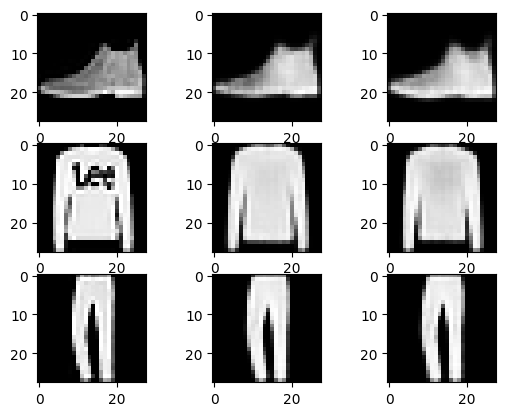

In [19]:
VAEmodel.eval()
with torch.no_grad():
    imgs, _ = list(test_loader)[0]
    imgs = imgs.to(device)
    fig, ax = plt.subplots(3,3)
    ax = ax.reshape(-1)
    for i in range(3):
      for j in range(3):
        if j == 0:
          # input image
          img = np.transpose(imgs[i].cpu().numpy(), [1,2,0])
          ax[i*3+j].imshow(np.squeeze(img), cmap = 'gray')
        else:
          # vae generation results
          out, mu, logVAR = VAEmodel(imgs)
          out = VAEmodel.decode(out)
          outimg = np.transpose(out[i].cpu().numpy(), [1,2,0])
          ax[i*3+j].imshow(np.squeeze(outimg), cmap = 'gray')
    plt.show()


In [25]:
class MLPDecoder(nn.Module):
    def __init__(self, z_dim=64, img_size=28):
        super(MLPDecoder, self).__init__()
        self.img_size = img_size
        self.z_dim = z_dim

        # Simple MLP
        self.mlp = nn.Sequential(
            nn.Linear(z_dim + 2, 128),  # Latent vector + 2D coordinates (x, y)
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, z, coords):
        # z: Latent vector
        # coords: 2D coordinates (x, y)
        input_tensor = torch.cat((z, coords), dim=-1)  # Concatenate latent vector with coord
        return self.mlp(input_tensor)  # Output pixel value


In [26]:
class VAEWithDecoder(nn.Module):
    def __init__(self, vae, decoder):
        super(VAEWithDecoder, self).__init__()
        self.vae = vae
        self.decoder = decoder

    def generate_image(self, z):
        # Generate an image via decoding
        image = torch.zeros((1, 28, 28))  # 28x28 image size
        for i in range(28):
            for j in range(28):
                coords = torch.tensor([[i, j]], dtype=torch.float32).to(z.device)
                pixel_value = self.decoder(z, coords)  # Get pixel value for (i, j)
                image[0, i, j] = pixel_value
        return image

    def forward(self, x):
        # Forward pass through VAE
        out, mu, logvar = self.vae(x)
        return out, mu, logvar


#### Training the MLP Decoder

In [27]:
"""
Initialize Hyperparameters
"""
batch_size = 128
learning_rate = 1e-3
num_epochs = 20

"""
Initialize the network and the Adam optimizer
"""
# z_dim is 64 as in VAE definition
z_dim = 64

# initialize the original VAE model and the MLP Decoder
vae = VAEmodel  # original VAE model
mlpDecoder = MLPDecoder(z_dim=z_dim).to(device)  # MLP Decoder

# wrap both in VAEWithDecoder
MLPVaeModel = VAEWithDecoder(vae, mlpDecoder).to(device)

In [30]:
model = MLPVaeModel

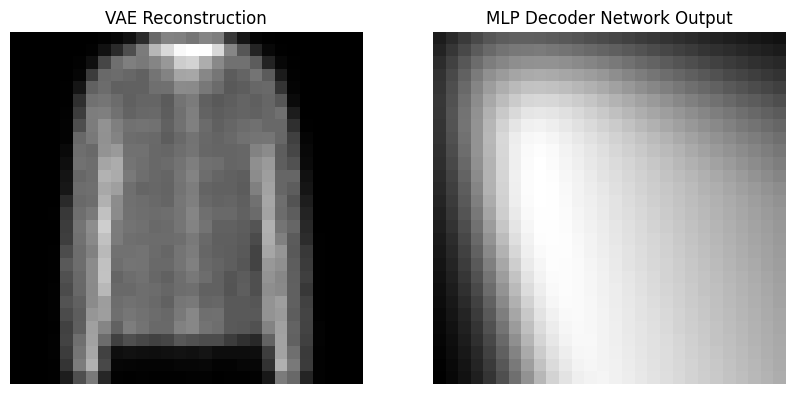

Epoch [1/20], Step [100/600], Loss: 1493.1608


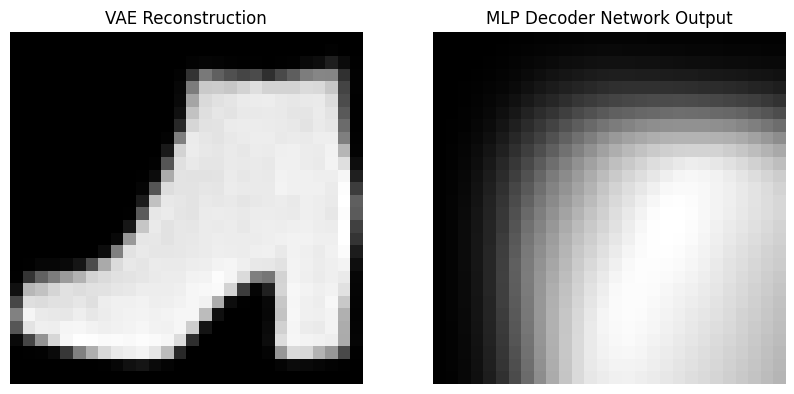

Epoch [1/20], Step [200/600], Loss: 1504.9227


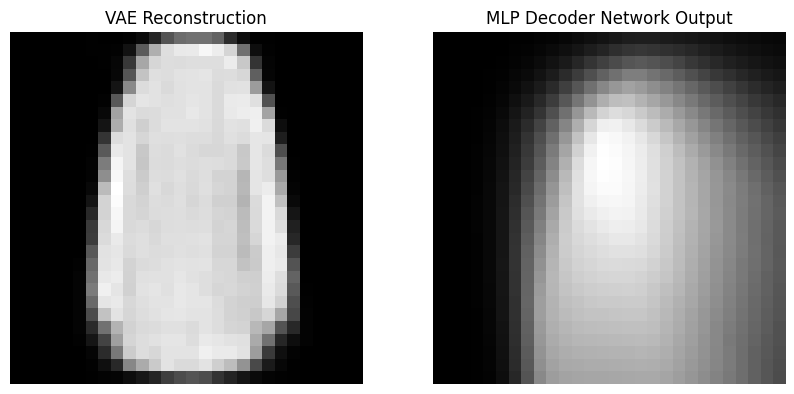

Epoch [1/20], Step [300/600], Loss: 1522.7297


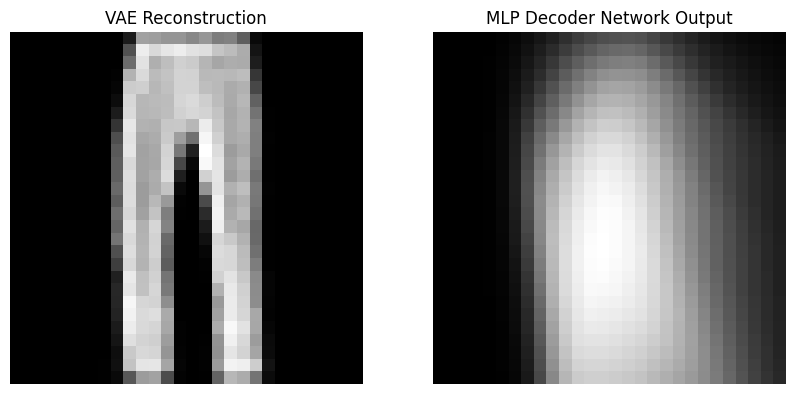

Epoch [1/20], Step [400/600], Loss: 1478.6058


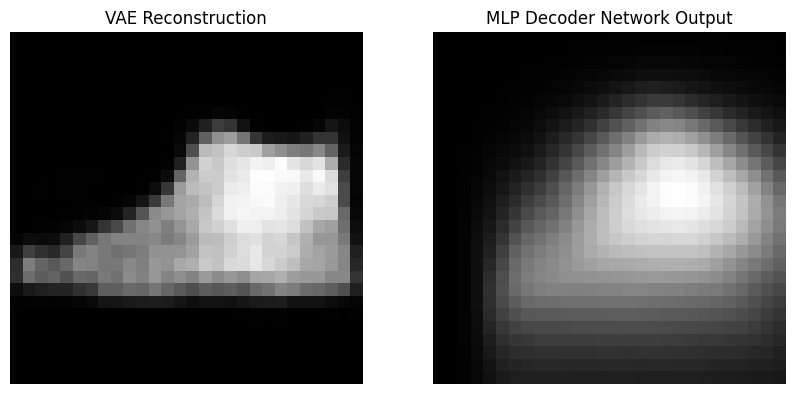

Epoch [1/20], Step [500/600], Loss: 1491.8805


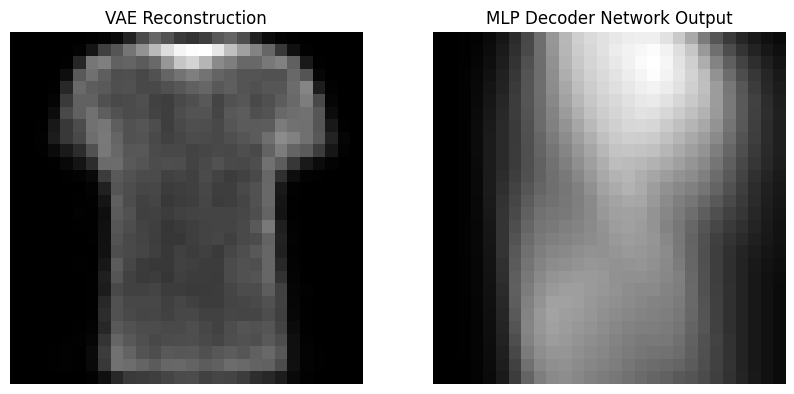

Epoch [1/20], Step [600/600], Loss: 1482.8097


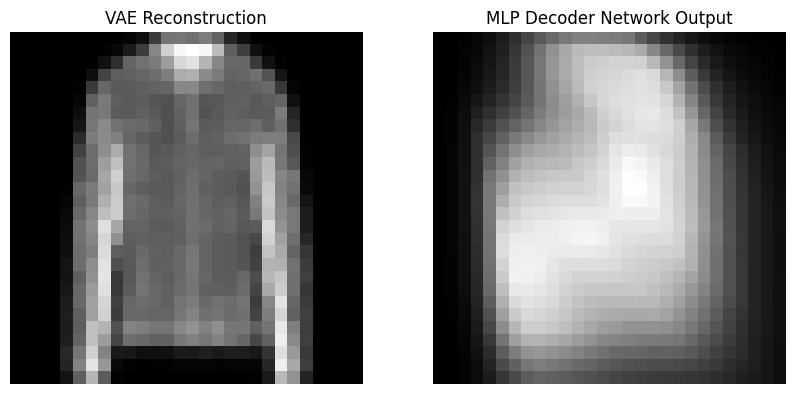

Epoch [2/20], Step [100/600], Loss: 1493.1102


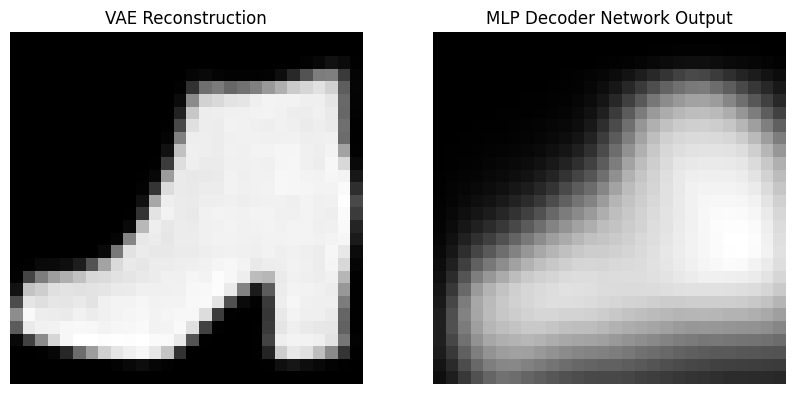

Epoch [2/20], Step [200/600], Loss: 1504.8885


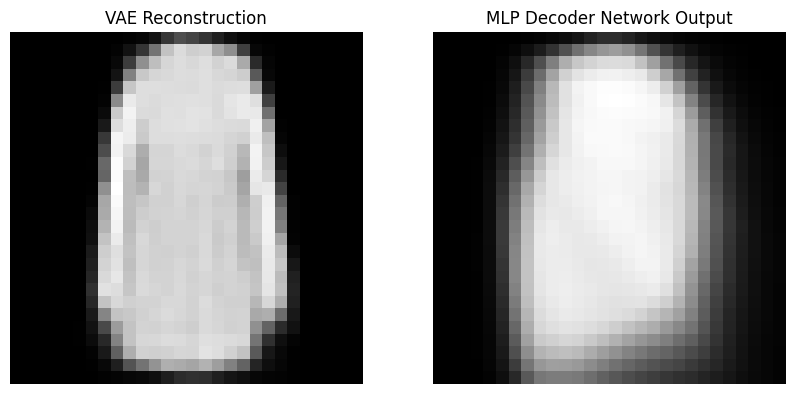

Epoch [2/20], Step [300/600], Loss: 1522.7026


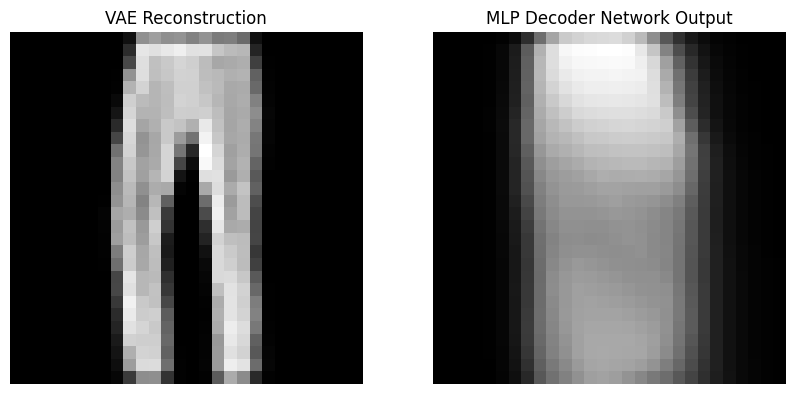

Epoch [2/20], Step [400/600], Loss: 1478.5870


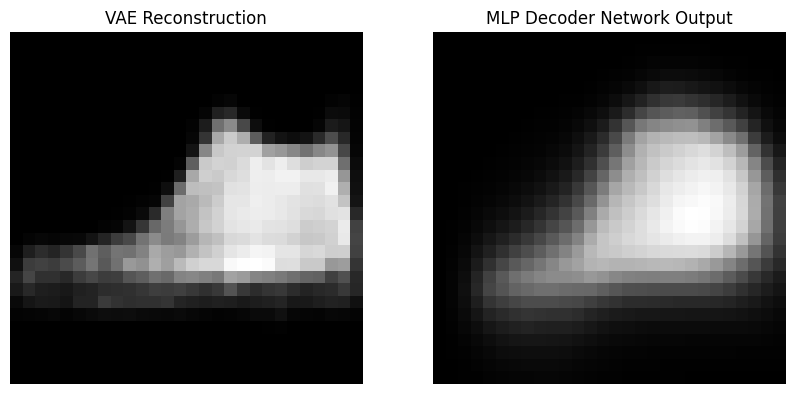

Epoch [2/20], Step [500/600], Loss: 1491.8639


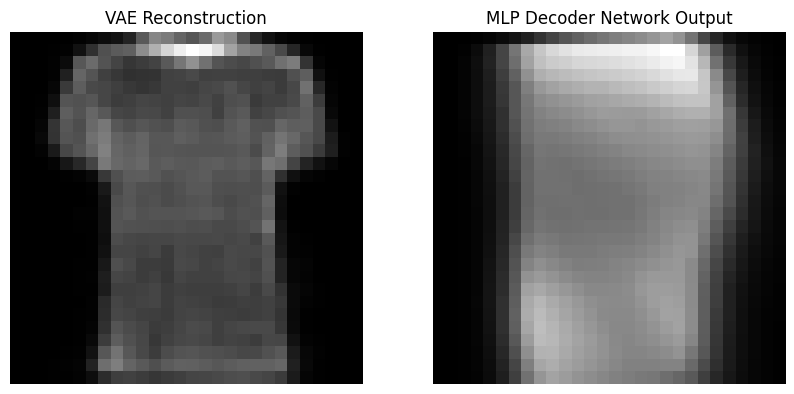

Epoch [2/20], Step [600/600], Loss: 1482.7965


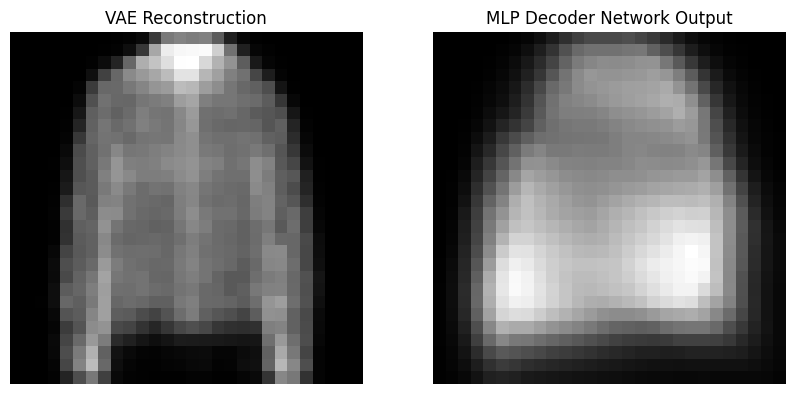

Epoch [3/20], Step [100/600], Loss: 1493.1008


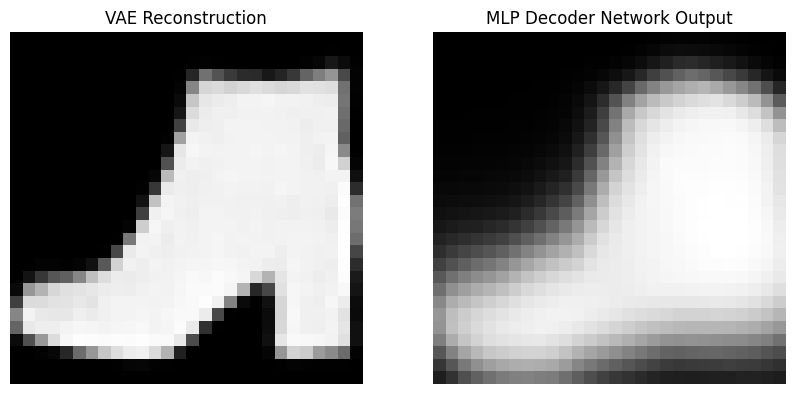

Epoch [3/20], Step [200/600], Loss: 1504.8811


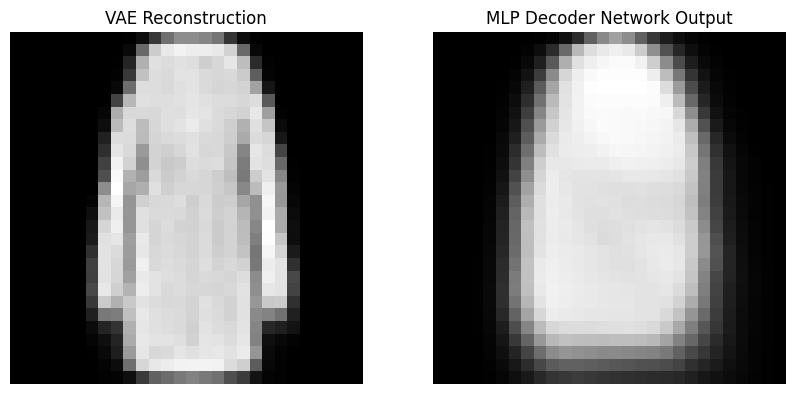

Epoch [3/20], Step [300/600], Loss: 1522.6957


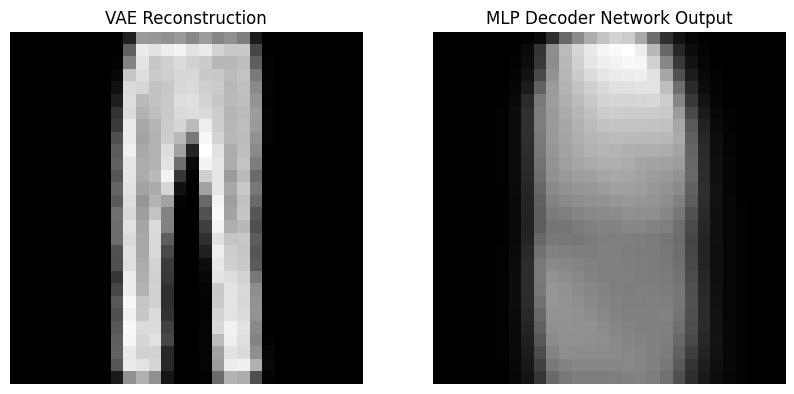

Epoch [3/20], Step [400/600], Loss: 1478.5829


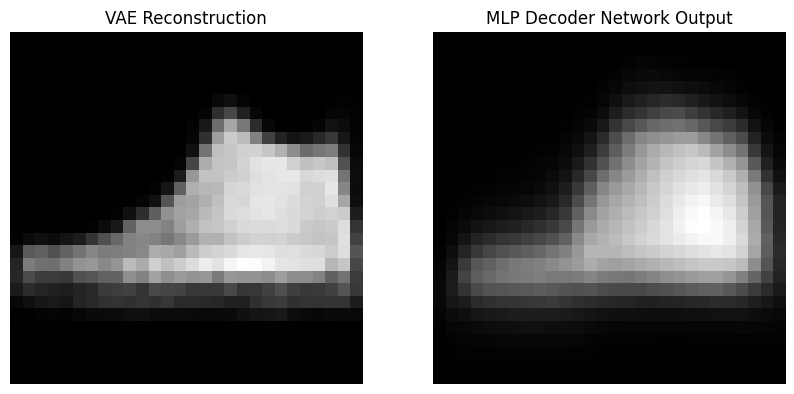

Epoch [3/20], Step [500/600], Loss: 1491.8584


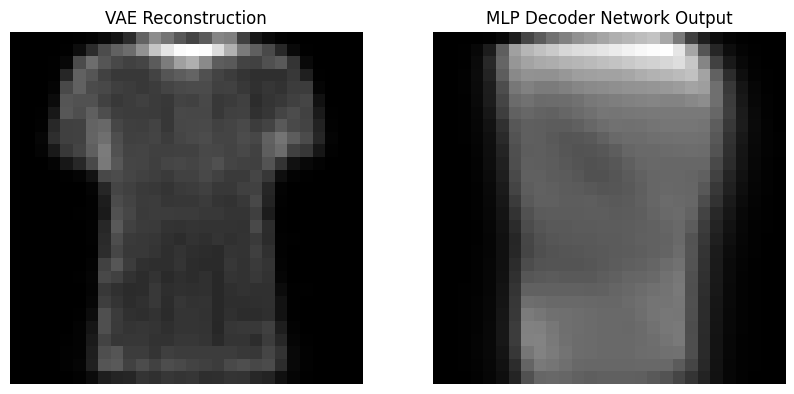

Epoch [3/20], Step [600/600], Loss: 1482.7927


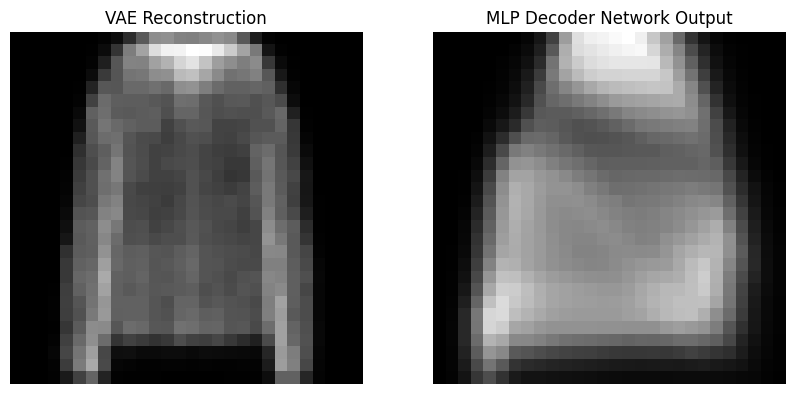

Epoch [4/20], Step [100/600], Loss: 1493.0968


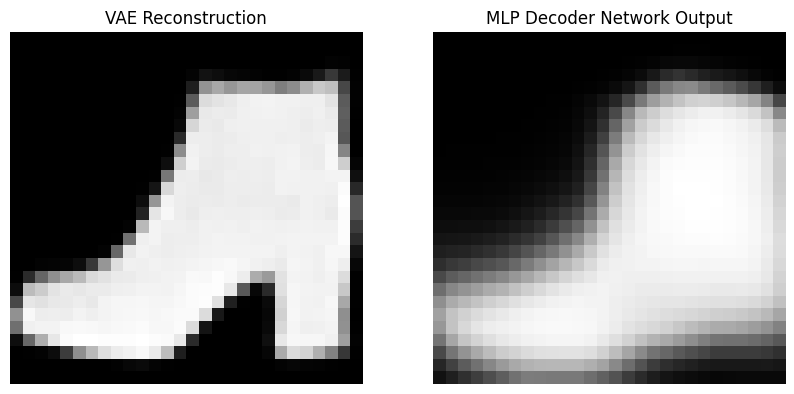

Epoch [4/20], Step [200/600], Loss: 1504.8782


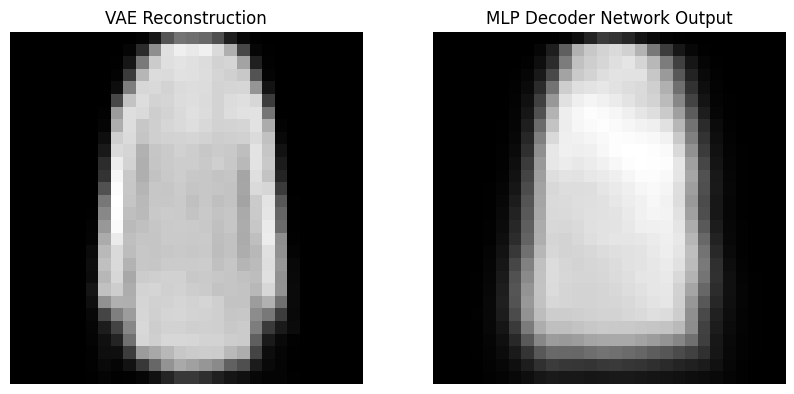

Epoch [4/20], Step [300/600], Loss: 1522.6926


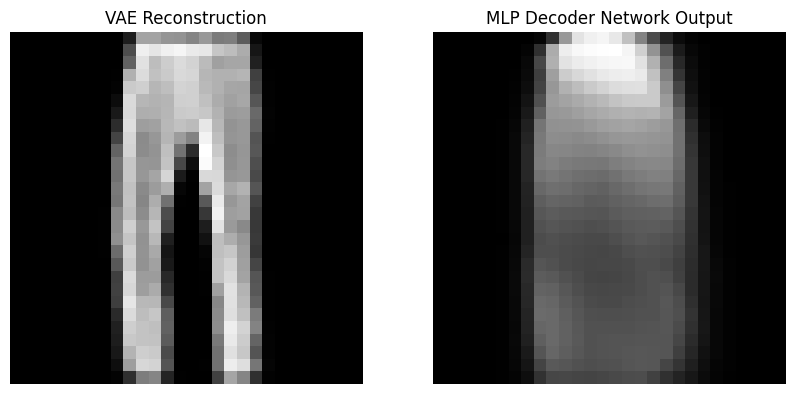

Epoch [4/20], Step [400/600], Loss: 1478.5812


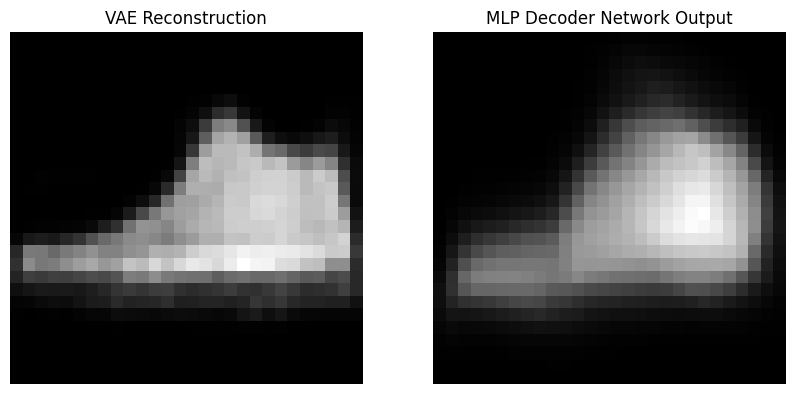

Epoch [4/20], Step [500/600], Loss: 1491.8566


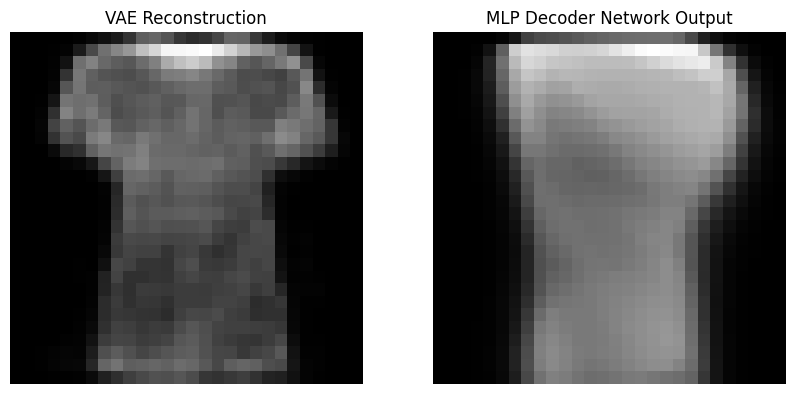

Epoch [4/20], Step [600/600], Loss: 1482.7905


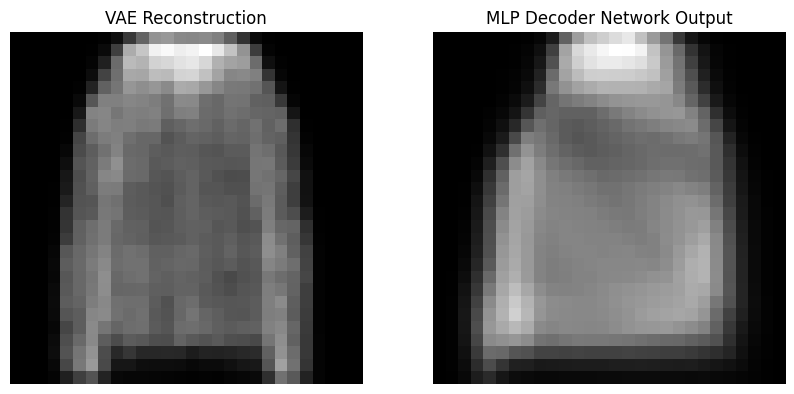

Epoch [5/20], Step [100/600], Loss: 1493.0951


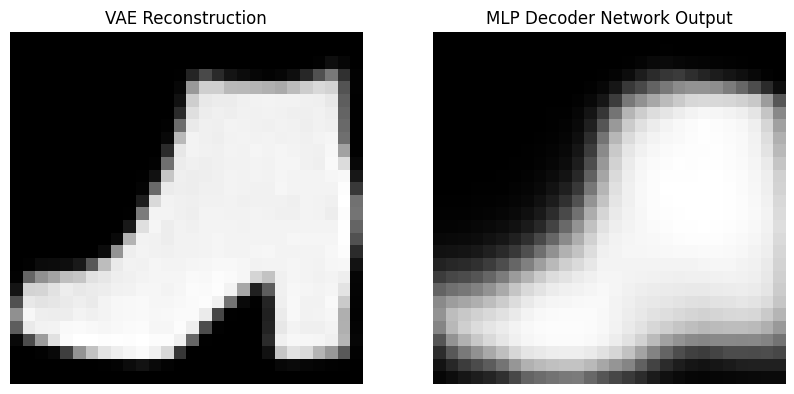

Epoch [5/20], Step [200/600], Loss: 1504.8765


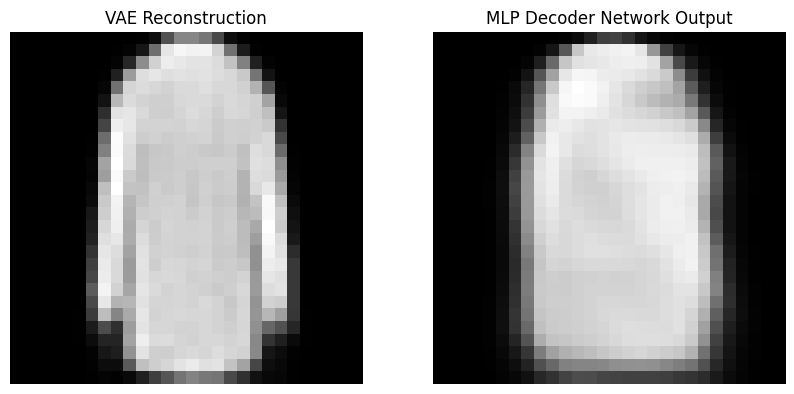

Epoch [5/20], Step [300/600], Loss: 1522.6907


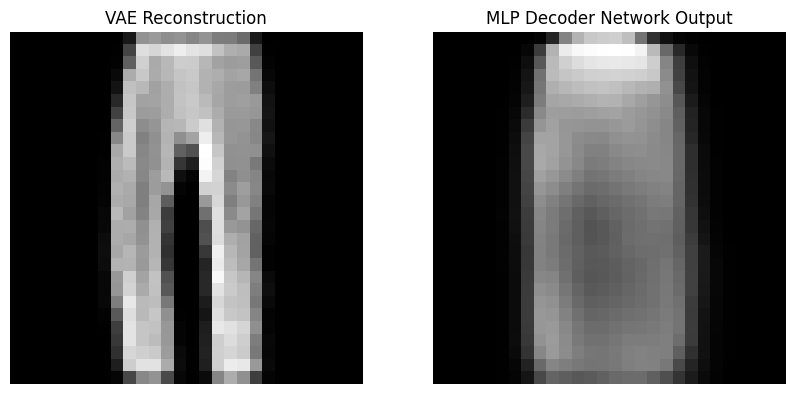

Epoch [5/20], Step [400/600], Loss: 1478.5791


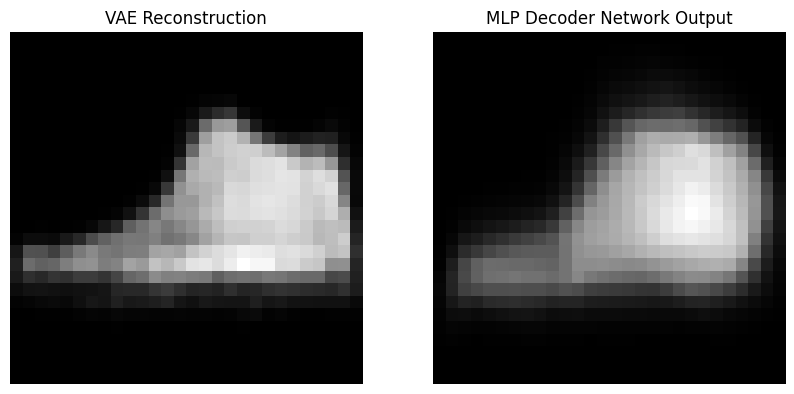

Epoch [5/20], Step [500/600], Loss: 1491.8546


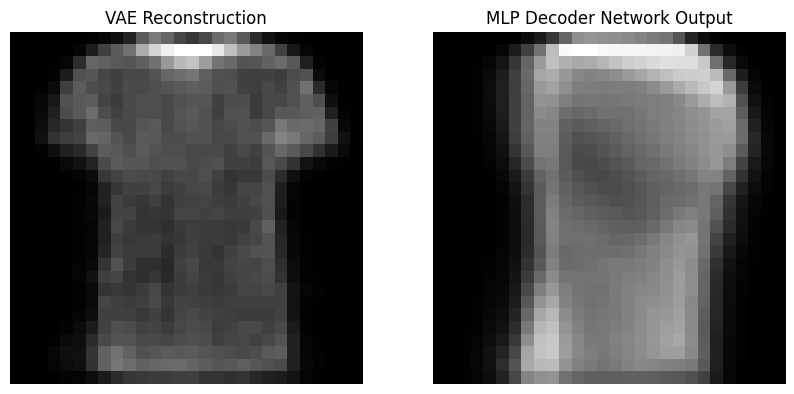

Epoch [5/20], Step [600/600], Loss: 1482.7894


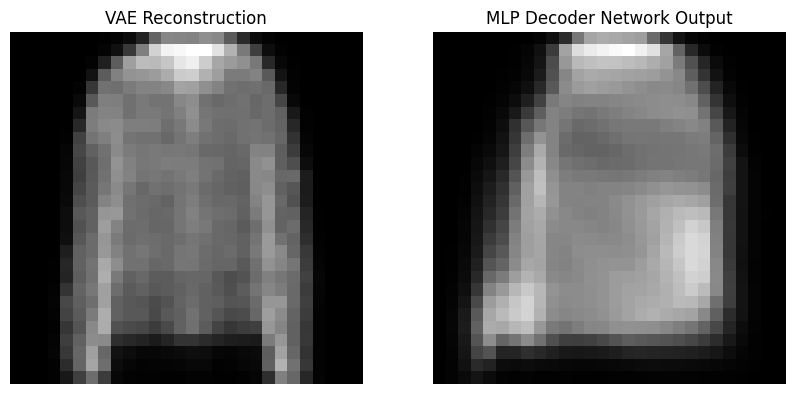

Epoch [6/20], Step [100/600], Loss: 1493.0938


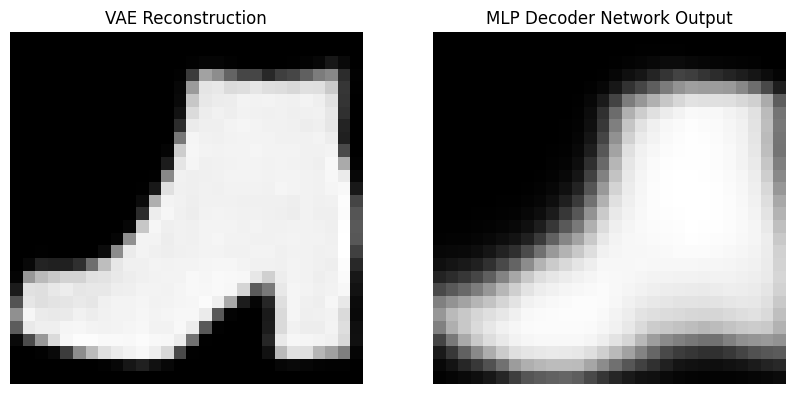

Epoch [6/20], Step [200/600], Loss: 1504.8759


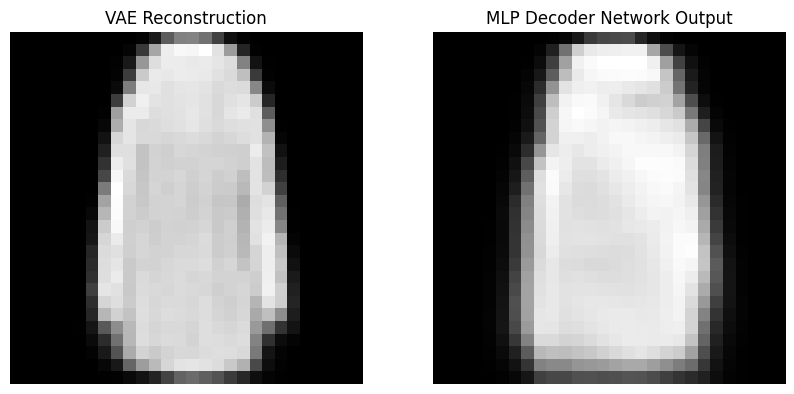

Epoch [6/20], Step [300/600], Loss: 1522.6890


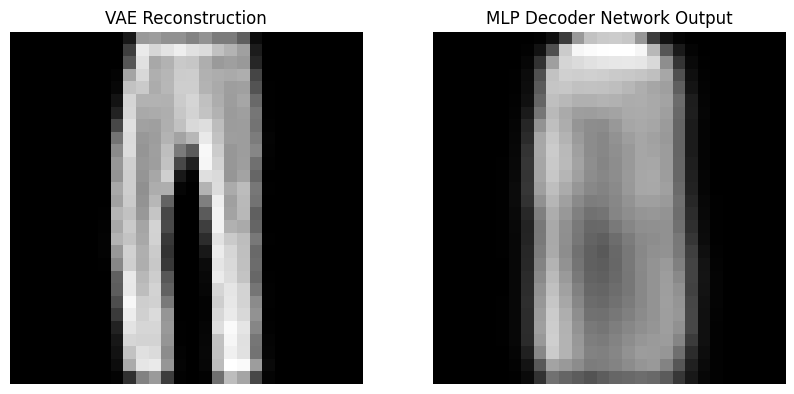

Epoch [6/20], Step [400/600], Loss: 1478.5782


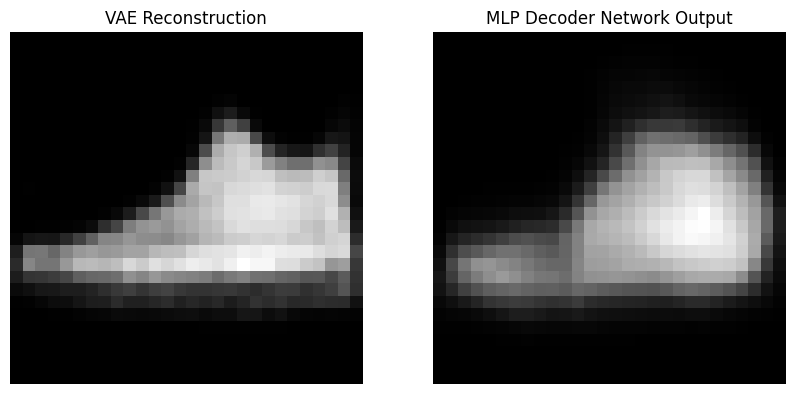

Epoch [6/20], Step [500/600], Loss: 1491.8545


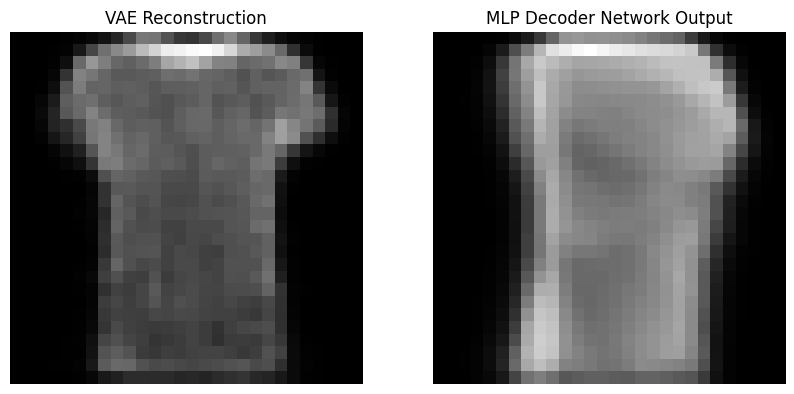

Epoch [6/20], Step [600/600], Loss: 1482.7881


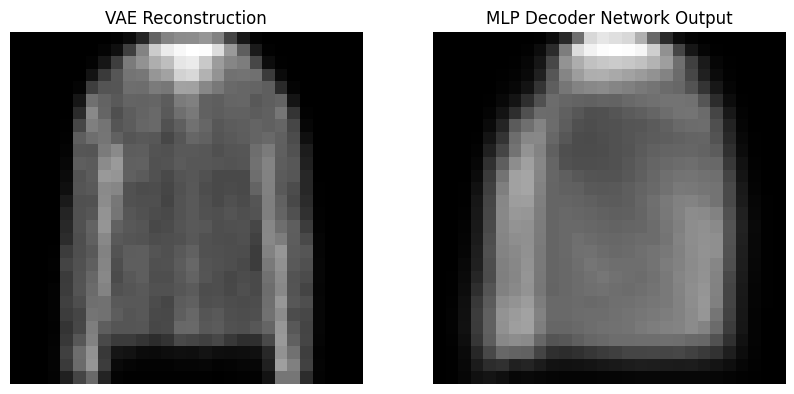

Epoch [7/20], Step [100/600], Loss: 1493.0929


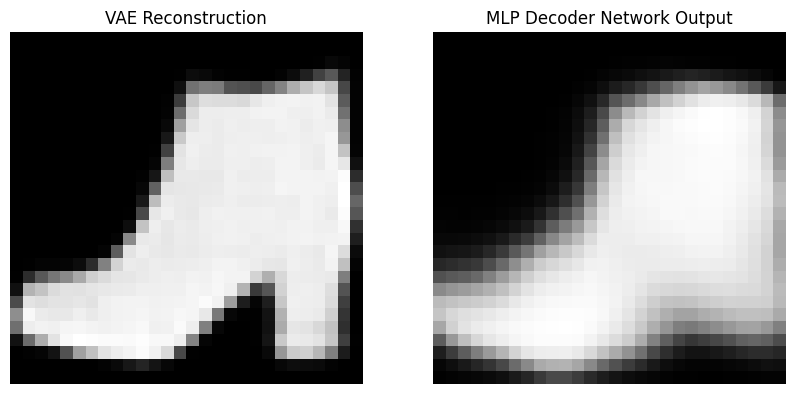

Epoch [7/20], Step [200/600], Loss: 1504.8741


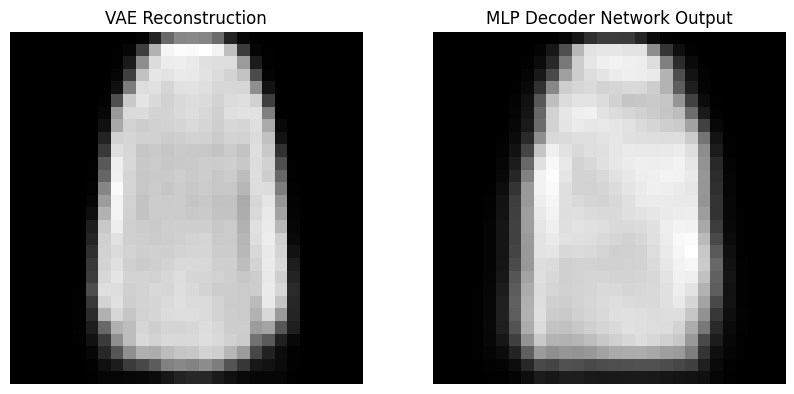

Epoch [7/20], Step [300/600], Loss: 1522.6880


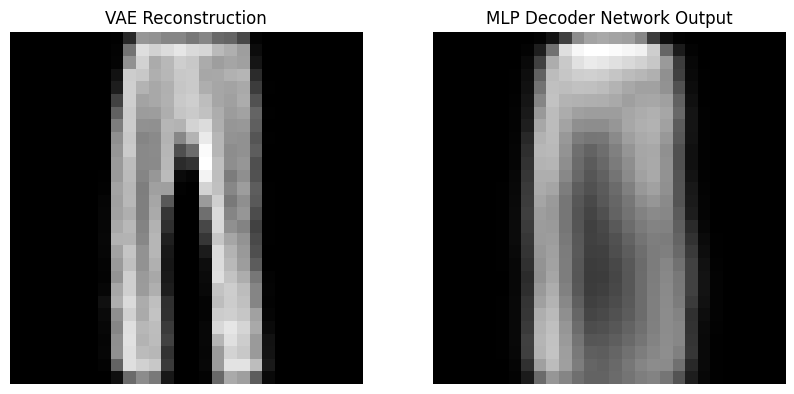

Epoch [7/20], Step [400/600], Loss: 1478.5771


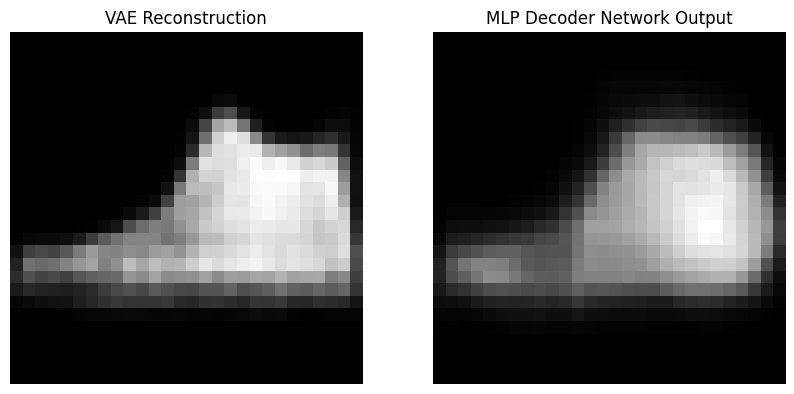

Epoch [7/20], Step [500/600], Loss: 1491.8533


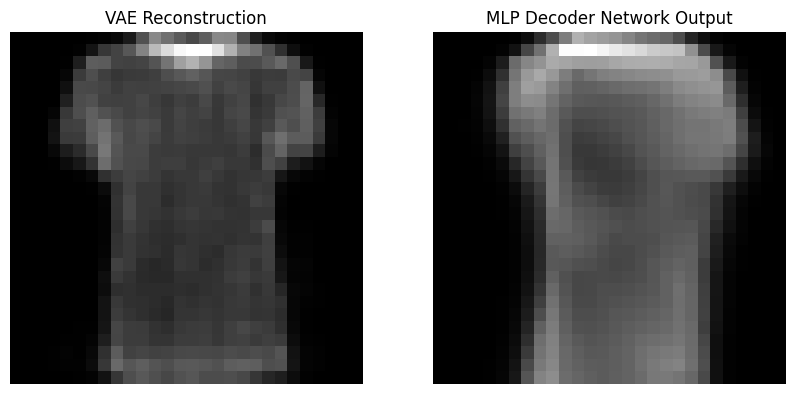

Epoch [7/20], Step [600/600], Loss: 1482.7875


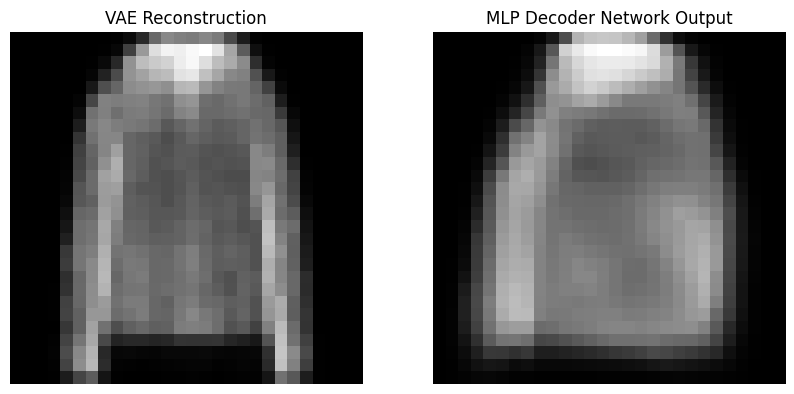

Epoch [8/20], Step [100/600], Loss: 1493.0918


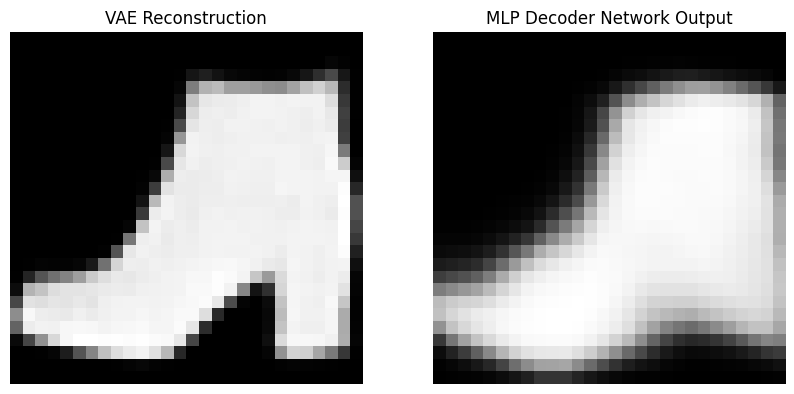

Epoch [8/20], Step [200/600], Loss: 1504.8732


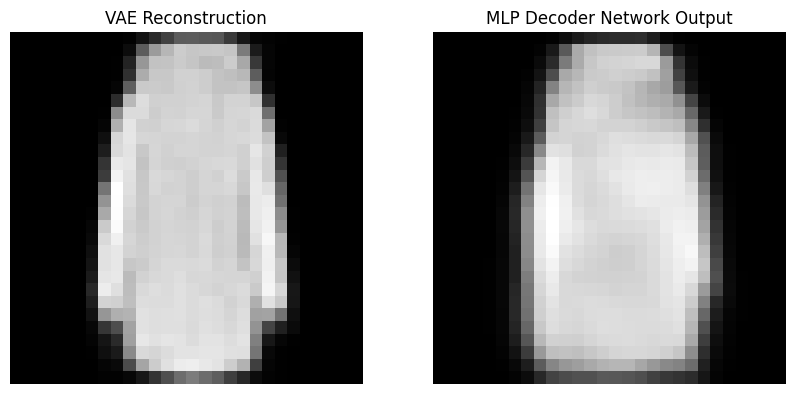

Epoch [8/20], Step [300/600], Loss: 1522.6871


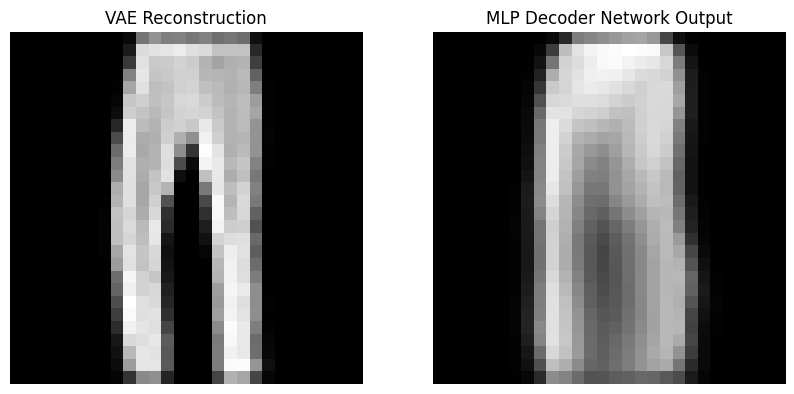

Epoch [8/20], Step [400/600], Loss: 1478.5763


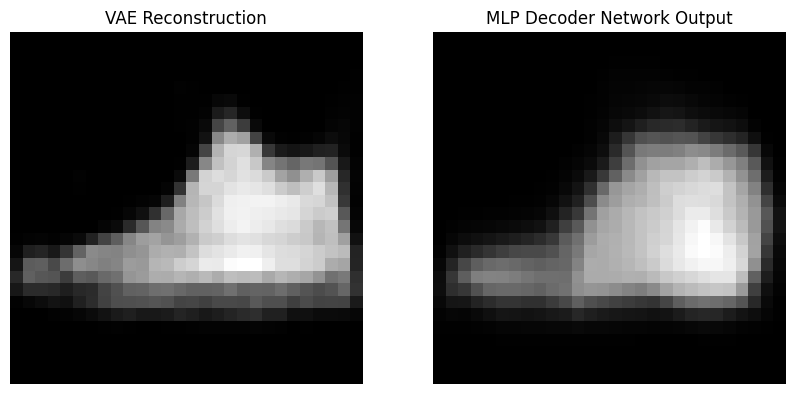

Epoch [8/20], Step [500/600], Loss: 1491.8525


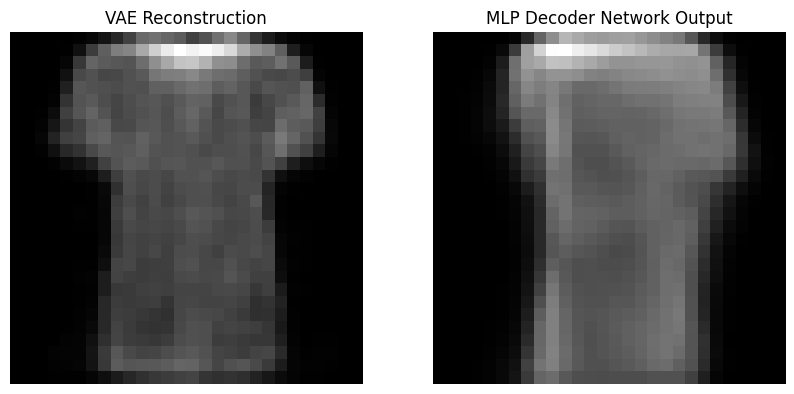

Epoch [8/20], Step [600/600], Loss: 1482.7865


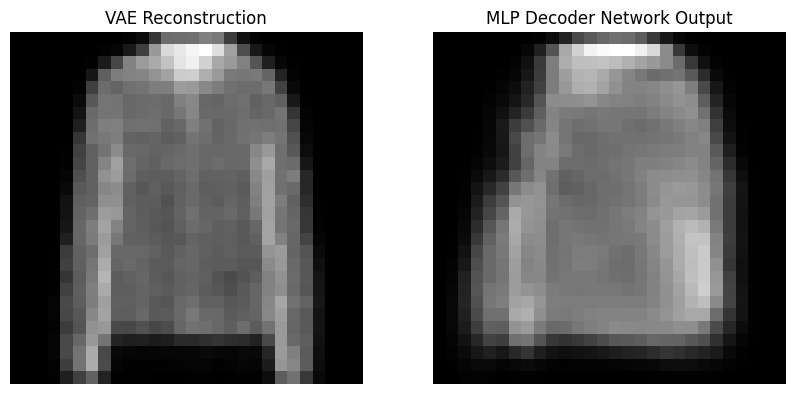

Epoch [9/20], Step [100/600], Loss: 1493.0911


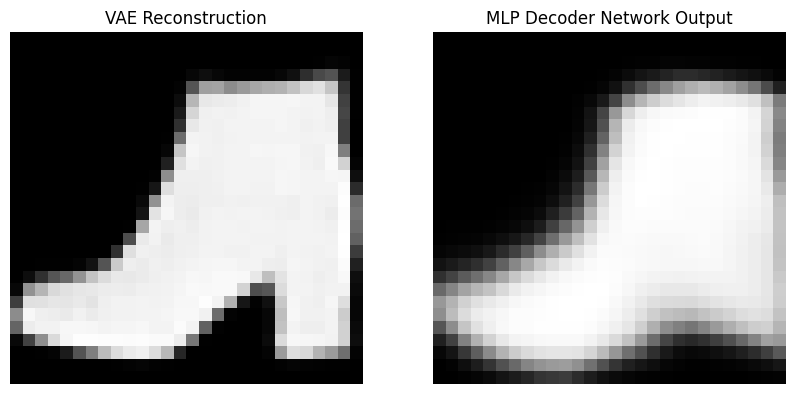

Epoch [9/20], Step [200/600], Loss: 1504.8732


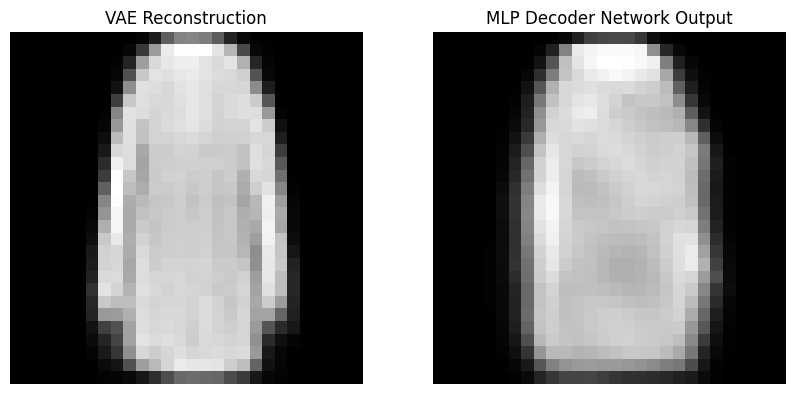

Epoch [9/20], Step [300/600], Loss: 1522.6866


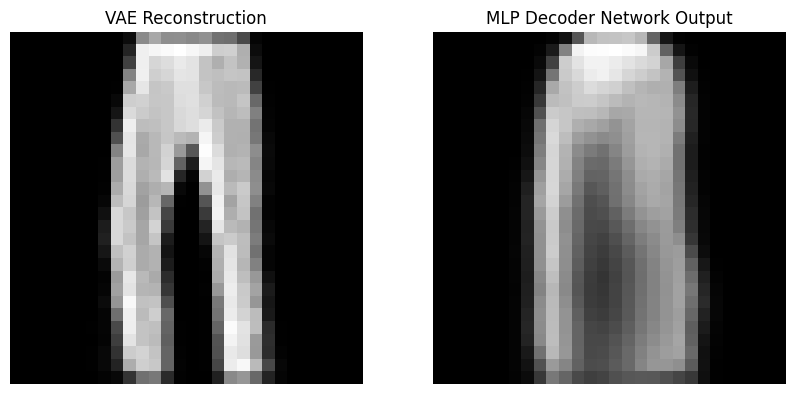

Epoch [9/20], Step [400/600], Loss: 1478.5754


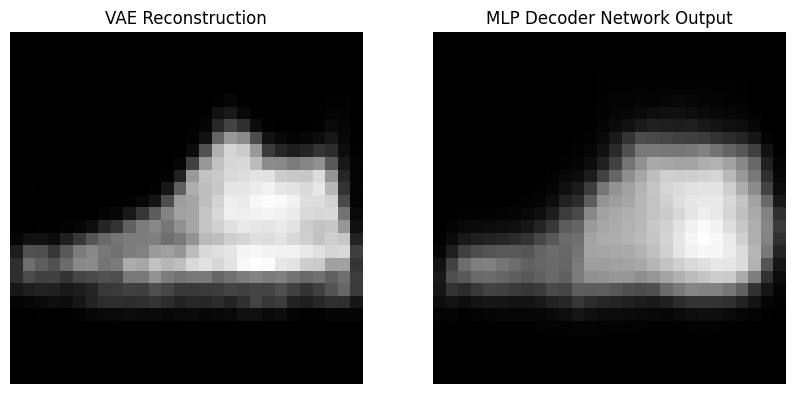

Epoch [9/20], Step [500/600], Loss: 1491.8521


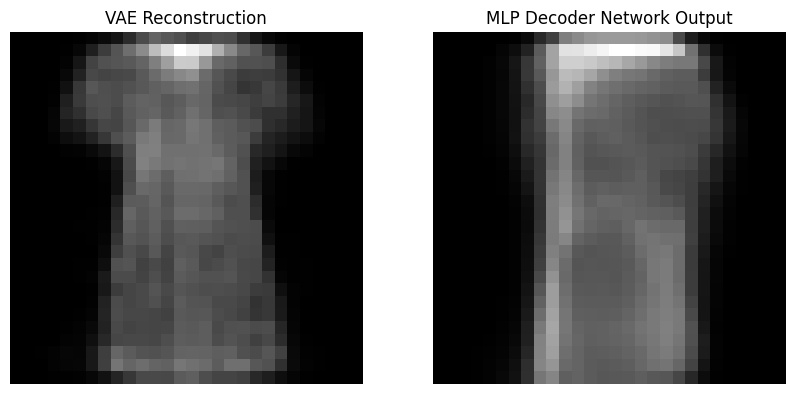

Epoch [9/20], Step [600/600], Loss: 1482.7860


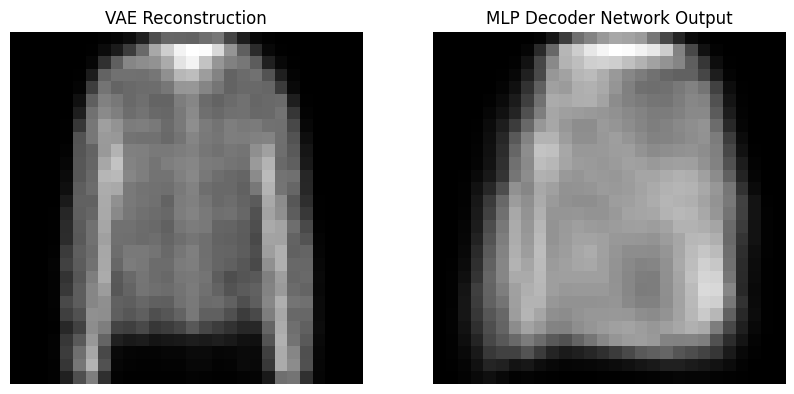

Epoch [10/20], Step [100/600], Loss: 1493.0906


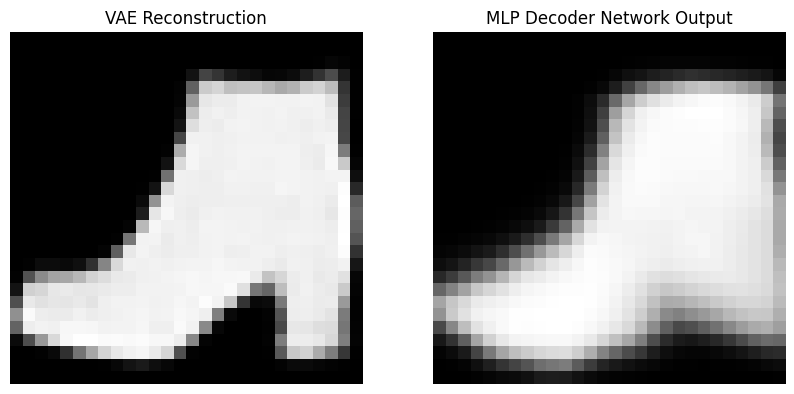

Epoch [10/20], Step [200/600], Loss: 1504.8721


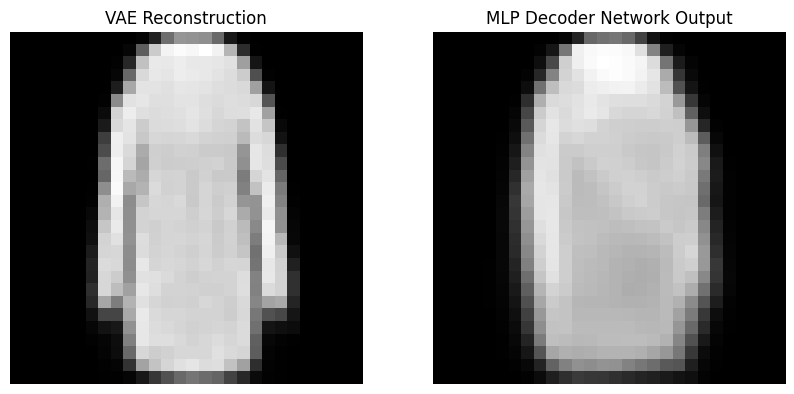

Epoch [10/20], Step [300/600], Loss: 1522.6863


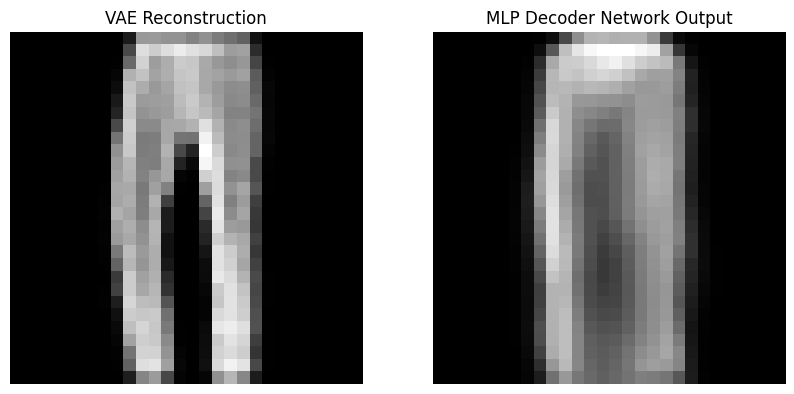

Epoch [10/20], Step [400/600], Loss: 1478.5748


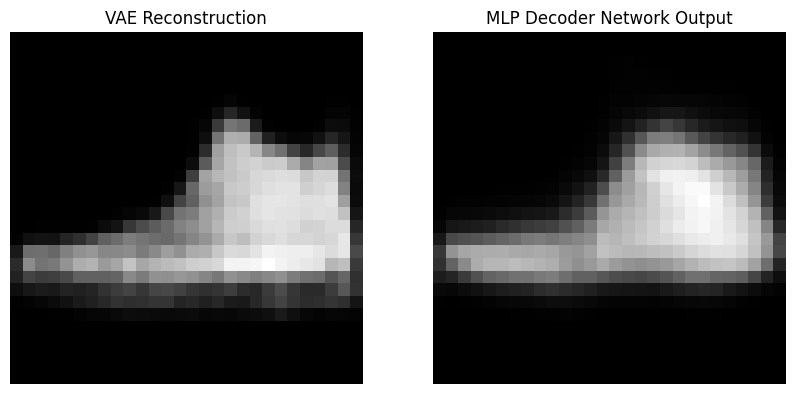

Epoch [10/20], Step [500/600], Loss: 1491.8522


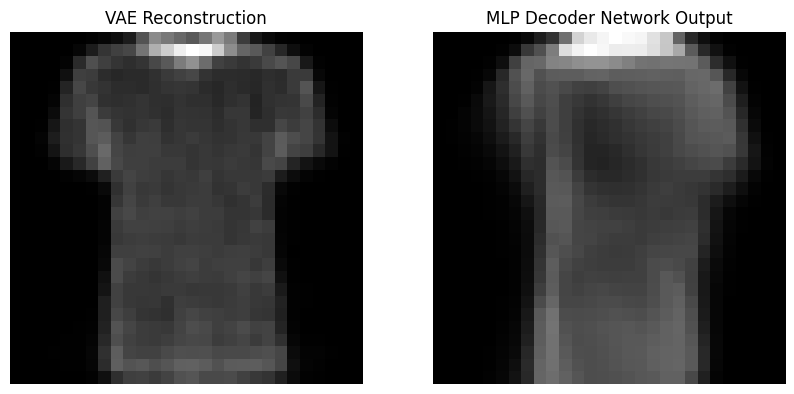

Epoch [10/20], Step [600/600], Loss: 1482.7855


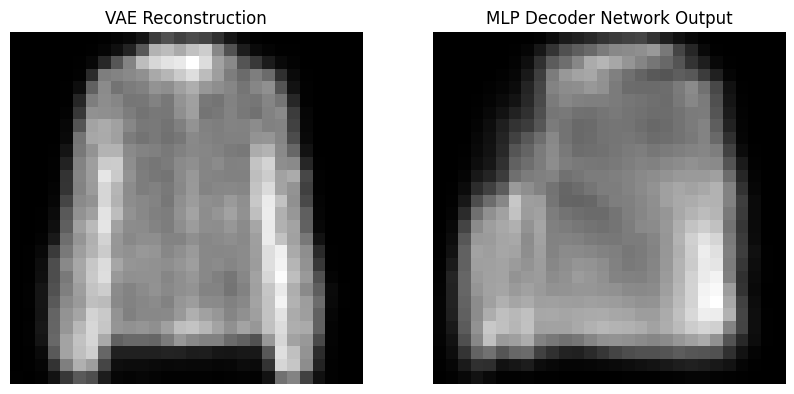

Epoch [11/20], Step [100/600], Loss: 1493.0901


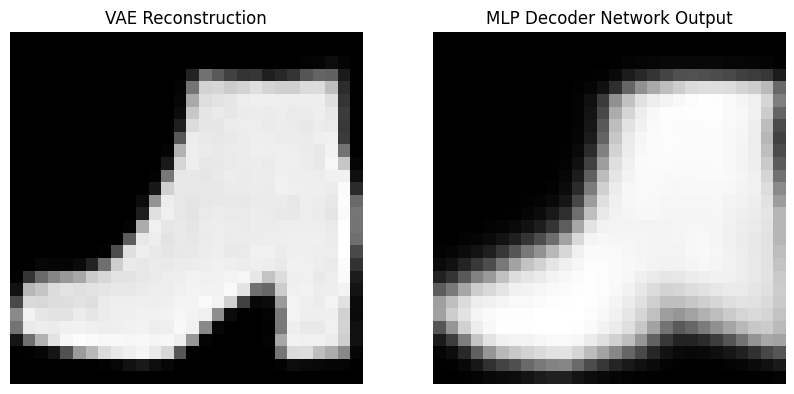

Epoch [11/20], Step [200/600], Loss: 1504.8718


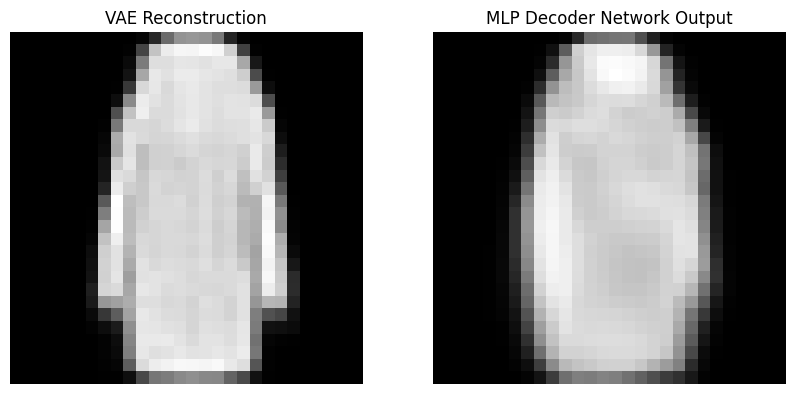

Epoch [11/20], Step [300/600], Loss: 1522.6855


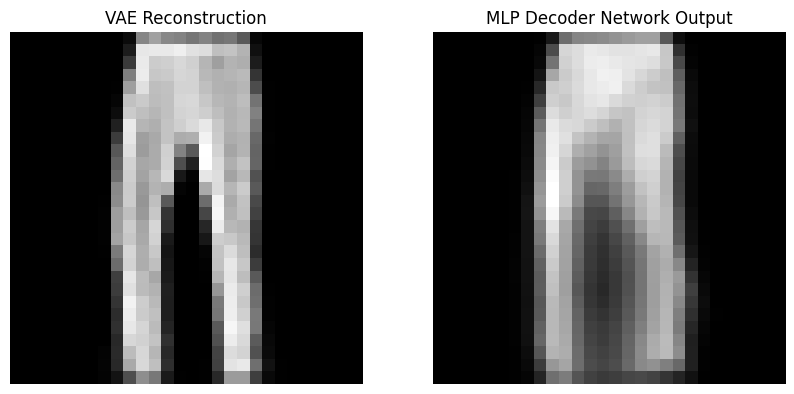

Epoch [11/20], Step [400/600], Loss: 1478.5753


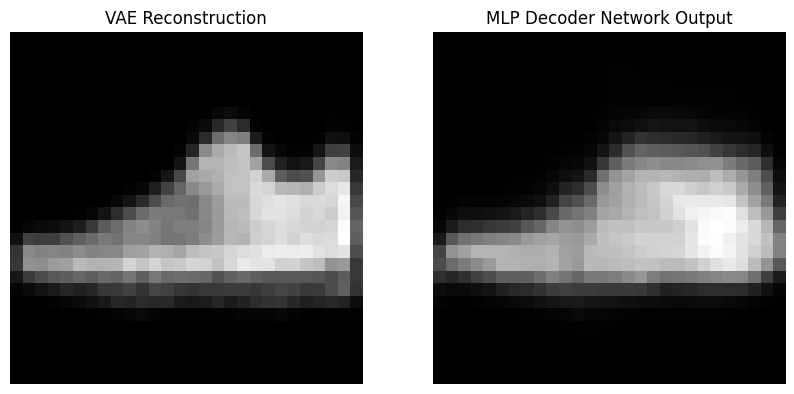

Epoch [11/20], Step [500/600], Loss: 1491.8511


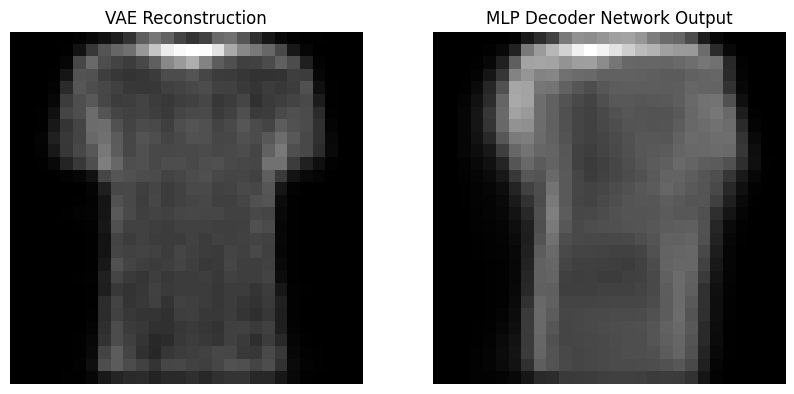

Epoch [11/20], Step [600/600], Loss: 1482.7852


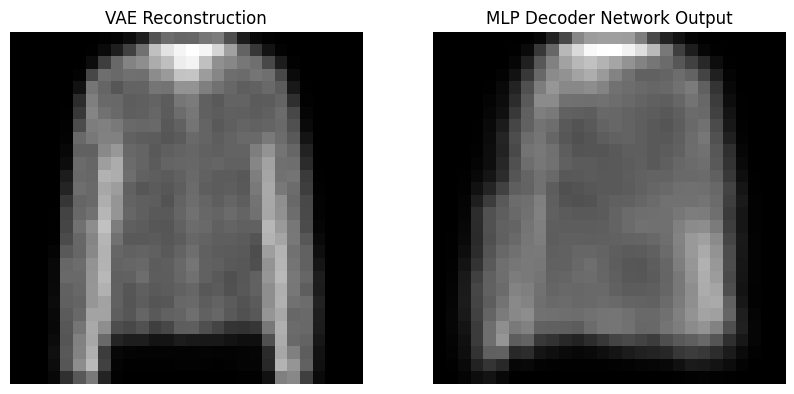

Epoch [12/20], Step [100/600], Loss: 1493.0896


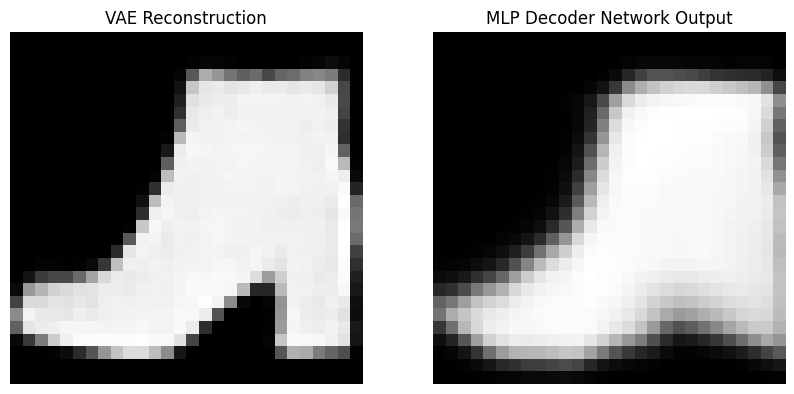

Epoch [12/20], Step [200/600], Loss: 1504.8715


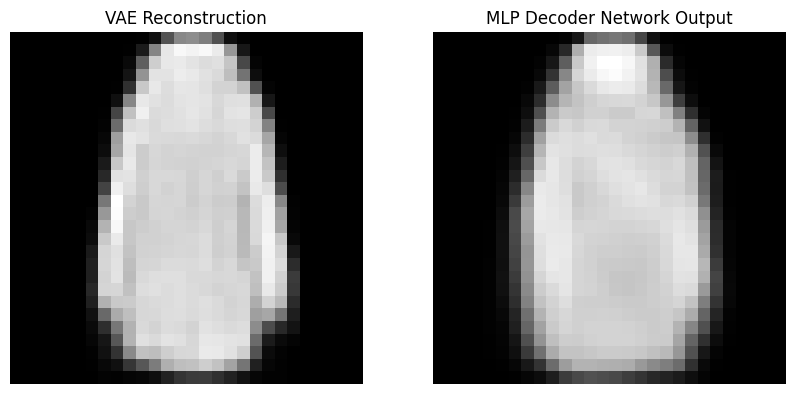

Epoch [12/20], Step [300/600], Loss: 1522.6853


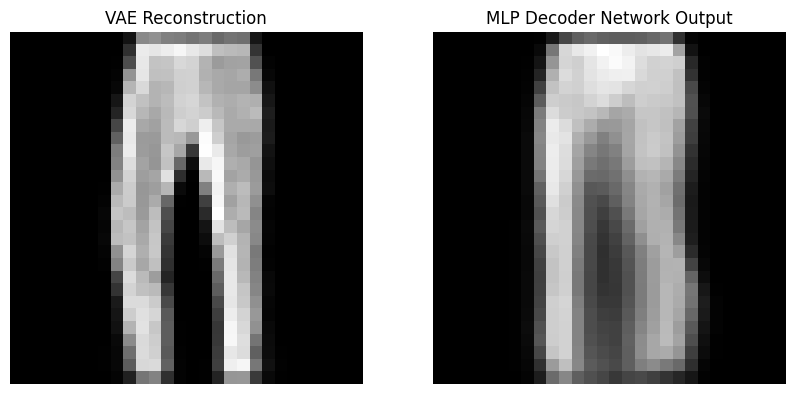

Epoch [12/20], Step [400/600], Loss: 1478.5743


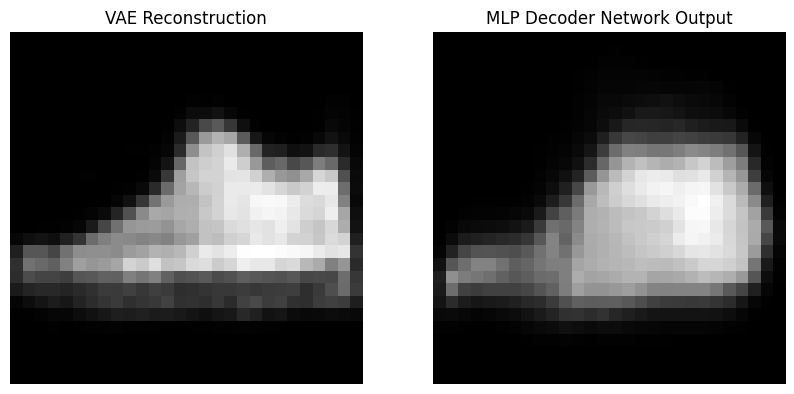

Epoch [12/20], Step [500/600], Loss: 1491.8510


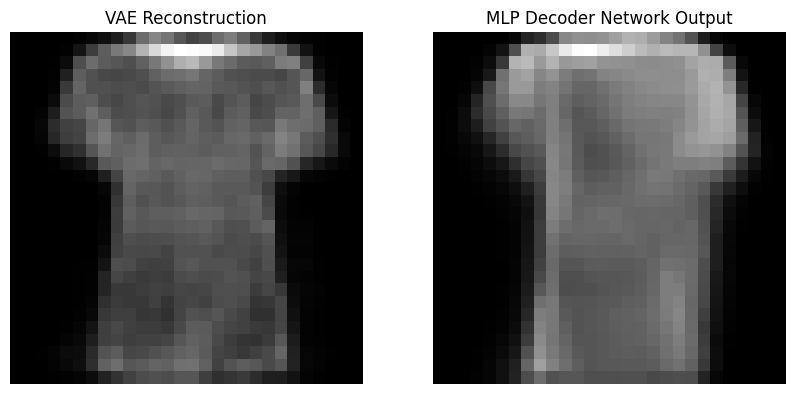

Epoch [12/20], Step [600/600], Loss: 1482.7848


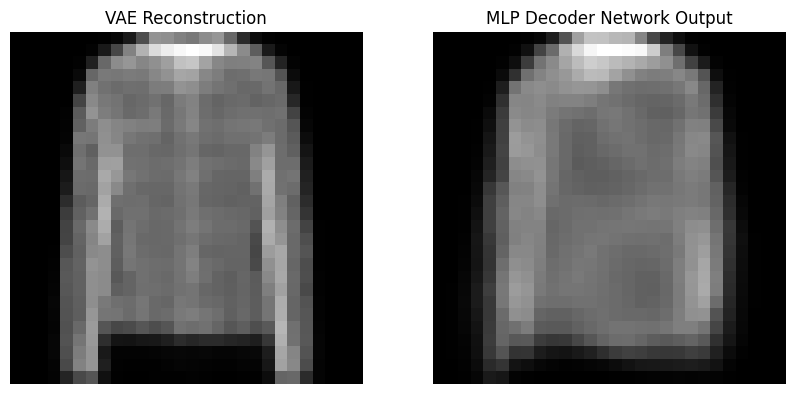

Epoch [13/20], Step [100/600], Loss: 1493.0895


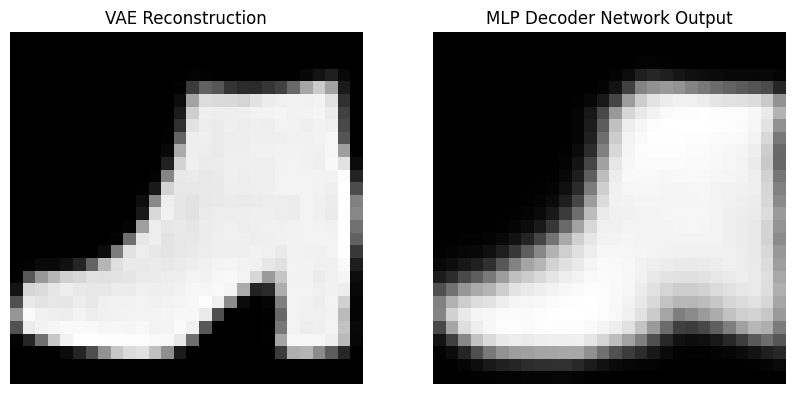

Epoch [13/20], Step [200/600], Loss: 1504.8715


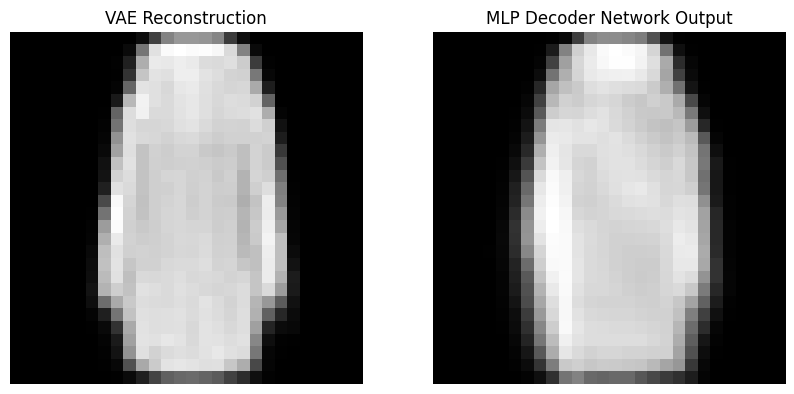

Epoch [13/20], Step [300/600], Loss: 1522.6851


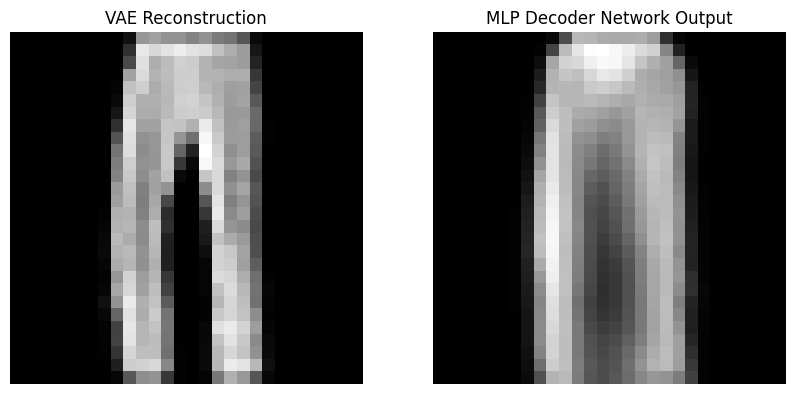

Epoch [13/20], Step [400/600], Loss: 1478.5742


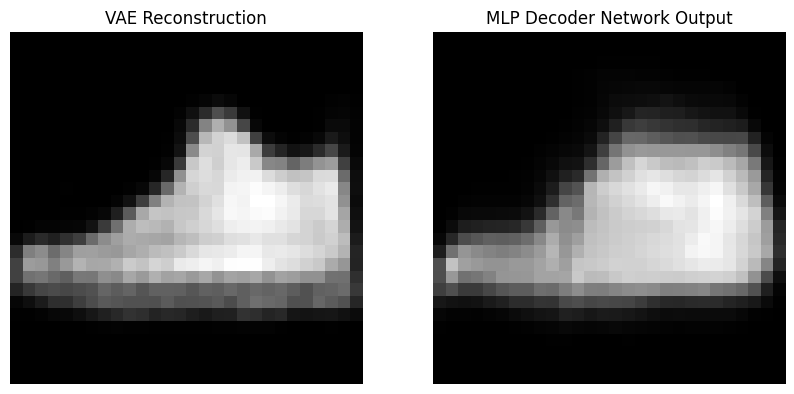

Epoch [13/20], Step [500/600], Loss: 1491.8505


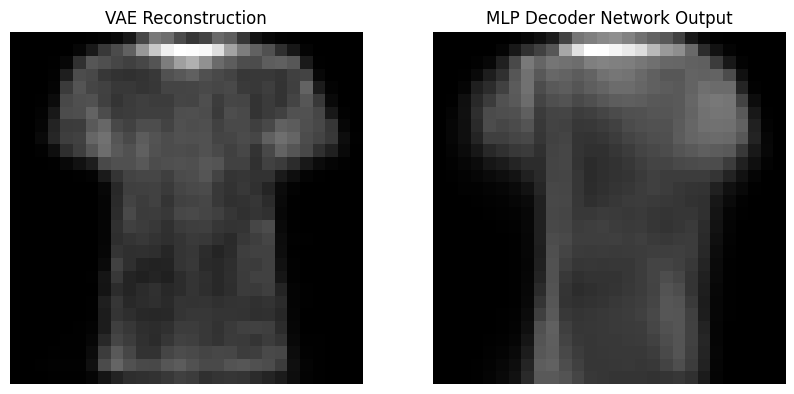

Epoch [13/20], Step [600/600], Loss: 1482.7842


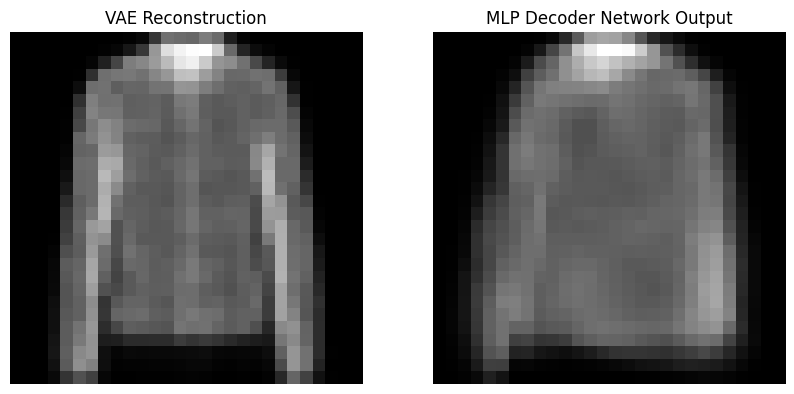

Epoch [14/20], Step [100/600], Loss: 1493.0896


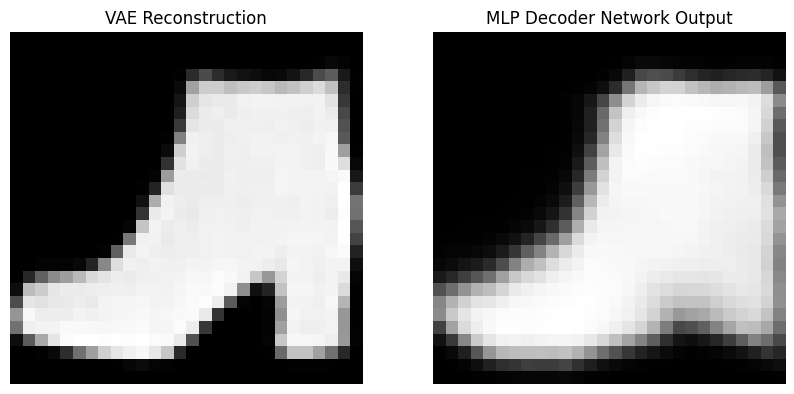

Epoch [14/20], Step [200/600], Loss: 1504.8710


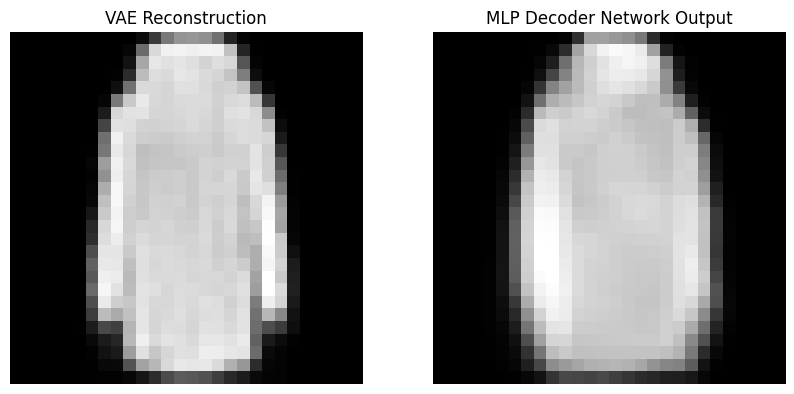

Epoch [14/20], Step [300/600], Loss: 1522.6847


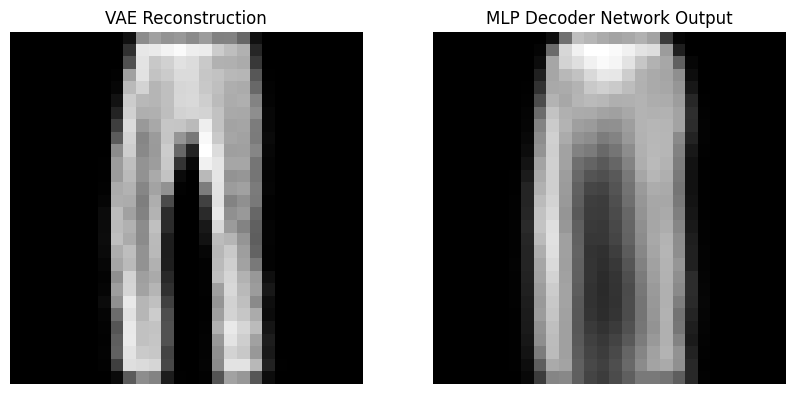

Epoch [14/20], Step [400/600], Loss: 1478.5742


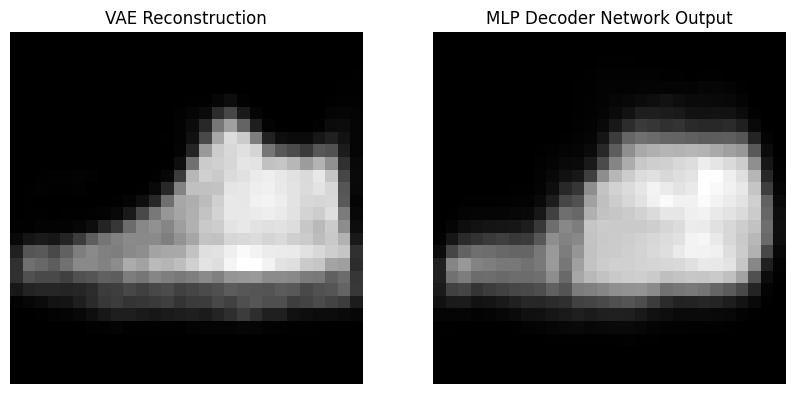

Epoch [14/20], Step [500/600], Loss: 1491.8505


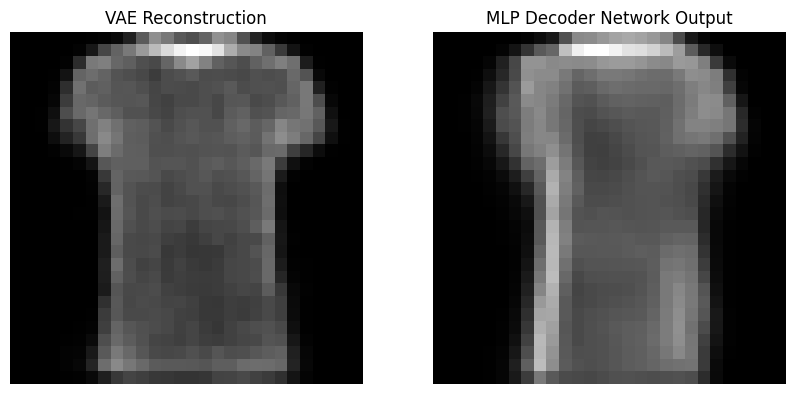

Epoch [14/20], Step [600/600], Loss: 1482.7845


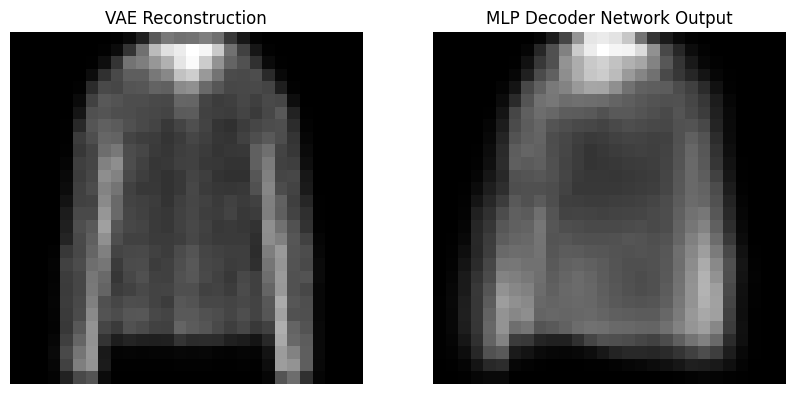

Epoch [15/20], Step [100/600], Loss: 1493.0890


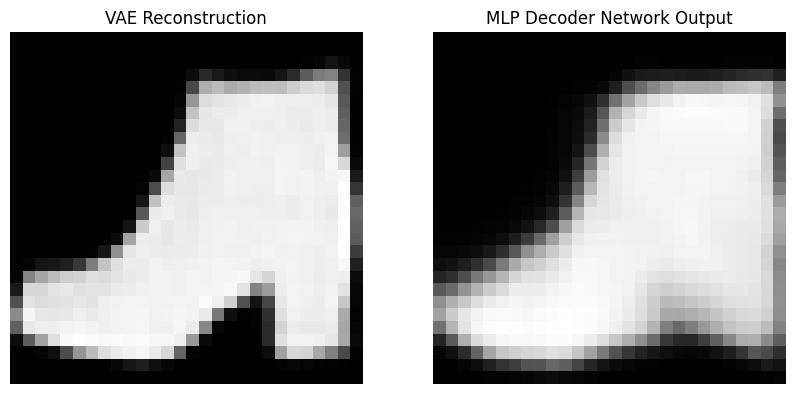

Epoch [15/20], Step [200/600], Loss: 1504.8708


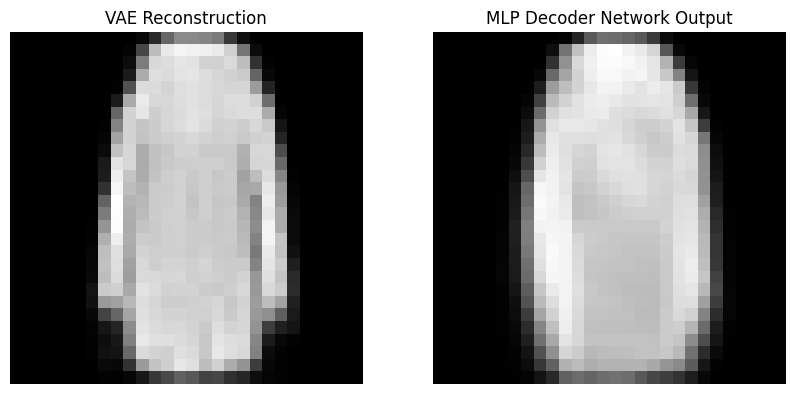

Epoch [15/20], Step [300/600], Loss: 1522.6848


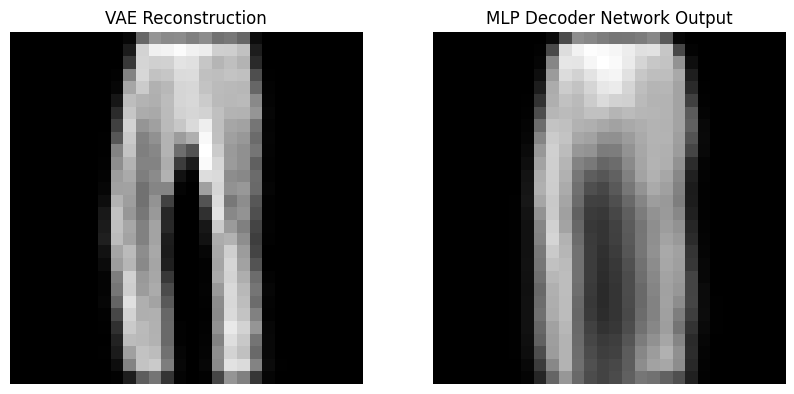

Epoch [15/20], Step [400/600], Loss: 1478.5736


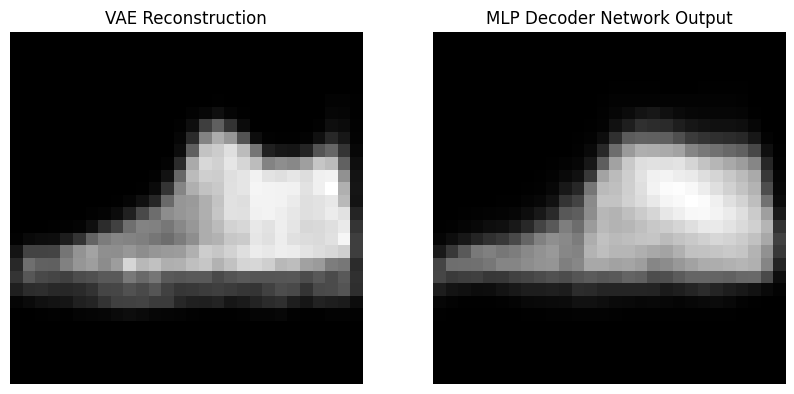

Epoch [15/20], Step [500/600], Loss: 1491.8502


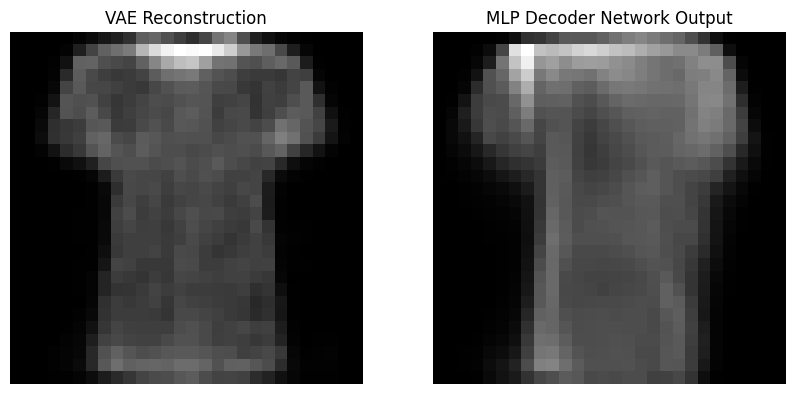

Epoch [15/20], Step [600/600], Loss: 1482.7841


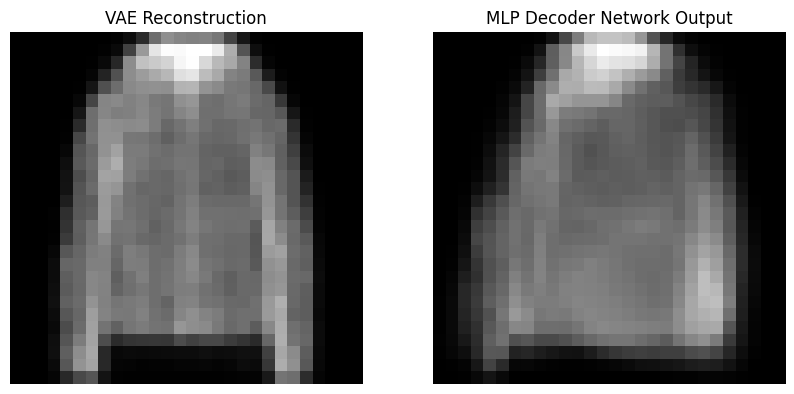

Epoch [16/20], Step [100/600], Loss: 1493.0887


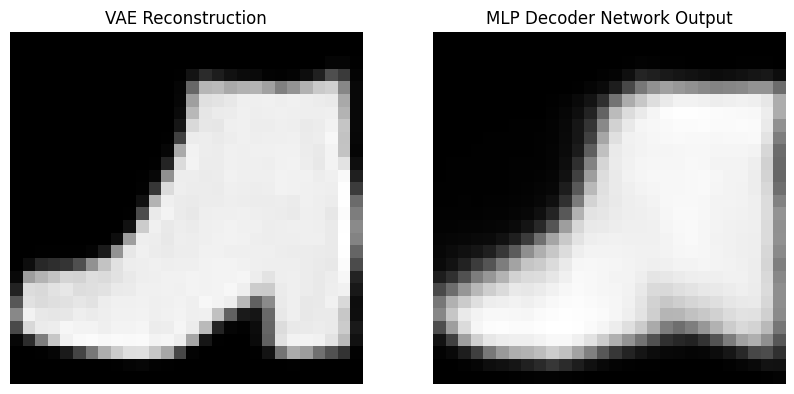

Epoch [16/20], Step [200/600], Loss: 1504.8704


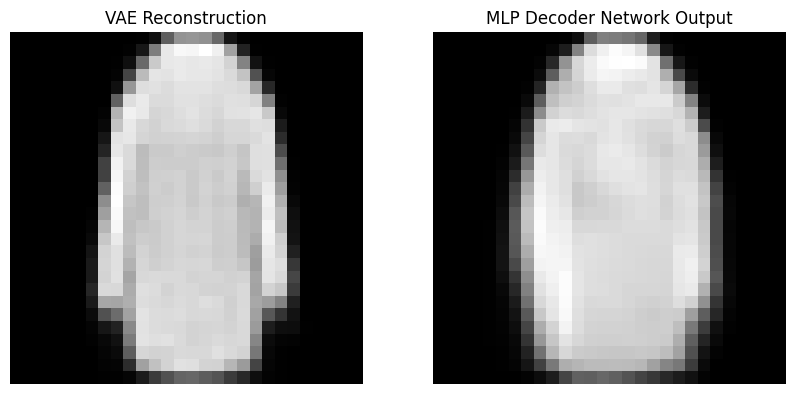

Epoch [16/20], Step [300/600], Loss: 1522.6846


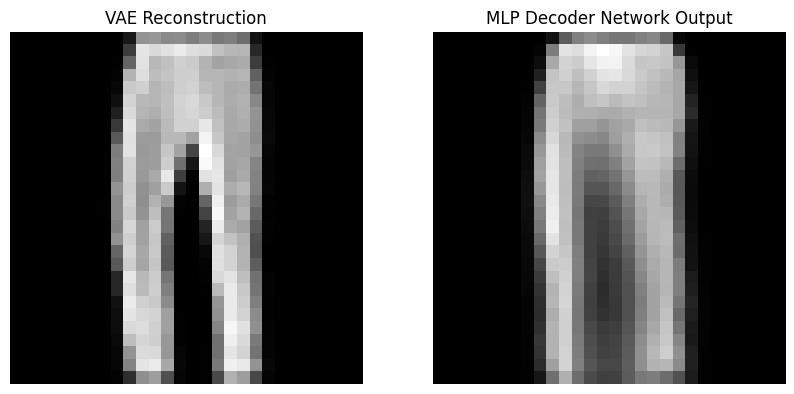

Epoch [16/20], Step [400/600], Loss: 1478.5736


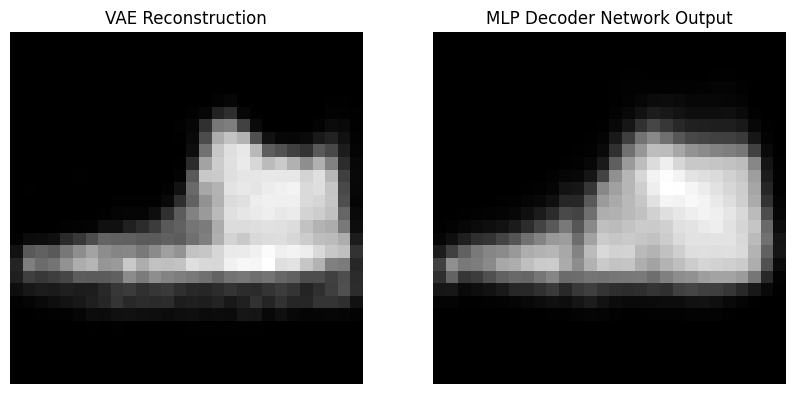

Epoch [16/20], Step [500/600], Loss: 1491.8499


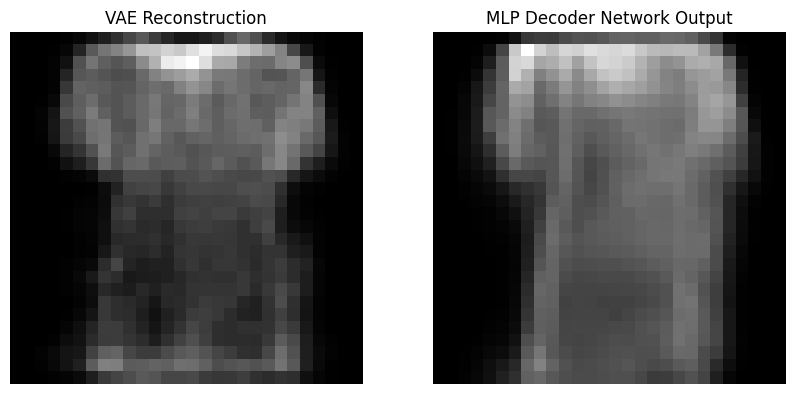

Epoch [16/20], Step [600/600], Loss: 1482.7839


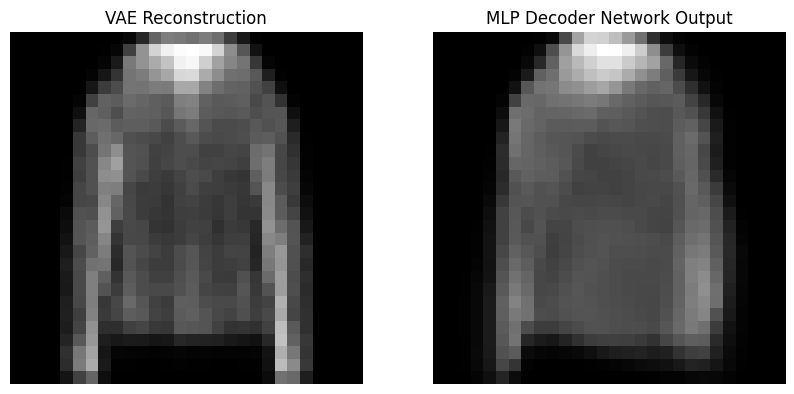

Epoch [17/20], Step [100/600], Loss: 1493.0887


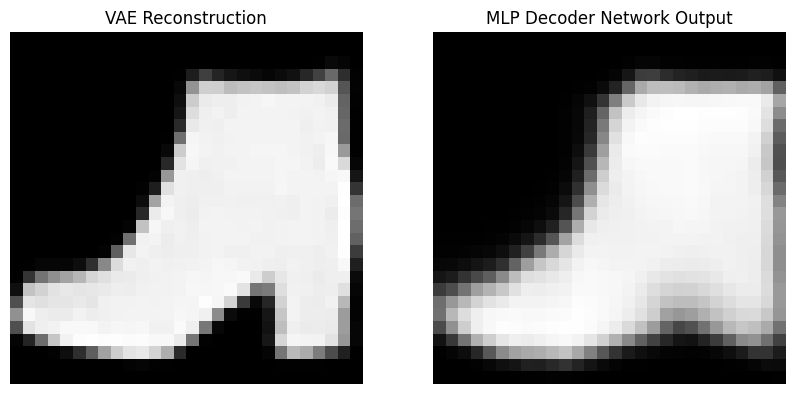

Epoch [17/20], Step [200/600], Loss: 1504.8704


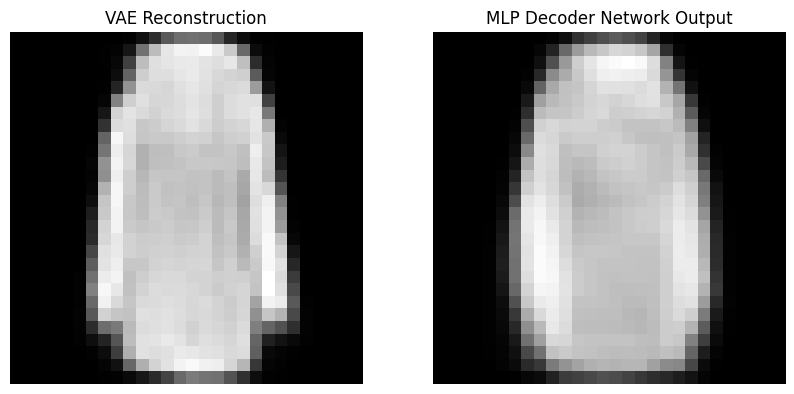

Epoch [17/20], Step [300/600], Loss: 1522.6847


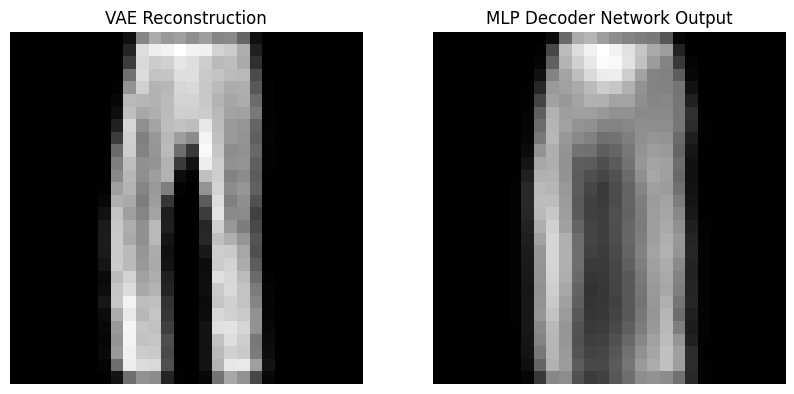

Epoch [17/20], Step [400/600], Loss: 1478.5736


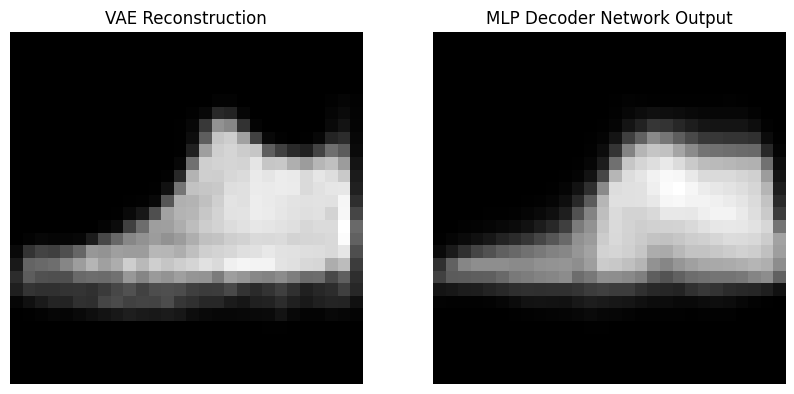

Epoch [17/20], Step [500/600], Loss: 1491.8499


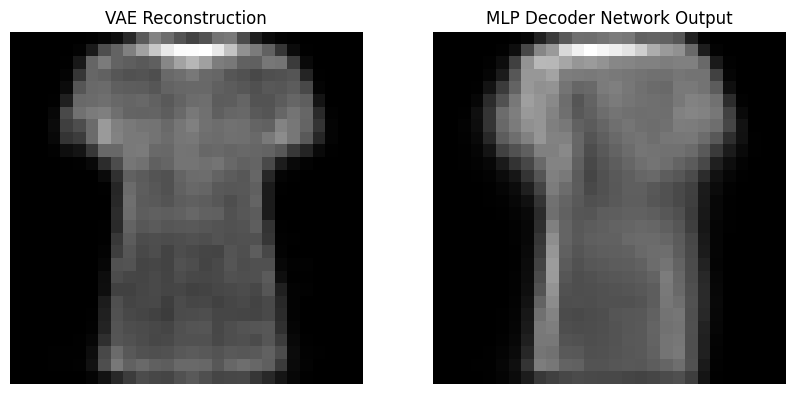

Epoch [17/20], Step [600/600], Loss: 1482.7837


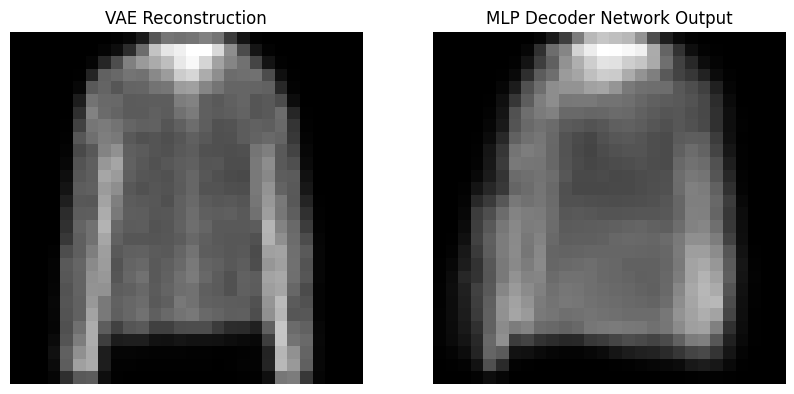

Epoch [18/20], Step [100/600], Loss: 1493.0889


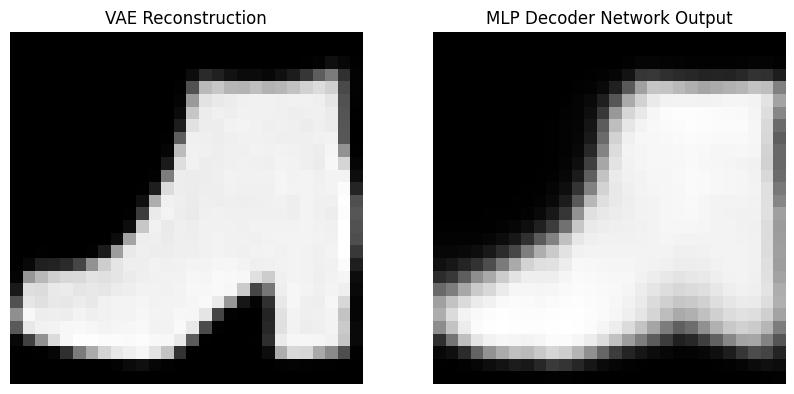

Epoch [18/20], Step [200/600], Loss: 1504.8704


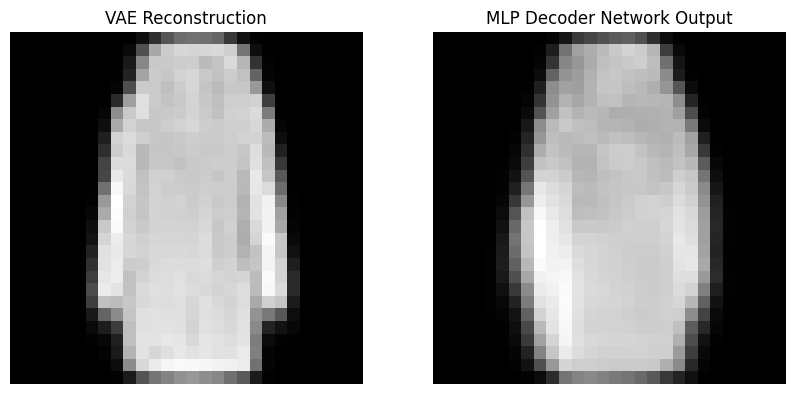

Epoch [18/20], Step [300/600], Loss: 1522.6841


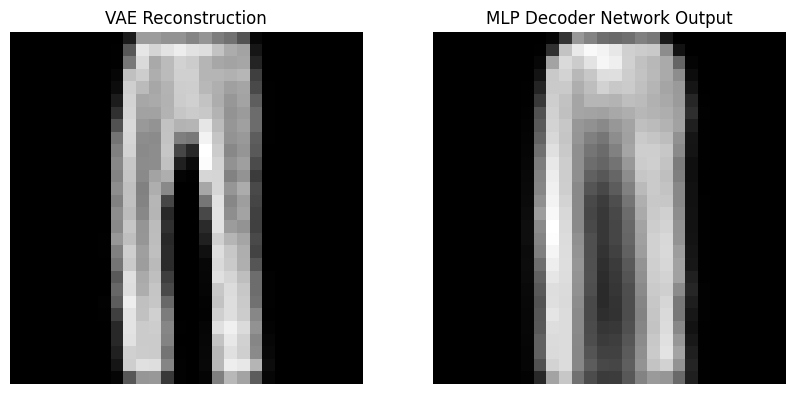

Epoch [18/20], Step [400/600], Loss: 1478.5732


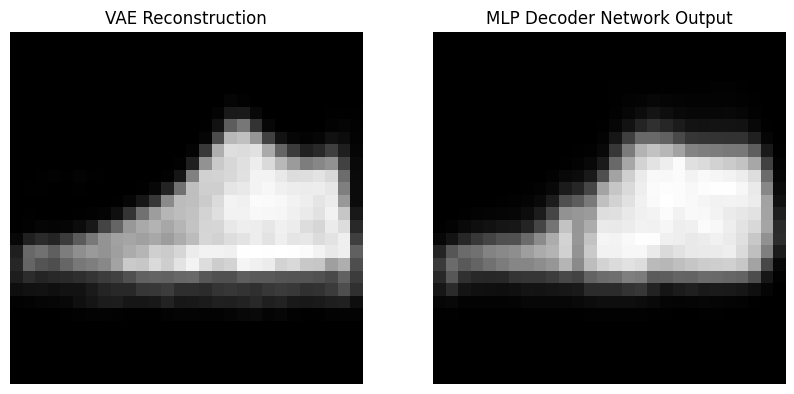

Epoch [18/20], Step [500/600], Loss: 1491.8499


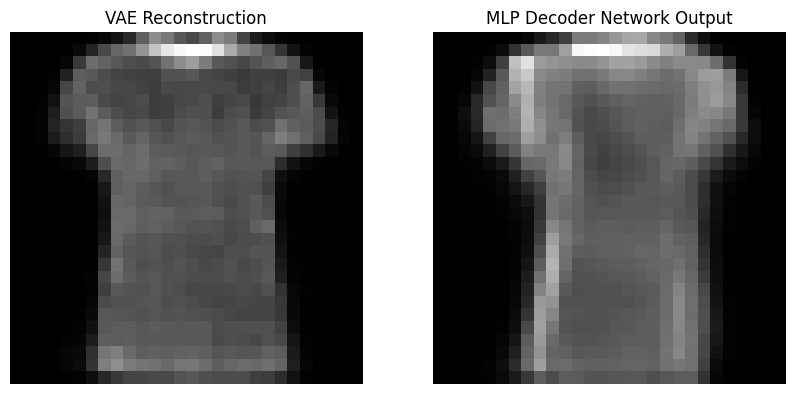

Epoch [18/20], Step [600/600], Loss: 1482.7836


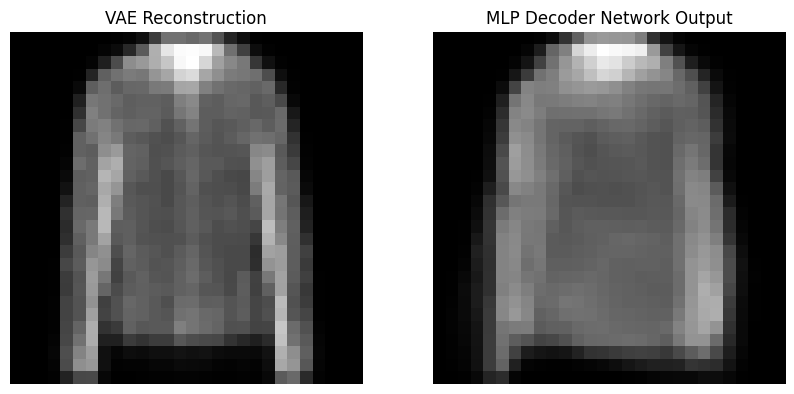

Epoch [19/20], Step [100/600], Loss: 1493.0885


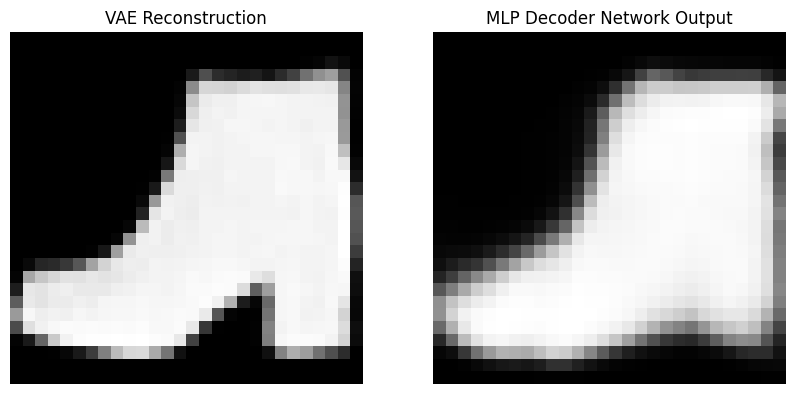

Epoch [19/20], Step [200/600], Loss: 1504.8704


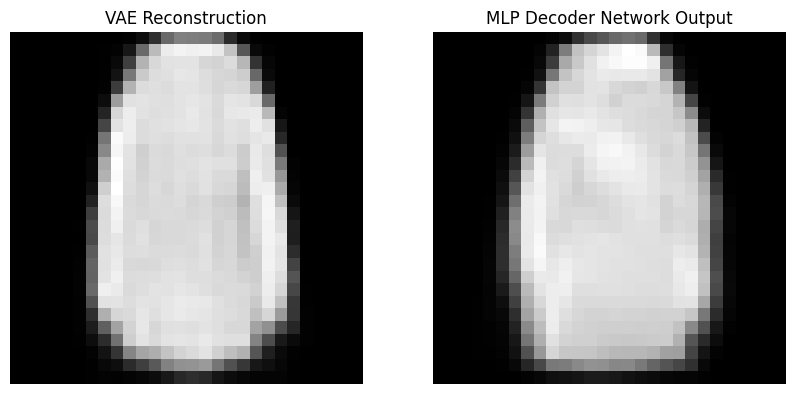

Epoch [19/20], Step [300/600], Loss: 1522.6840


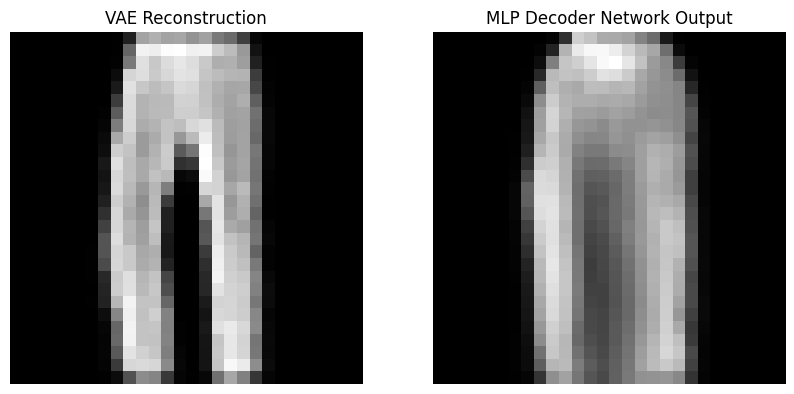

Epoch [19/20], Step [400/600], Loss: 1478.5731


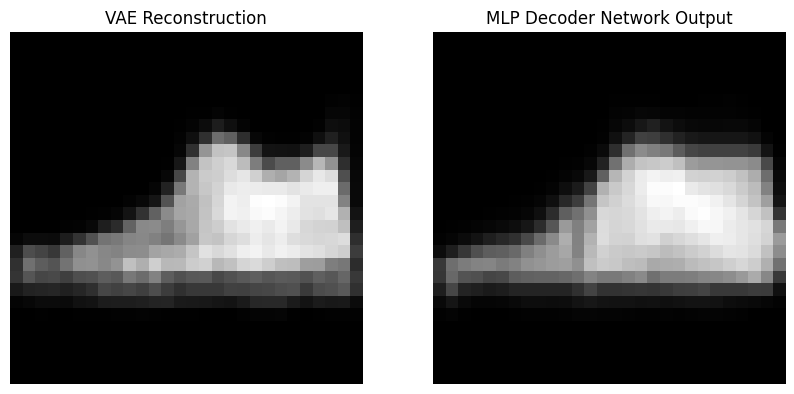

Epoch [19/20], Step [500/600], Loss: 1491.8495


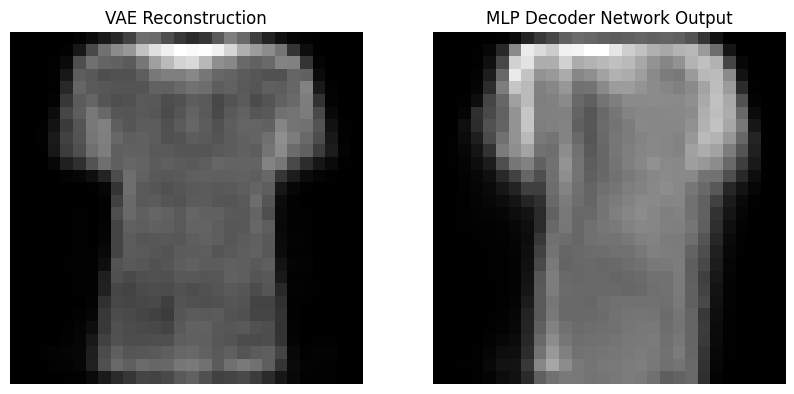

Epoch [19/20], Step [600/600], Loss: 1482.7832


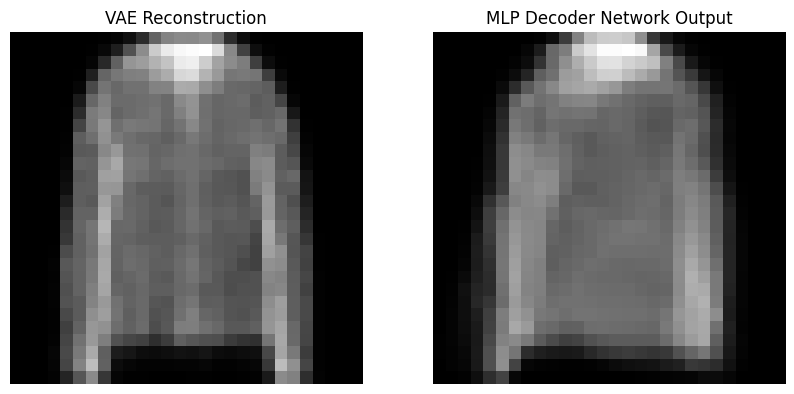

Epoch [20/20], Step [100/600], Loss: 1493.0884


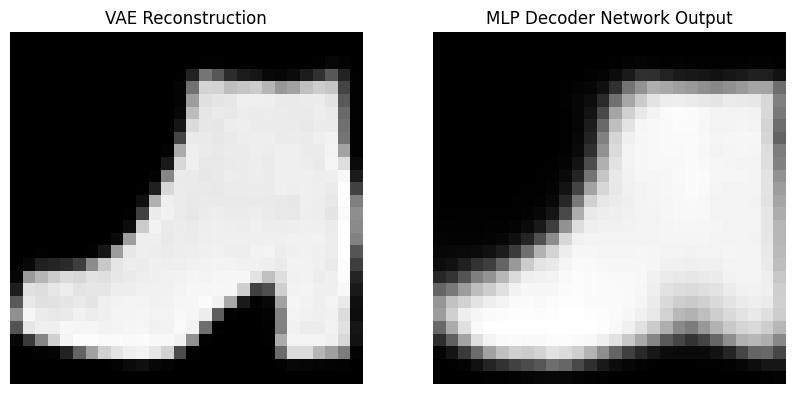

Epoch [20/20], Step [200/600], Loss: 1504.8702


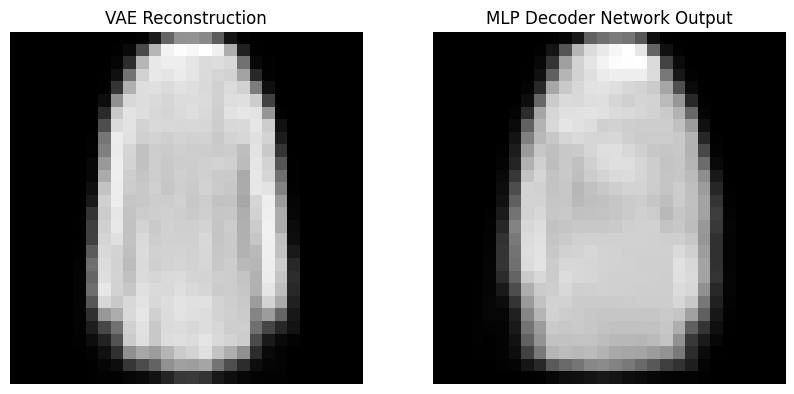

Epoch [20/20], Step [300/600], Loss: 1522.6838


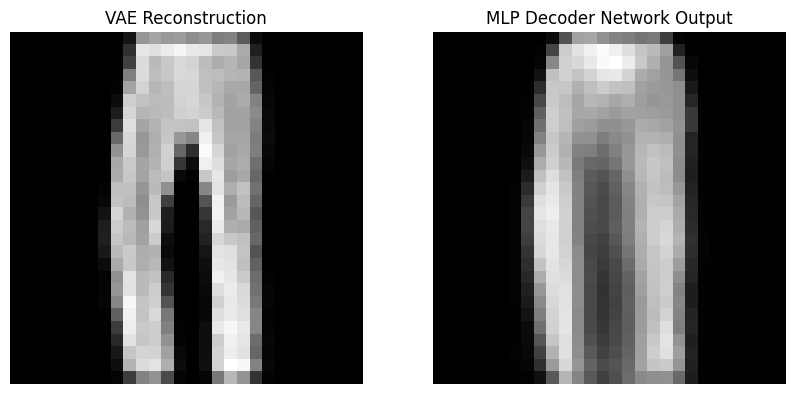

Epoch [20/20], Step [400/600], Loss: 1478.5728


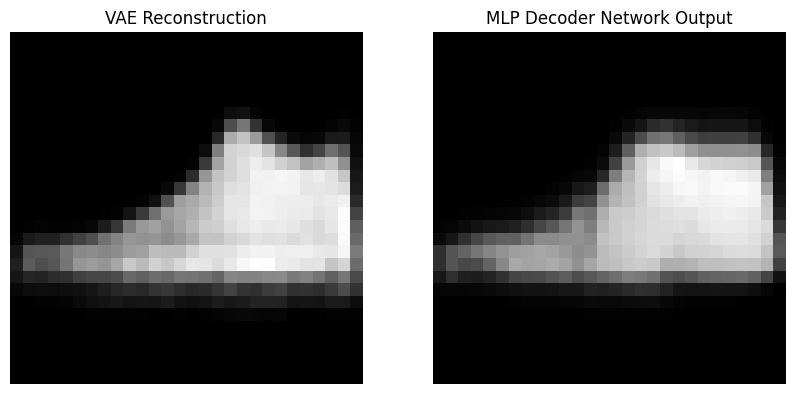

Epoch [20/20], Step [500/600], Loss: 1491.8497


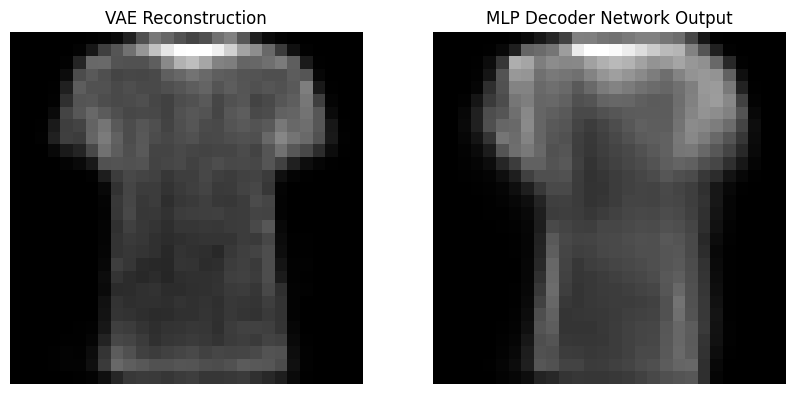

Epoch [20/20], Step [600/600], Loss: 1482.7832


In [31]:
# VAE is already trained
# Freeze VAE model during training of the decoder network
for param in model.vae.parameters():
    param.requires_grad = False

# Initialize the optimizer only for the decoder
optimizer = torch.optim.Adam(model.decoder.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(train_loader):
        images = images.to(device)

        z, mu, logvar = model.vae.encode(images)  # Get latent representation z from VAE

        coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)
        coords = coords.unsqueeze(0).repeat(images.size(0), 1, 1)  # Repeat for each image in batch
        z_expanded = z.unsqueeze(1).repeat(1, 784, 1)

        decoder_image = model.decoder(z_expanded, coords)  # Generate image

        vae_reconstruction = model.vae.decode(z)

        # Calculate reconstruction loss between decoder image and VAE reconstruction
        reconst_loss = F.mse_loss(decoder_image.view(-1), vae_reconstruction.view(-1))  # Compare generated vs VAE image
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconst_loss + kl_loss

        # Backpropagation for decorder
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            # Visualize the VAE reconstruction and decoder network output
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            # VAE reconstruction
            axes[0].imshow(vae_reconstruction[0].cpu().detach().numpy().squeeze(), cmap='gray')
            axes[0].set_title("VAE Reconstruction")
            axes[0].axis('off')

            # Decoder network output
            axes[1].imshow(decoder_image[0].cpu().detach().numpy().reshape(28, 28), cmap='gray')
            axes[1].set_title("MLP Decoder Network Output")
            axes[1].axis('off')

            plt.show()

            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

#### Visualize the MLP Decoder output

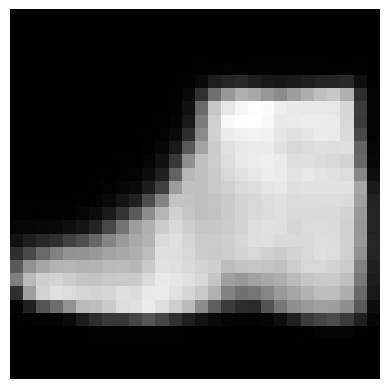

In [32]:
model.eval()
z_dim = 64
with torch.no_grad():
    random_idx = random.randint(0, len(test_loader) - 1)  # Random index
    imgs, _ = list(test_loader)[random_idx]  # Grab the image batch at the random index
    imgs = imgs.to(device)

    # Get the latent vector of real image
    z, _, _ = model.vae.encode(imgs)

    z_single = z[0].unsqueeze(0)

    coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)
    coords_expanded = coords.unsqueeze(0)

    # Repeat the latent vector for each pixel
    z_expanded = z_single.unsqueeze(1).repeat(1, 784, 1)

    # Pass the latent vector and coordinates to decoder
    decoder_image = model.decoder(z_expanded, coords_expanded)

    # Reshape the decoder network output to form the 28x28 image
    generated_image = decoder_image.view(28, 28).cpu().numpy()

    # Display generated image
    plt.imshow(generated_image, cmap='gray')
    plt.axis('off')
    plt.show()

#### Training the SIREN Decoder

In [33]:
class Sinusoid(nn.Module):
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30): #"We found ω0 = 30 to work well for all the applications in this work" - PDF page 5
        super().__init__()
        self.omega_0 = omega_0 #Hyperparameter according to paper
        self.is_first = is_first
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, np.sqrt(6 / self.in_features) / self.omega_0)

    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False,
                 first_omega_0=30, hidden_omega_0=30):
        super().__init__()
        self.net = []
        self.net.append(Sinusoid(in_features + 2, hidden_features, is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(Sinusoid(hidden_features, hidden_features, is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, np.sqrt(6 / hidden_features) / hidden_omega_0)
            self.net.append(final_linear)
        else:
            self.net.append(Sinusoid(hidden_features, out_features, is_first=False, omega_0=hidden_omega_0))

        self.net = nn.Sequential(*self.net)

    def forward(self, z, coords): #Modified to accept latent vector as input for decoding
        # Concatenate z and coords along the feature dimension (z_dim + 2)
        input_tensor = torch.cat([z, coords], dim=-1)  # Concatenate along the last dimension (z_dim + 2)
        coords.requires_grad_(True)
        output = self.net(input_tensor)
        return output, coords

In [74]:
Sirenmodel = Siren(in_features=64, hidden_features=100, hidden_layers=2, out_features=1).to(device)
def init_siren_weights(model, omega_0=30):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            with torch.no_grad():
                layer.weight.uniform_(-np.sqrt(6 / layer.in_features) / omega_0, np.sqrt(6 / layer.in_features) / omega_0)
                layer.bias.zero_()

init_siren_weights(Sirenmodel, omega_0=30)
batch_size = 128
learning_rate = 5e-4
num_epochs = 20

# z_dim is 64 as in VAE definition
z_dim = 64

# original VAE model and the SIREN Decoder Network
vae = VAEmodel  #original VAE model
SirenDecoder = Sirenmodel  # Define the SIREN Decoder Network

# wrap both in VAEWithDecoder
SirenVaeModel = VAEWithDecoder(vae, SirenDecoder).to(device)

In [75]:
model = SirenVaeModel

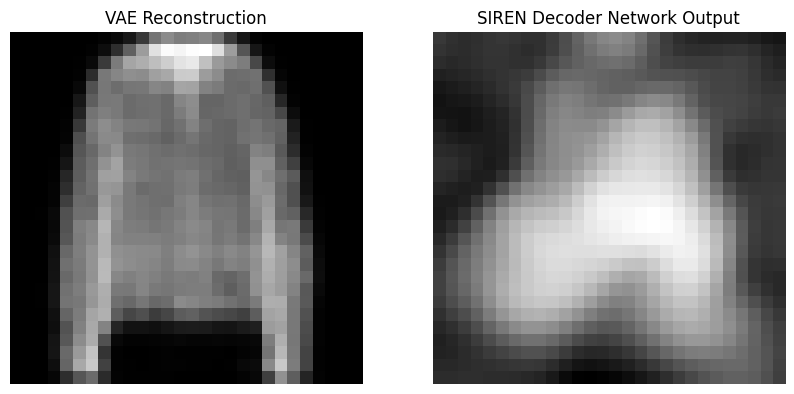

Epoch [1/20], Step [100/600], Loss: 1493.1147


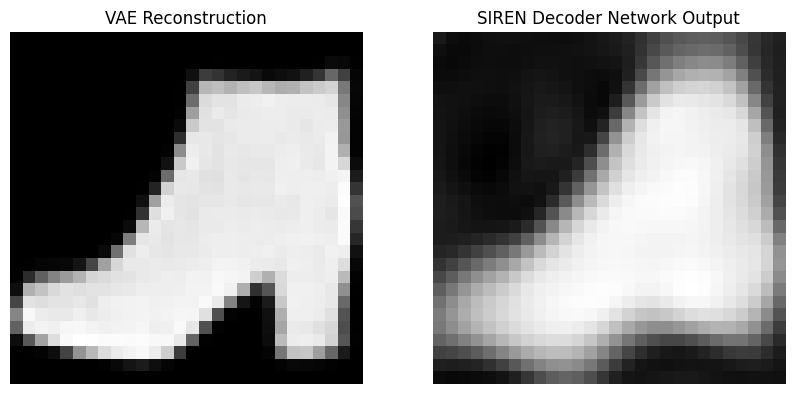

Epoch [1/20], Step [200/600], Loss: 1504.8843


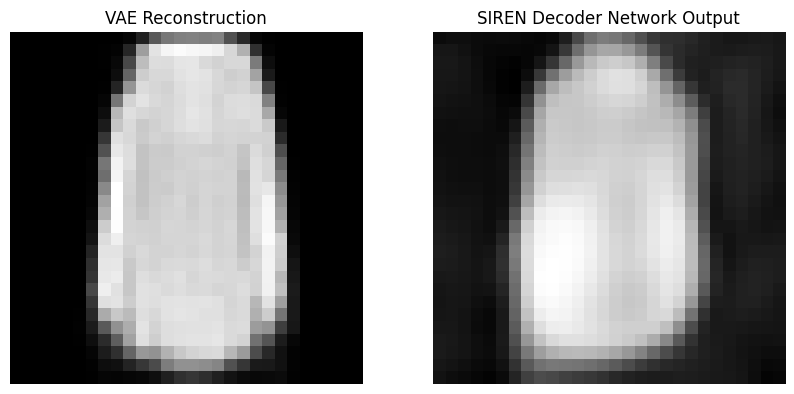

Epoch [1/20], Step [300/600], Loss: 1522.6917


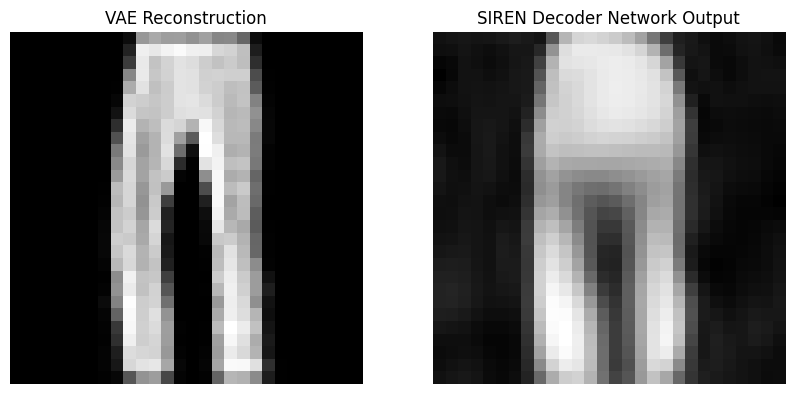

Epoch [1/20], Step [400/600], Loss: 1478.5767


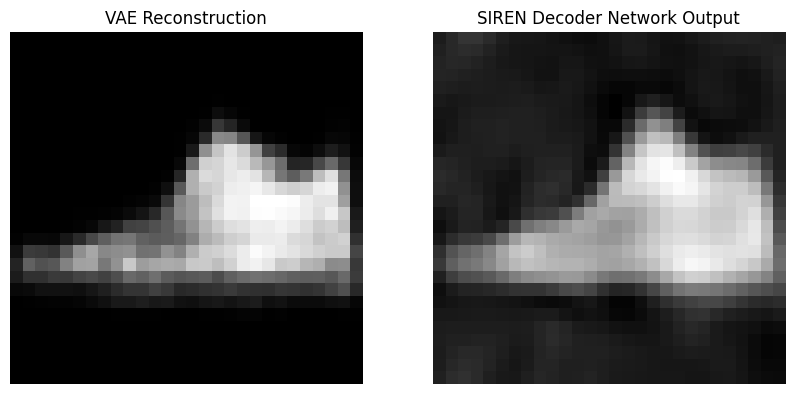

Epoch [1/20], Step [500/600], Loss: 1491.8510


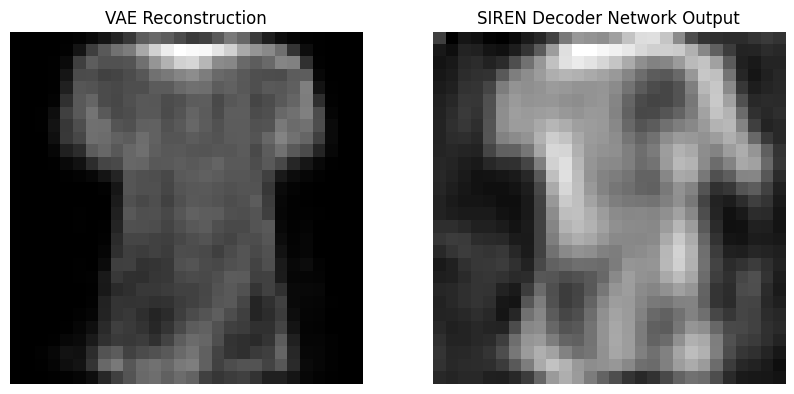

Epoch [1/20], Step [600/600], Loss: 1482.7841


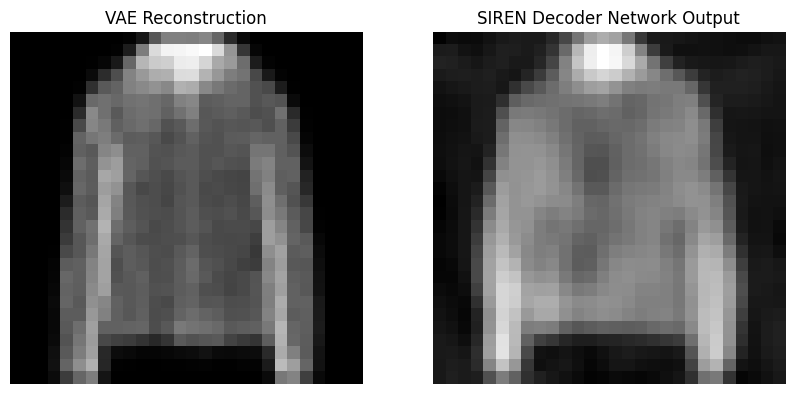

Epoch [2/20], Step [100/600], Loss: 1493.0876


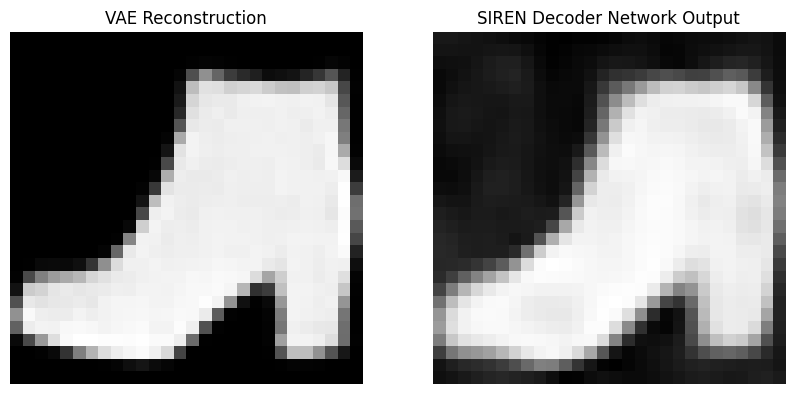

Epoch [2/20], Step [200/600], Loss: 1504.8694


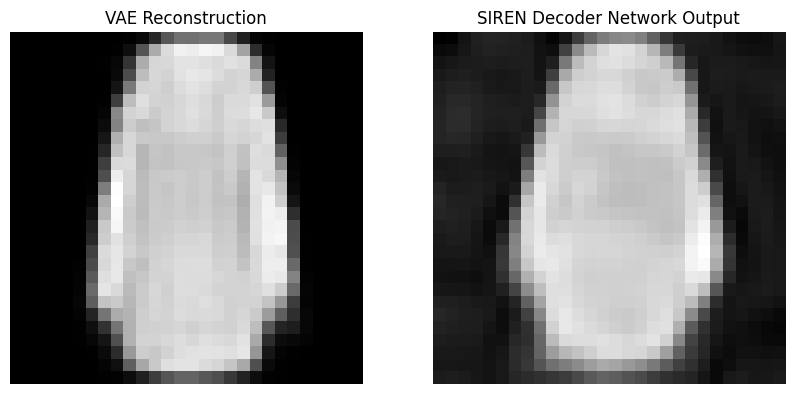

Epoch [2/20], Step [300/600], Loss: 1522.6825


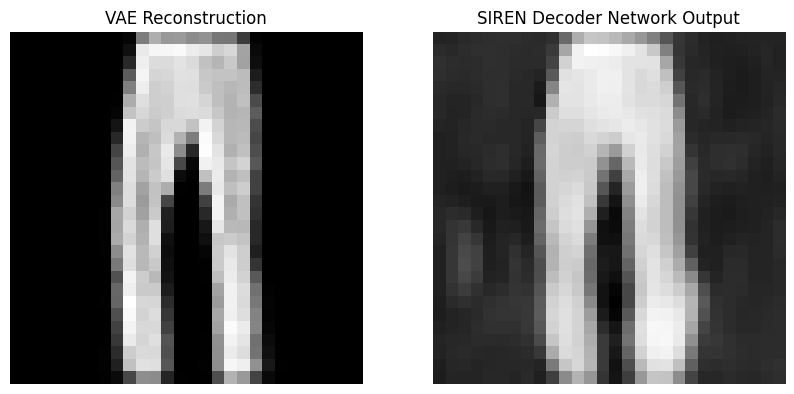

Epoch [2/20], Step [400/600], Loss: 1478.5721


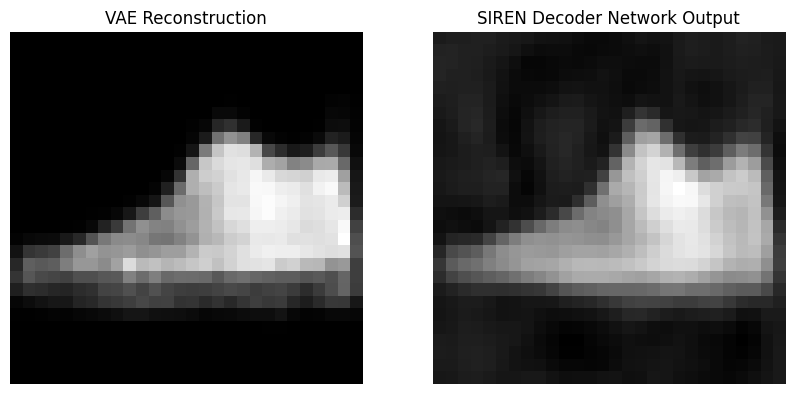

Epoch [2/20], Step [500/600], Loss: 1491.8479


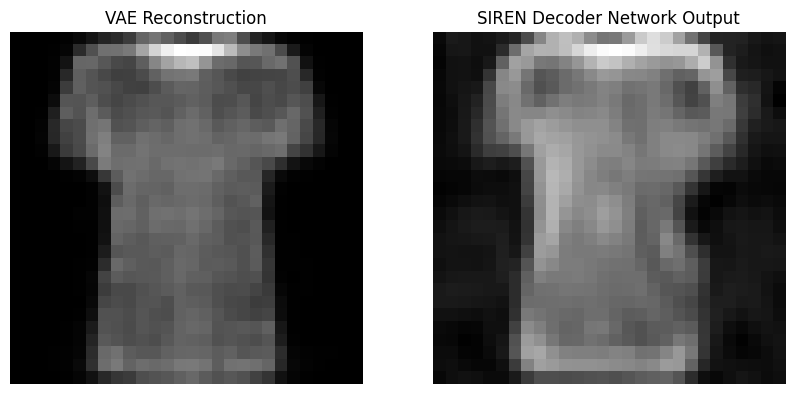

Epoch [2/20], Step [600/600], Loss: 1482.7819


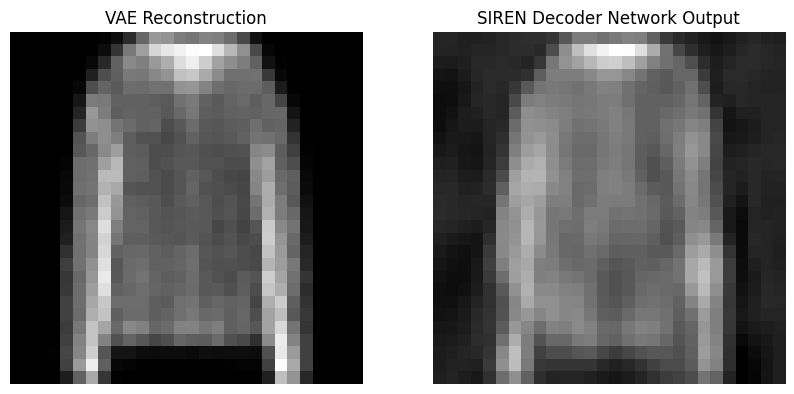

Epoch [3/20], Step [100/600], Loss: 1493.0863


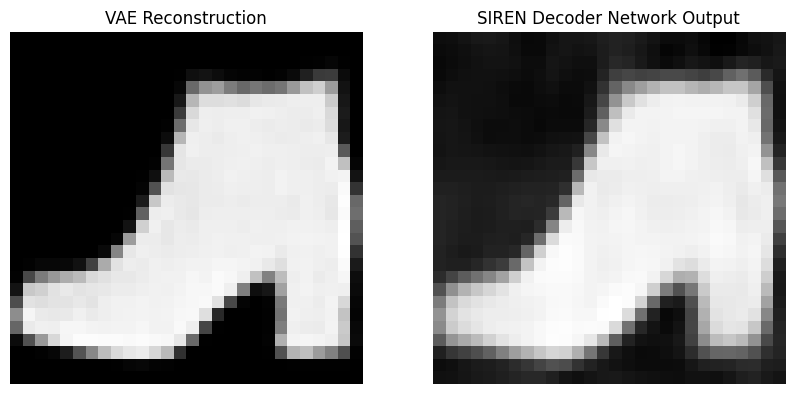

Epoch [3/20], Step [200/600], Loss: 1504.8680


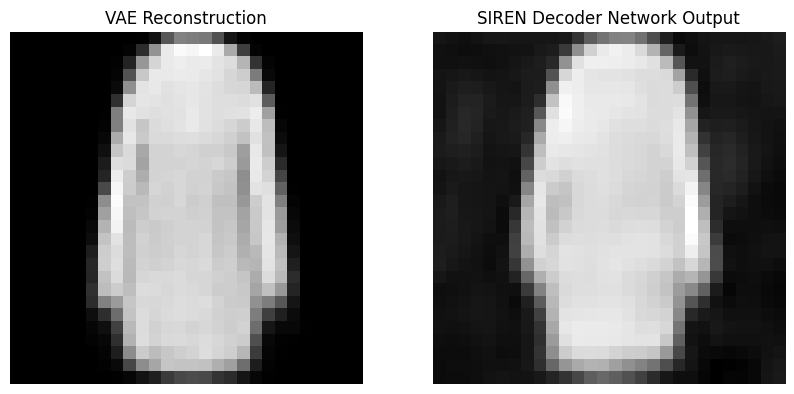

Epoch [3/20], Step [300/600], Loss: 1522.6807


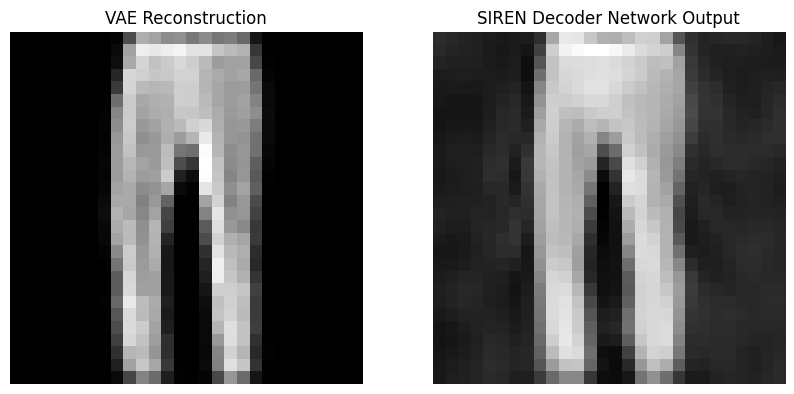

Epoch [3/20], Step [400/600], Loss: 1478.5720


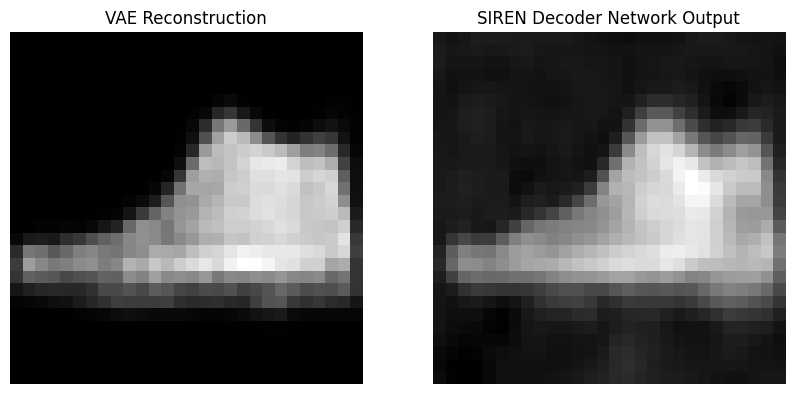

Epoch [3/20], Step [500/600], Loss: 1491.8475


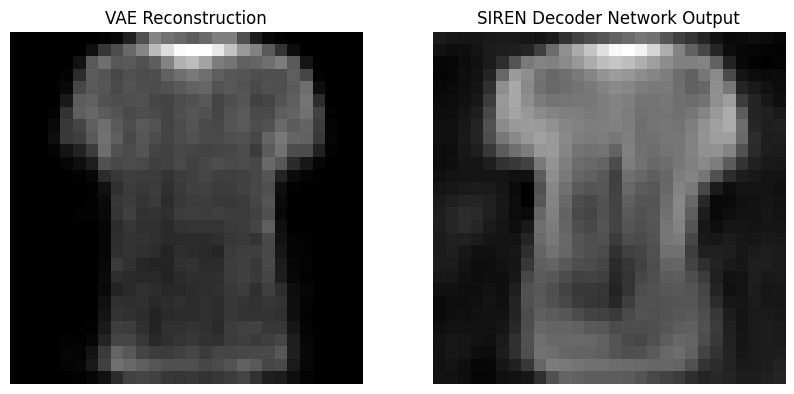

Epoch [3/20], Step [600/600], Loss: 1482.7811


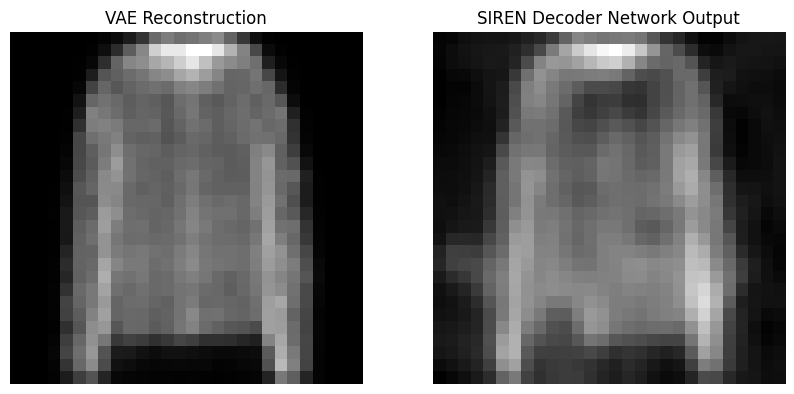

Epoch [4/20], Step [100/600], Loss: 1493.0861


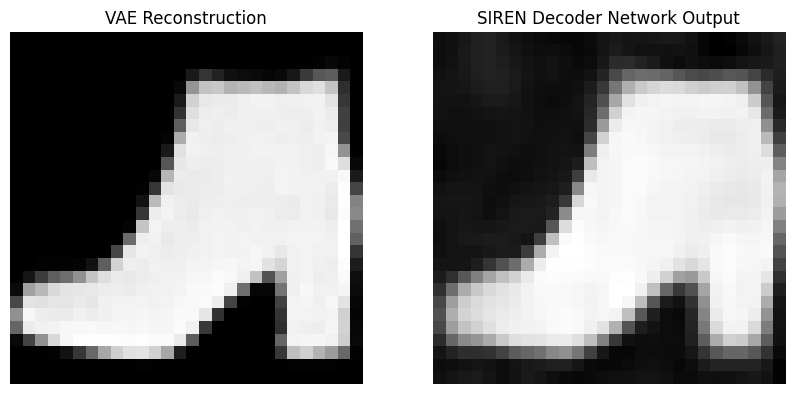

Epoch [4/20], Step [200/600], Loss: 1504.8678


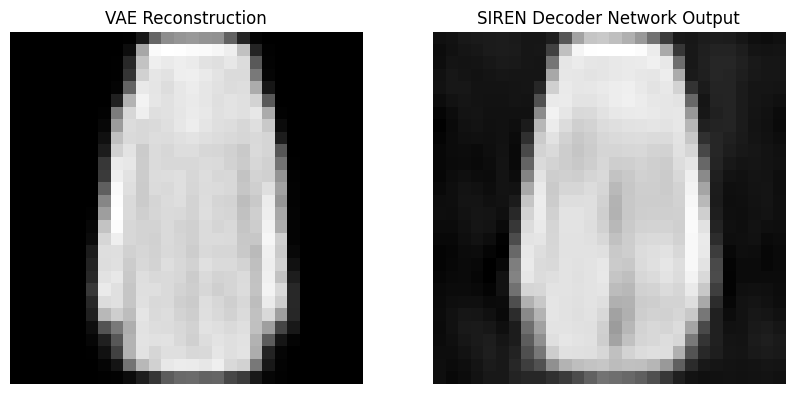

Epoch [4/20], Step [300/600], Loss: 1522.6815


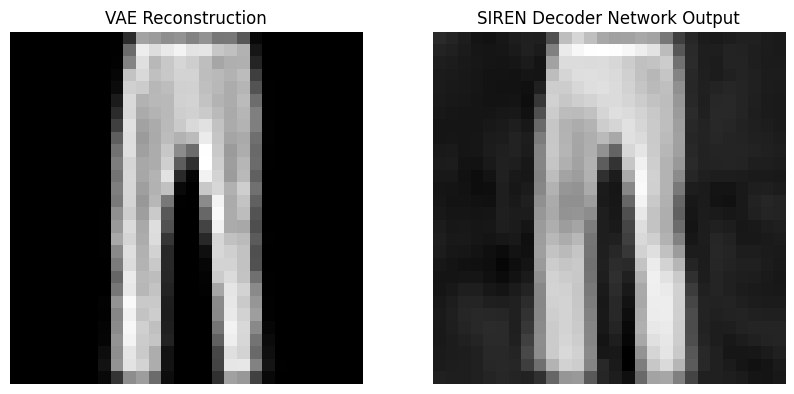

Epoch [4/20], Step [400/600], Loss: 1478.5704


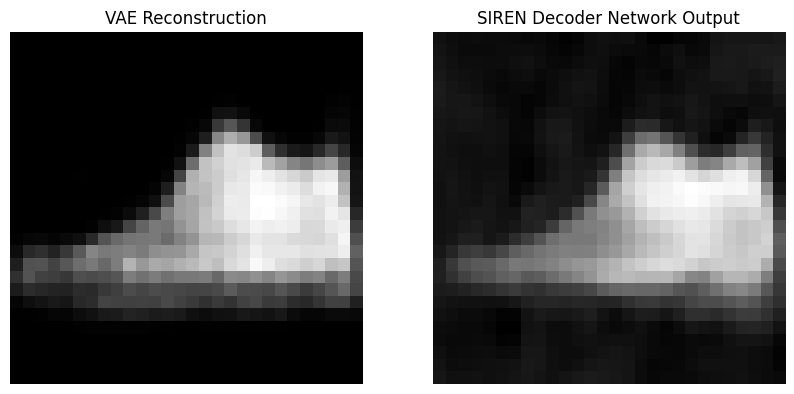

Epoch [4/20], Step [500/600], Loss: 1491.8469


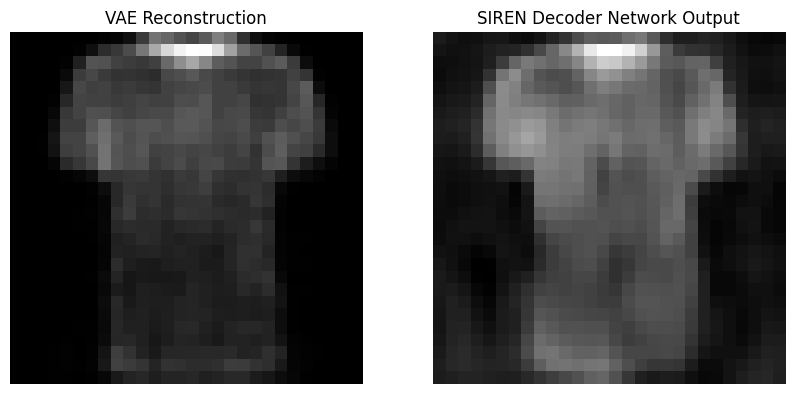

Epoch [4/20], Step [600/600], Loss: 1482.7827


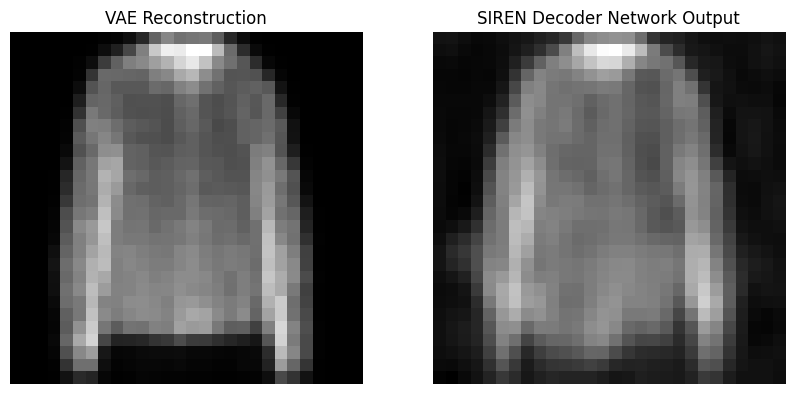

Epoch [5/20], Step [100/600], Loss: 1493.0857


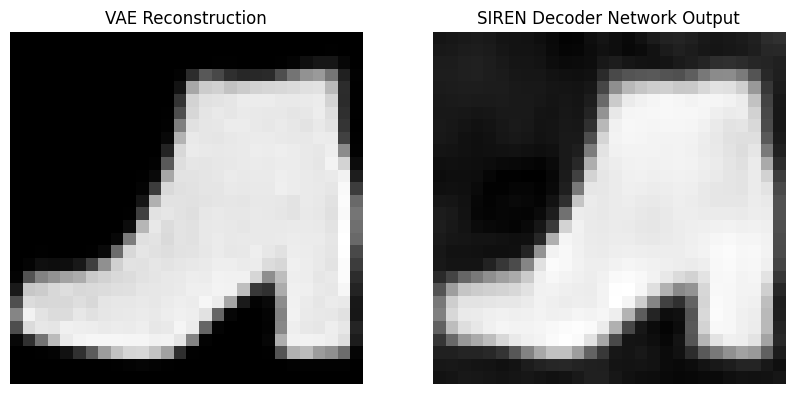

Epoch [5/20], Step [200/600], Loss: 1504.8682


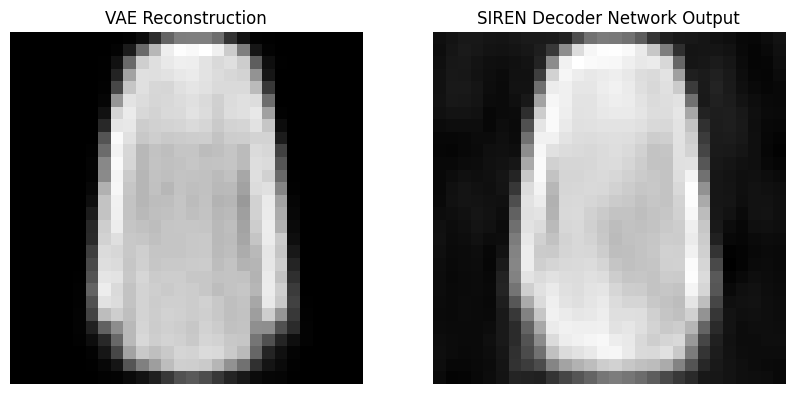

Epoch [5/20], Step [300/600], Loss: 1522.6799


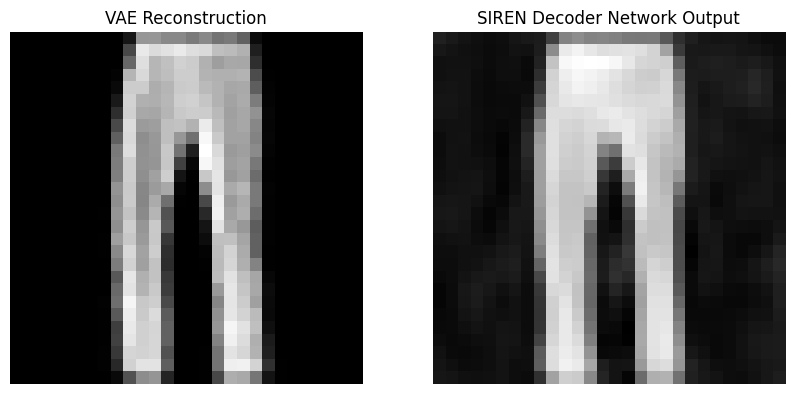

Epoch [5/20], Step [400/600], Loss: 1478.5715


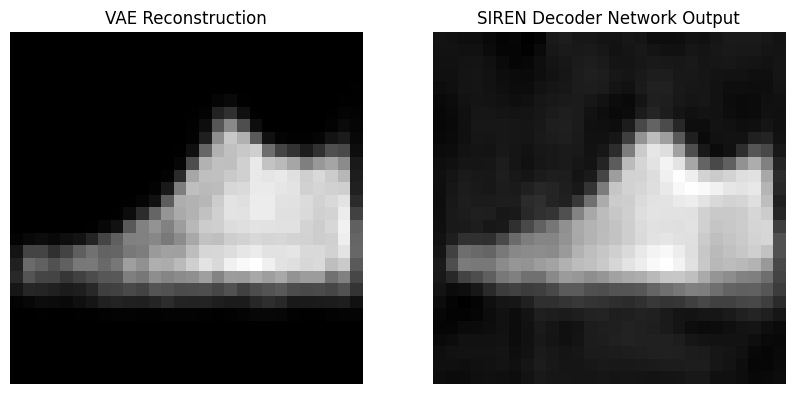

Epoch [5/20], Step [500/600], Loss: 1491.8468


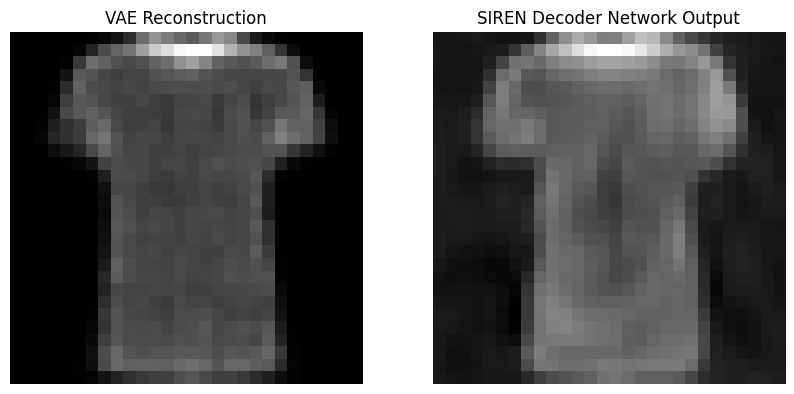

Epoch [5/20], Step [600/600], Loss: 1482.7808


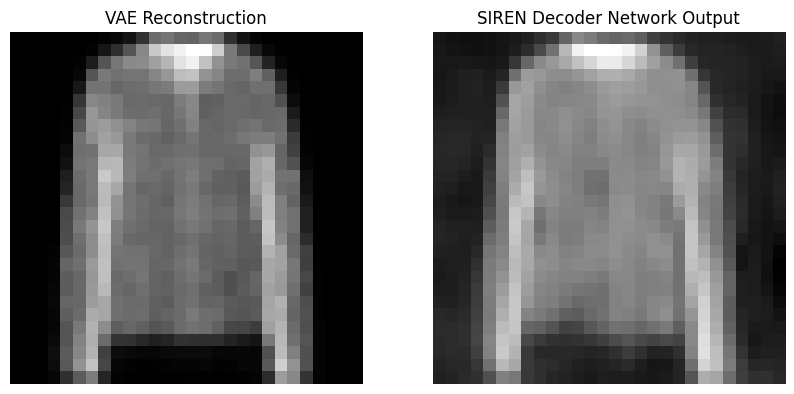

Epoch [6/20], Step [100/600], Loss: 1493.0856


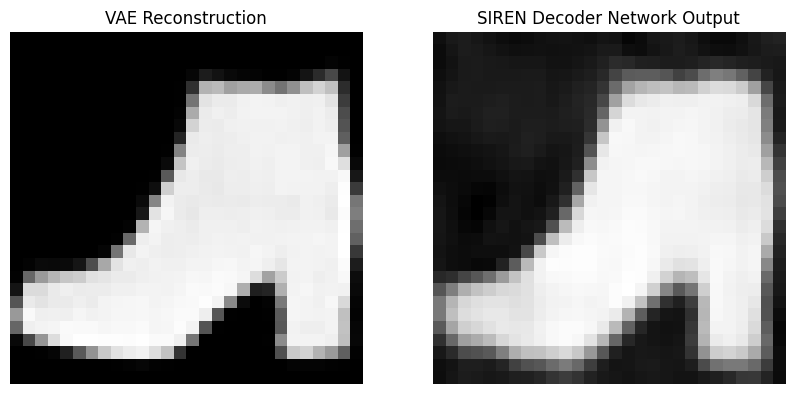

Epoch [6/20], Step [200/600], Loss: 1504.8679


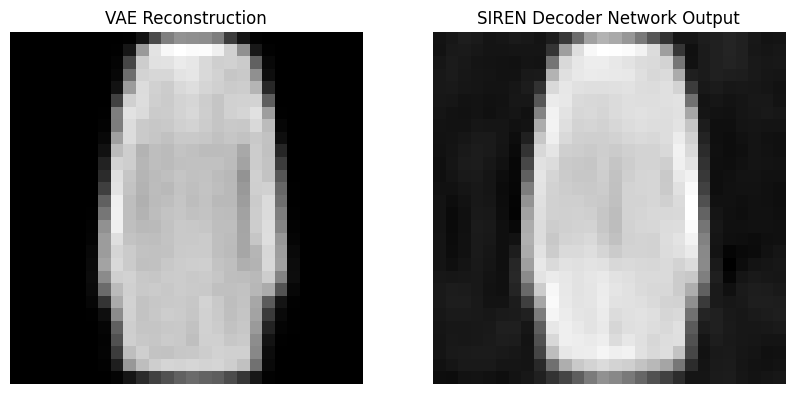

Epoch [6/20], Step [300/600], Loss: 1522.6805


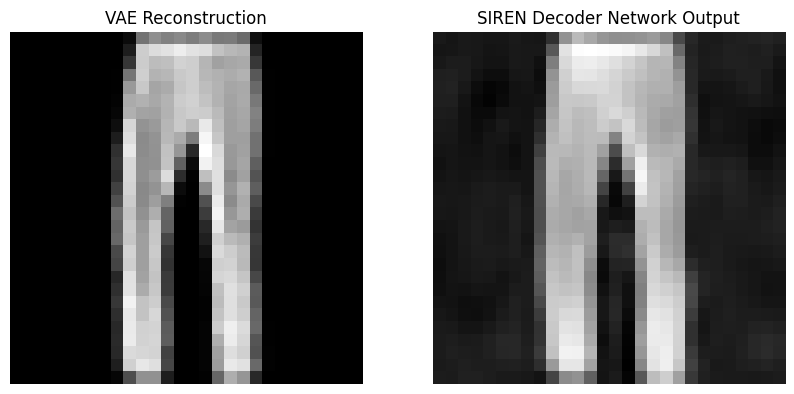

Epoch [6/20], Step [400/600], Loss: 1478.5706


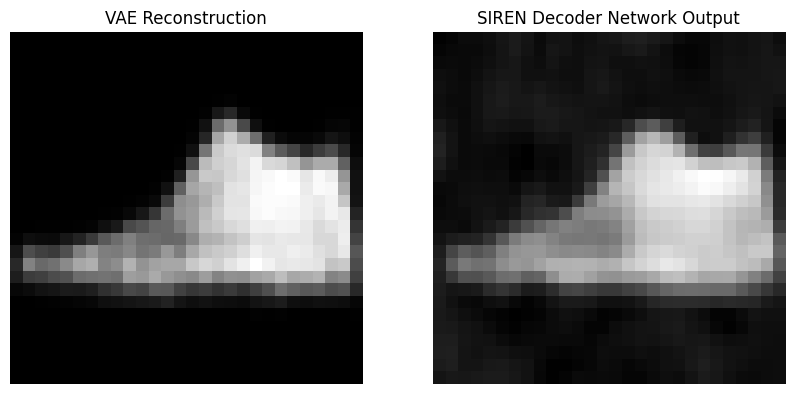

Epoch [6/20], Step [500/600], Loss: 1491.8470


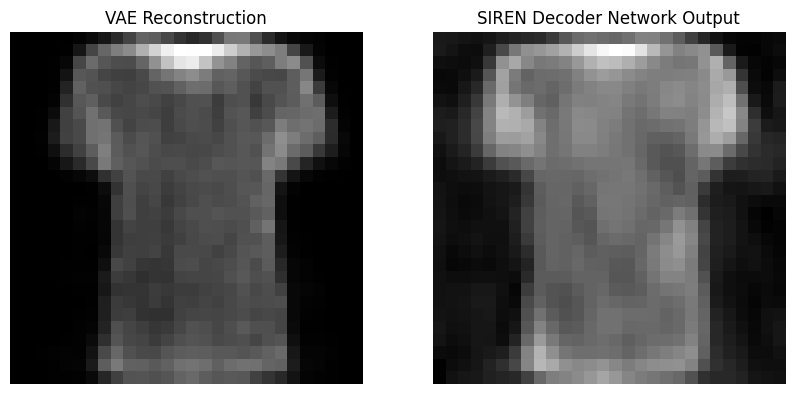

Epoch [6/20], Step [600/600], Loss: 1482.7805


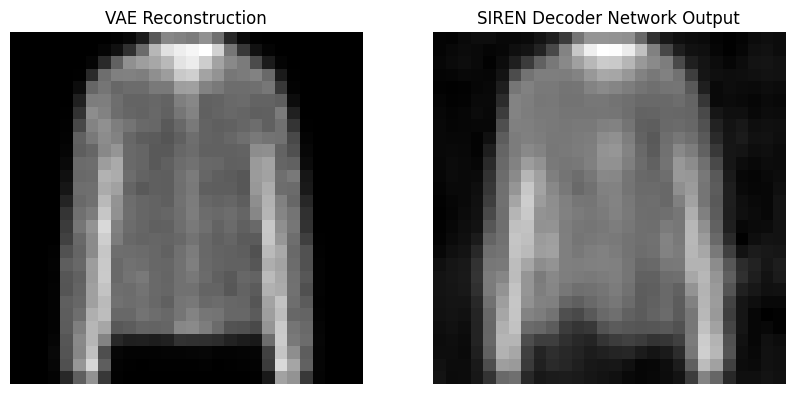

Epoch [7/20], Step [100/600], Loss: 1493.0859


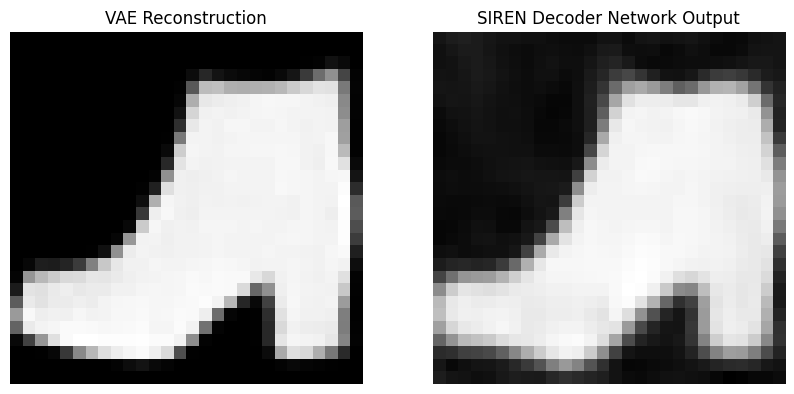

Epoch [7/20], Step [200/600], Loss: 1504.8680


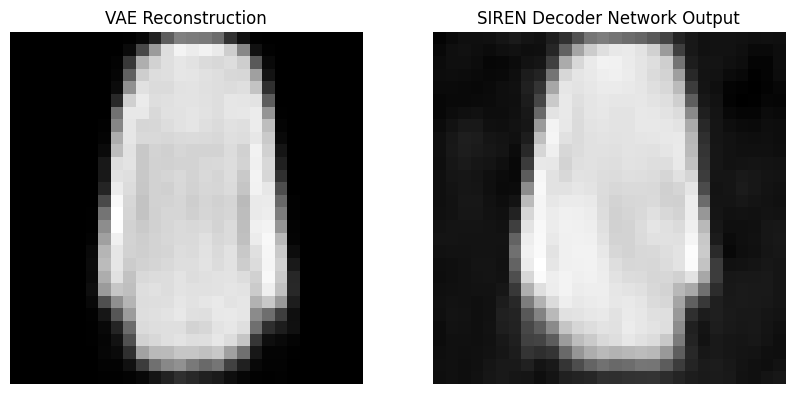

Epoch [7/20], Step [300/600], Loss: 1522.6807


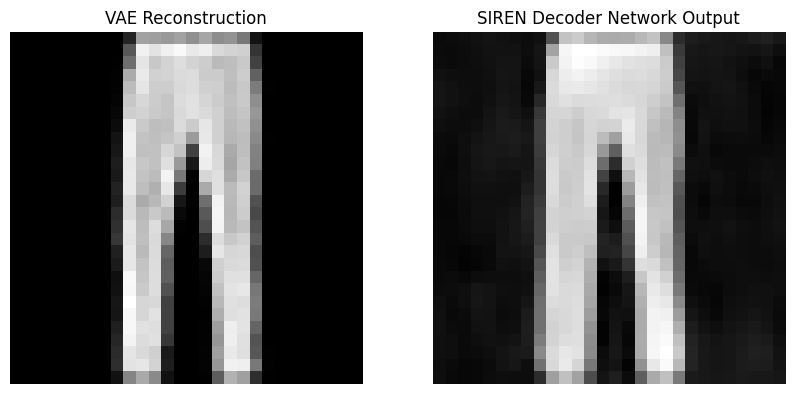

Epoch [7/20], Step [400/600], Loss: 1478.5707


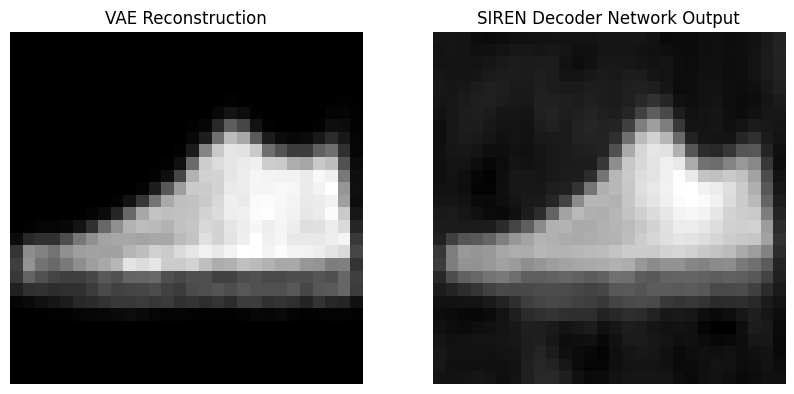

Epoch [7/20], Step [500/600], Loss: 1491.8481


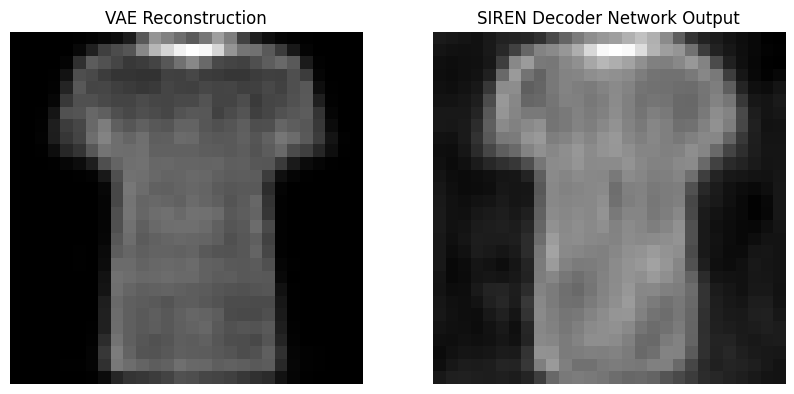

Epoch [7/20], Step [600/600], Loss: 1482.7809


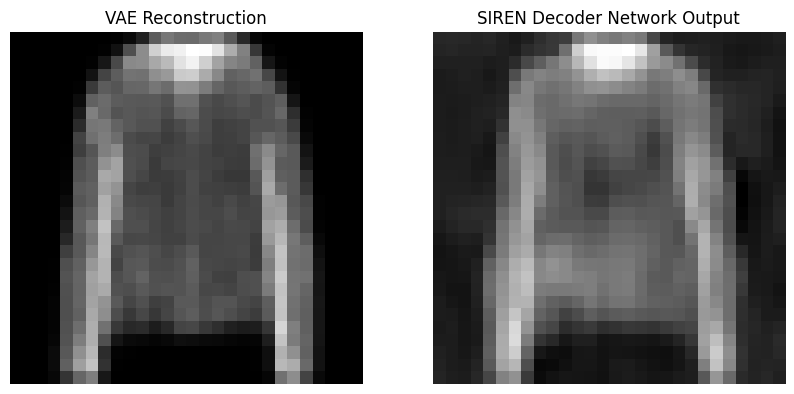

Epoch [8/20], Step [100/600], Loss: 1493.0850


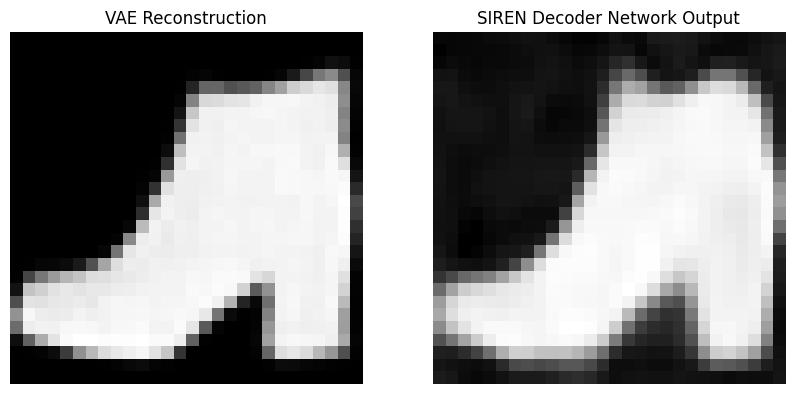

Epoch [8/20], Step [200/600], Loss: 1504.8677


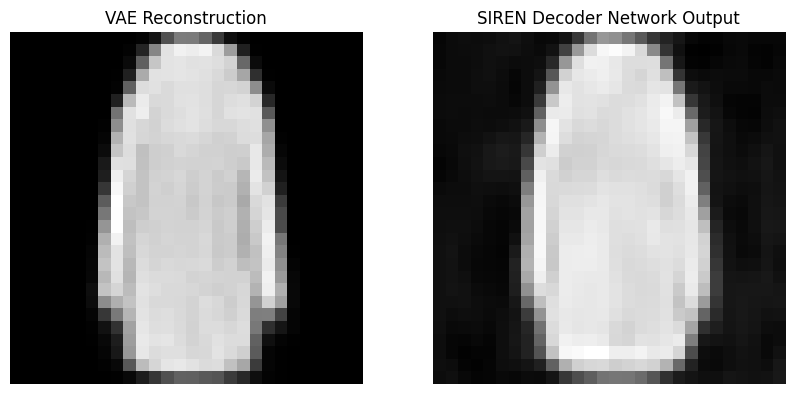

Epoch [8/20], Step [300/600], Loss: 1522.6823


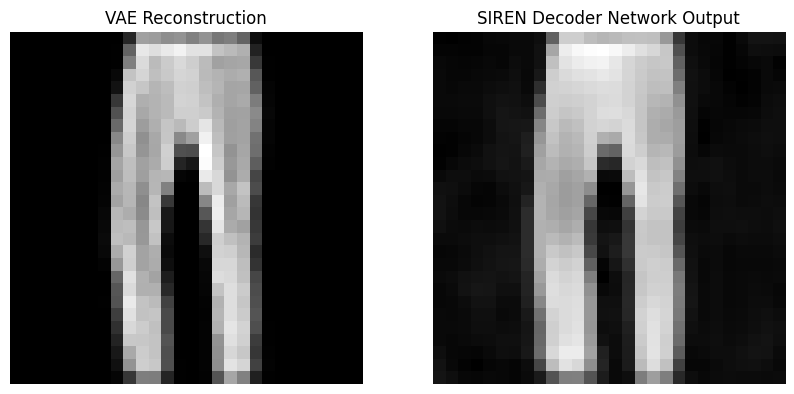

Epoch [8/20], Step [400/600], Loss: 1478.5704


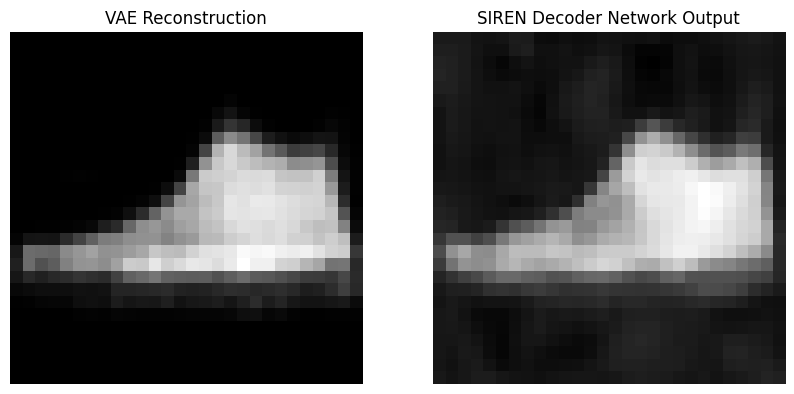

Epoch [8/20], Step [500/600], Loss: 1491.8475


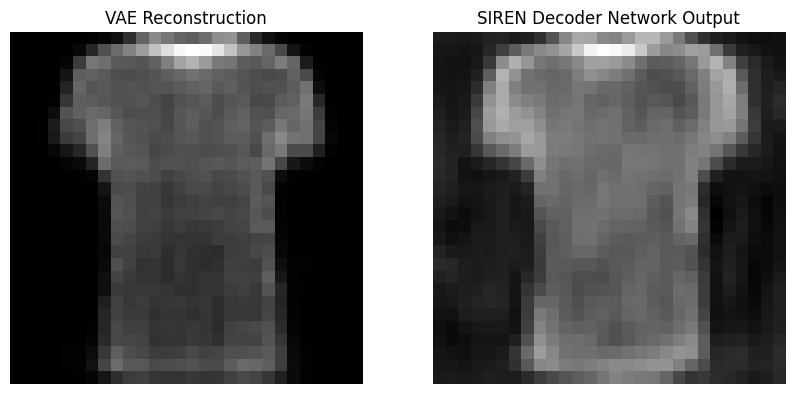

Epoch [8/20], Step [600/600], Loss: 1482.7811


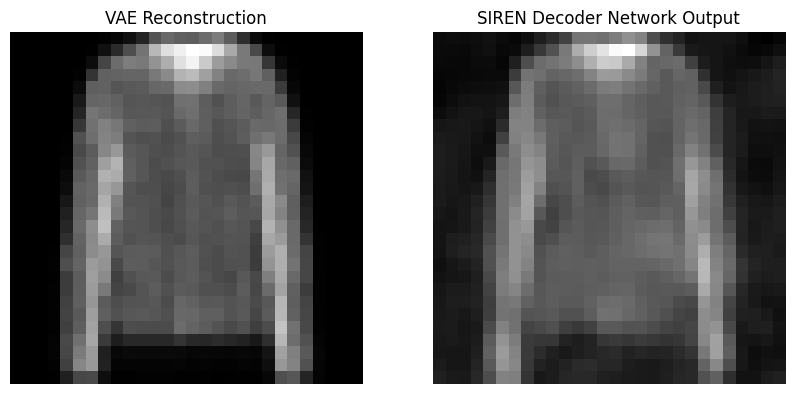

Epoch [9/20], Step [100/600], Loss: 1493.0852


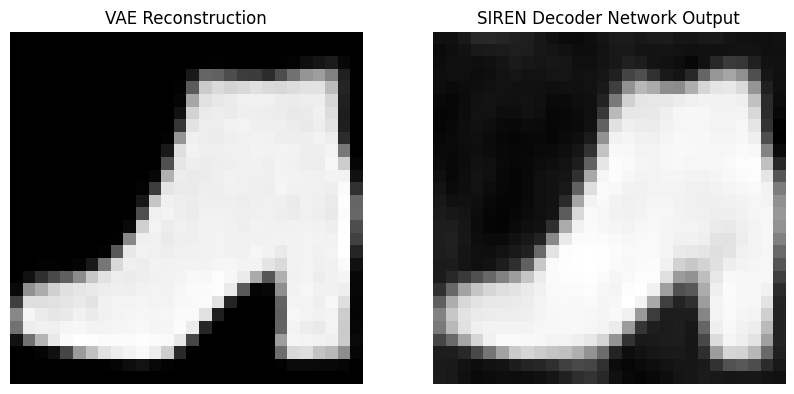

Epoch [9/20], Step [200/600], Loss: 1504.8676


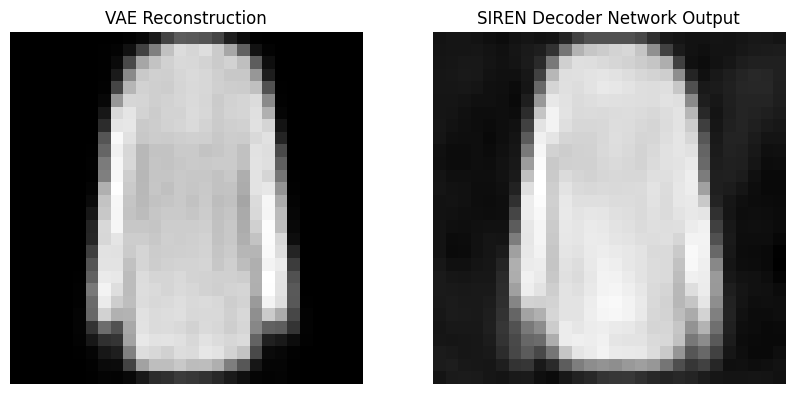

Epoch [9/20], Step [300/600], Loss: 1522.6803


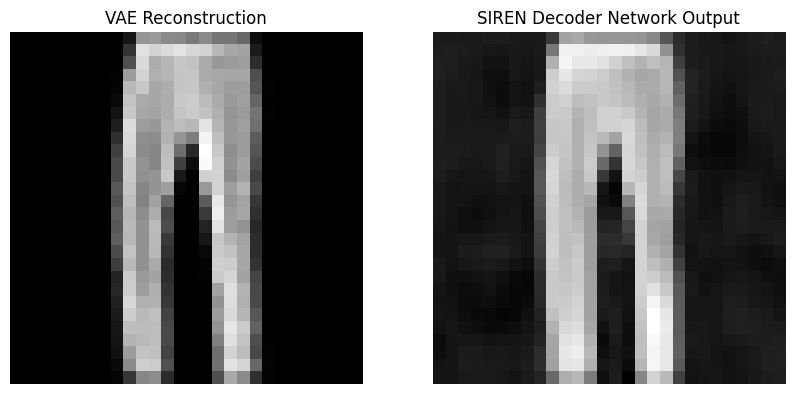

Epoch [9/20], Step [400/600], Loss: 1478.5703


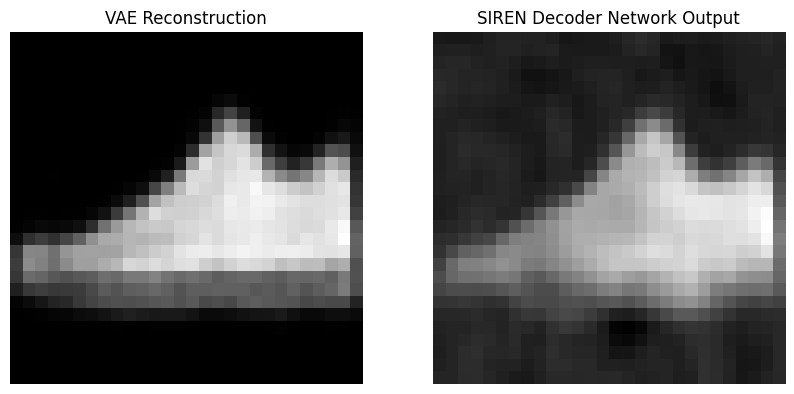

Epoch [9/20], Step [500/600], Loss: 1491.8475


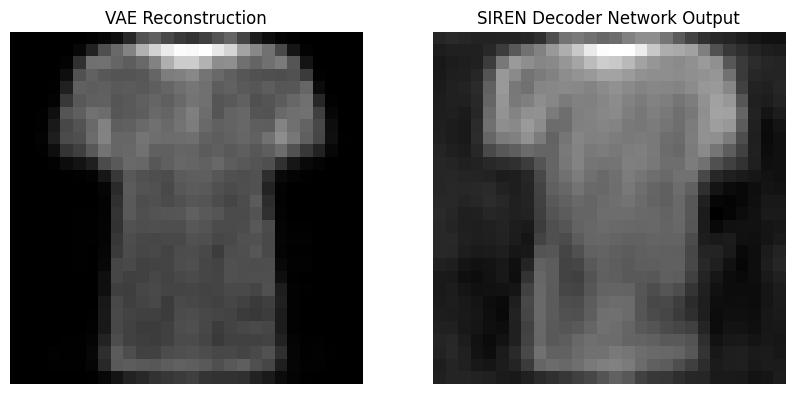

Epoch [9/20], Step [600/600], Loss: 1482.7814


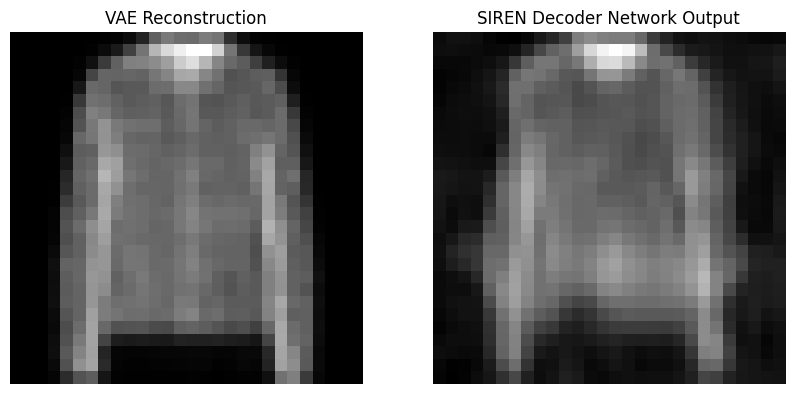

Epoch [10/20], Step [100/600], Loss: 1493.0850


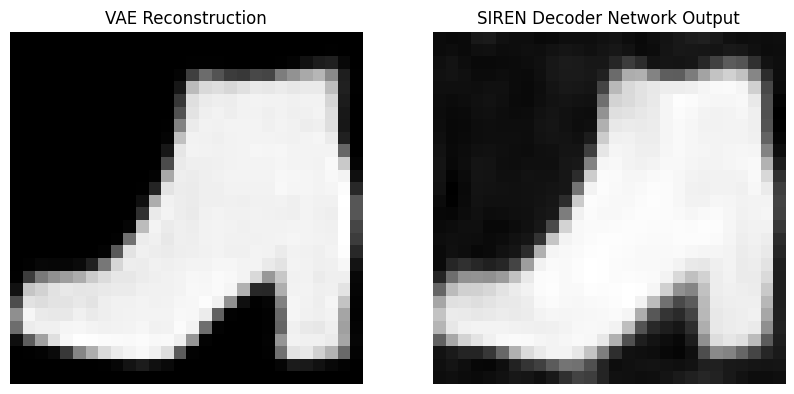

Epoch [10/20], Step [200/600], Loss: 1504.8682


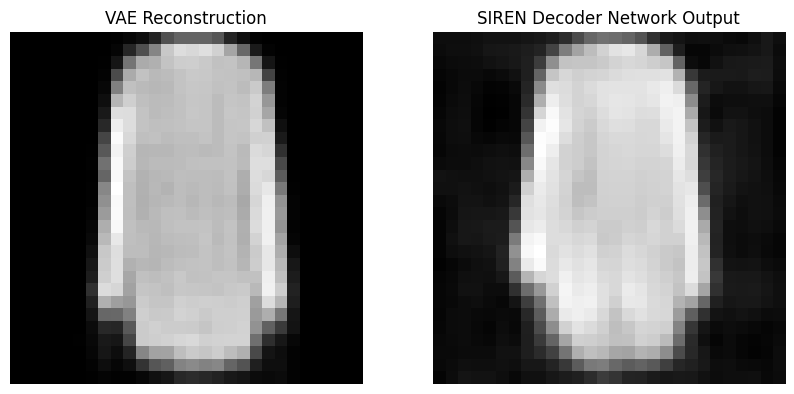

Epoch [10/20], Step [300/600], Loss: 1522.6809


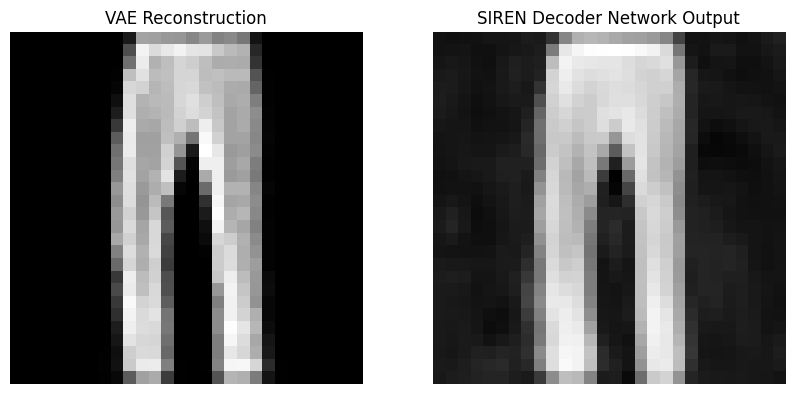

Epoch [10/20], Step [400/600], Loss: 1478.5704


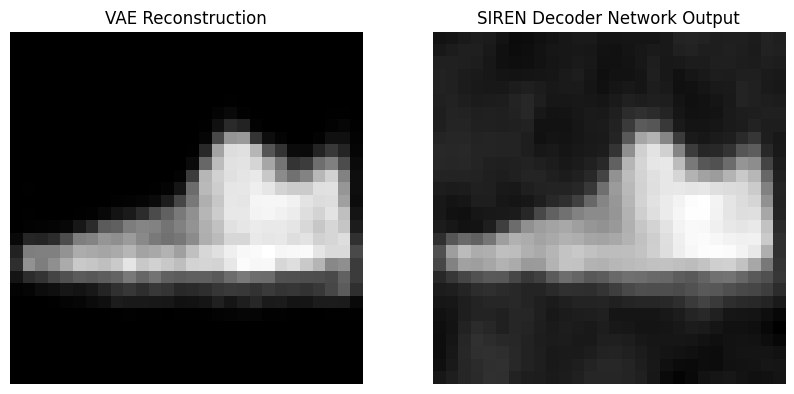

Epoch [10/20], Step [500/600], Loss: 1491.8478


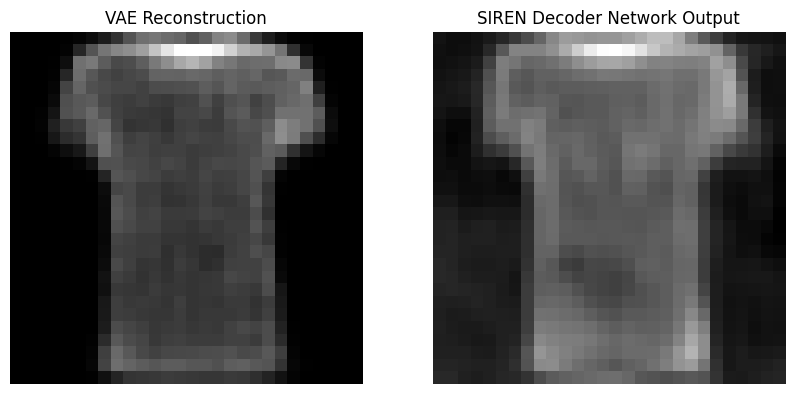

Epoch [10/20], Step [600/600], Loss: 1482.7819


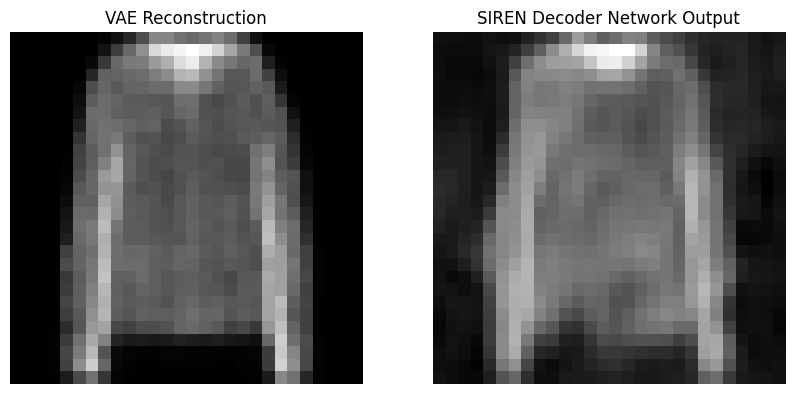

Epoch [11/20], Step [100/600], Loss: 1493.0851


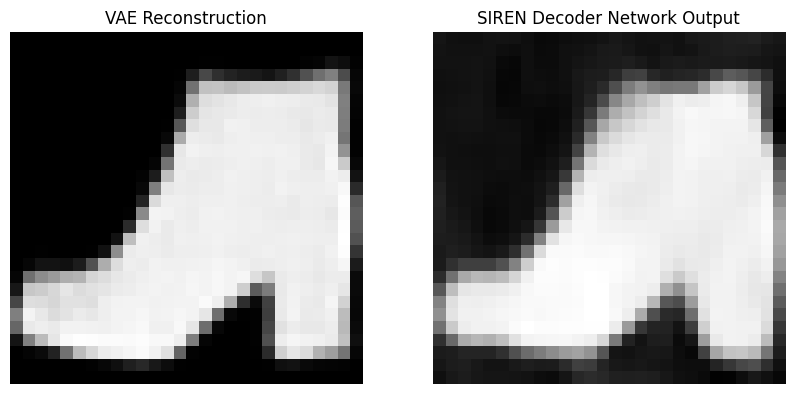

Epoch [11/20], Step [200/600], Loss: 1504.8682


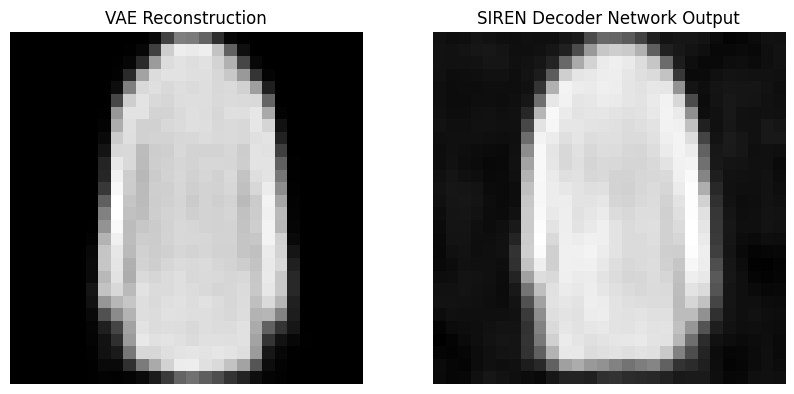

Epoch [11/20], Step [300/600], Loss: 1522.6801


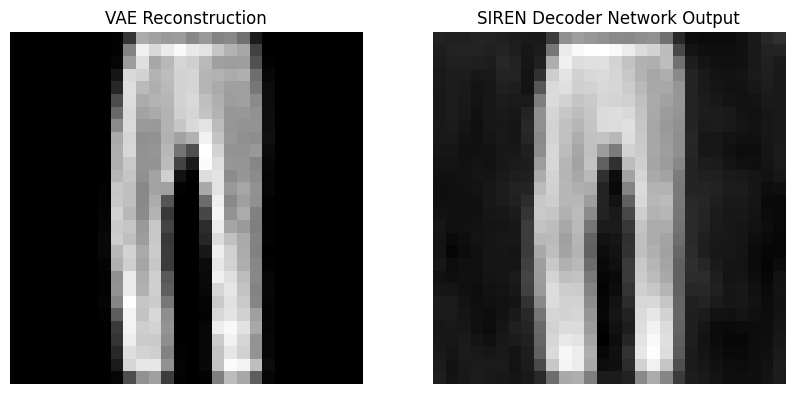

Epoch [11/20], Step [400/600], Loss: 1478.5708


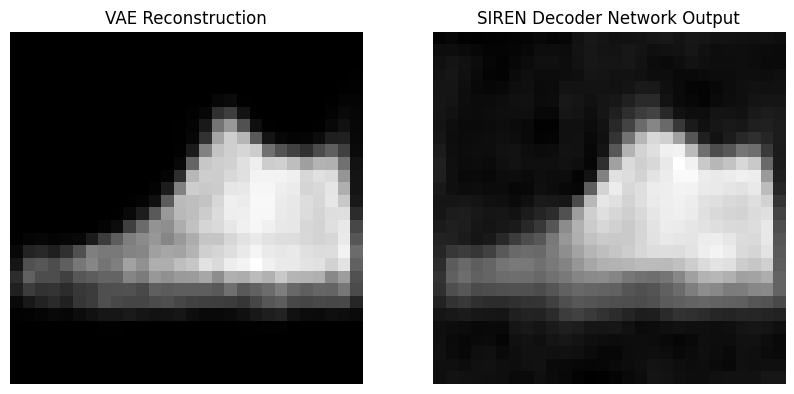

Epoch [11/20], Step [500/600], Loss: 1491.8463


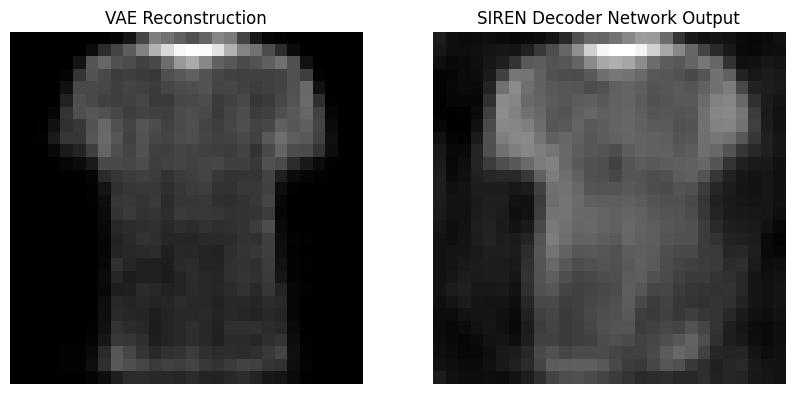

Epoch [11/20], Step [600/600], Loss: 1482.7808


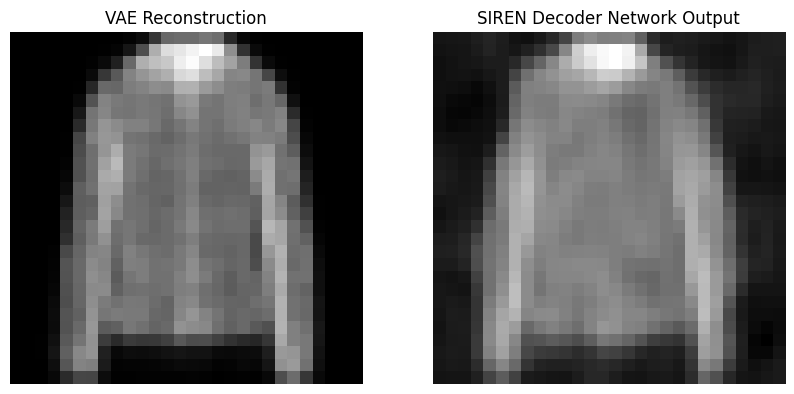

Epoch [12/20], Step [100/600], Loss: 1493.0851


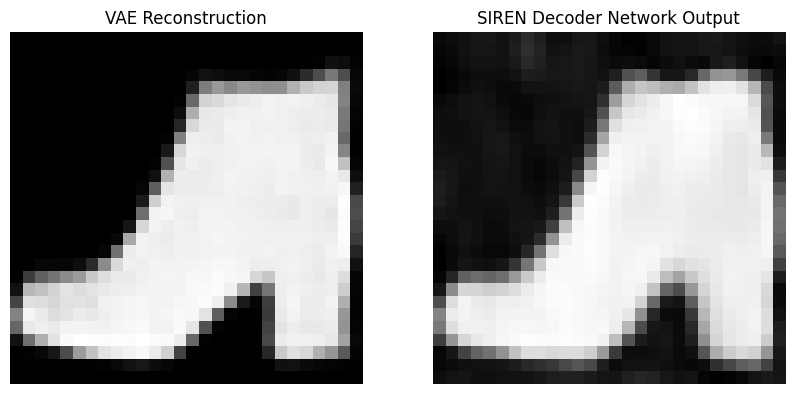

Epoch [12/20], Step [200/600], Loss: 1504.8678


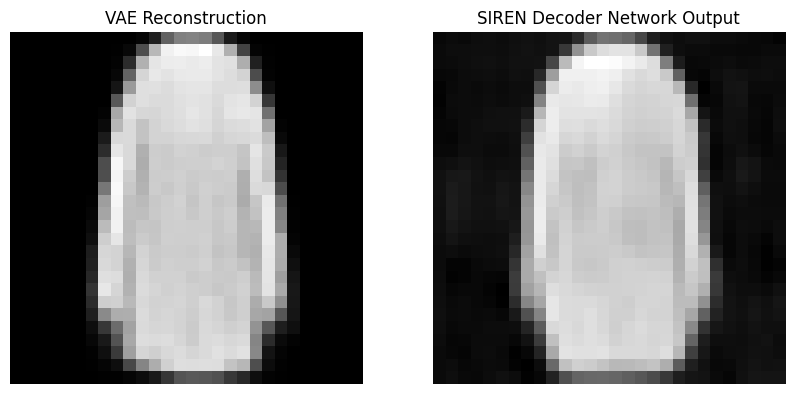

Epoch [12/20], Step [300/600], Loss: 1522.6807


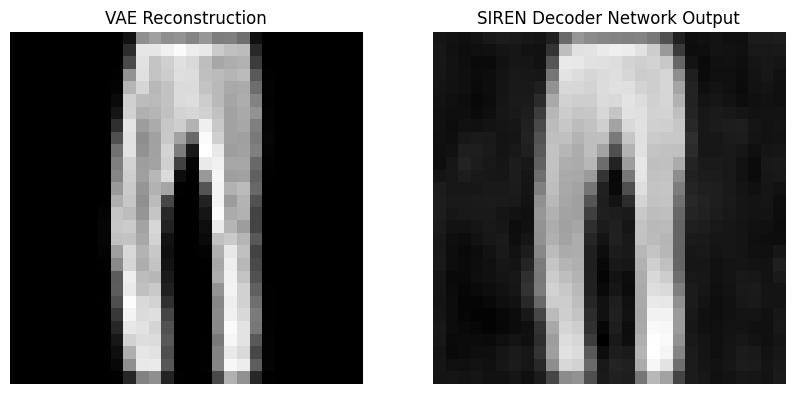

Epoch [12/20], Step [400/600], Loss: 1478.5707


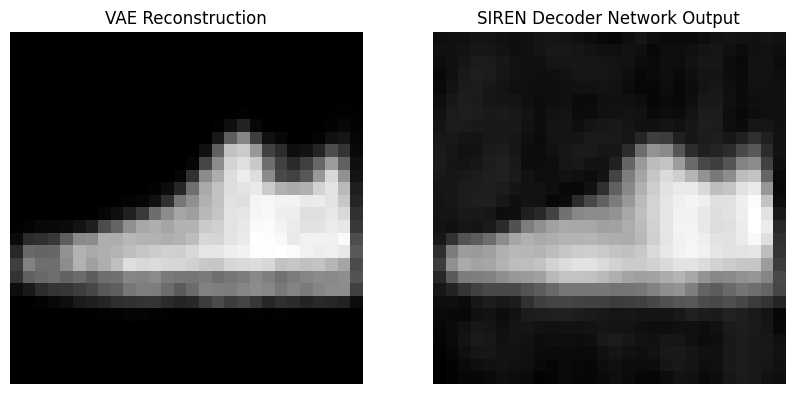

Epoch [12/20], Step [500/600], Loss: 1491.8468


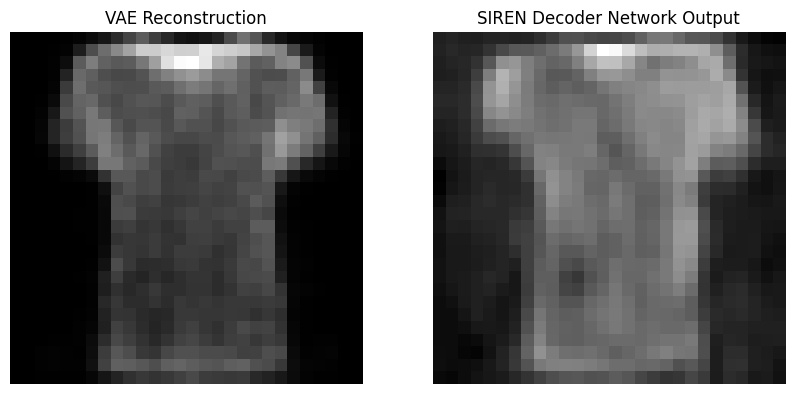

Epoch [12/20], Step [600/600], Loss: 1482.7809


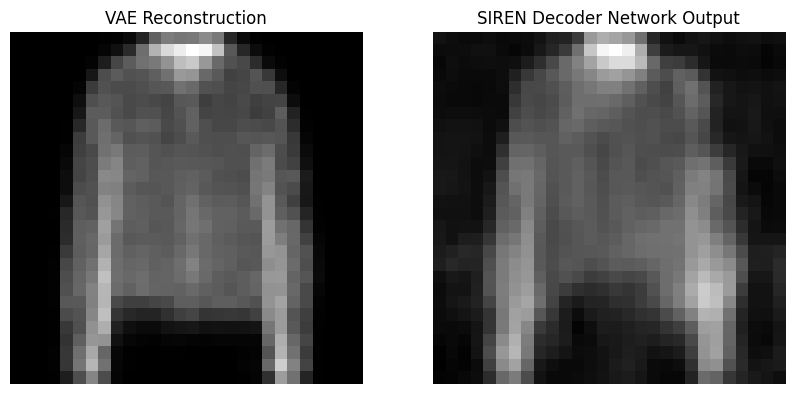

Epoch [13/20], Step [100/600], Loss: 1493.0861


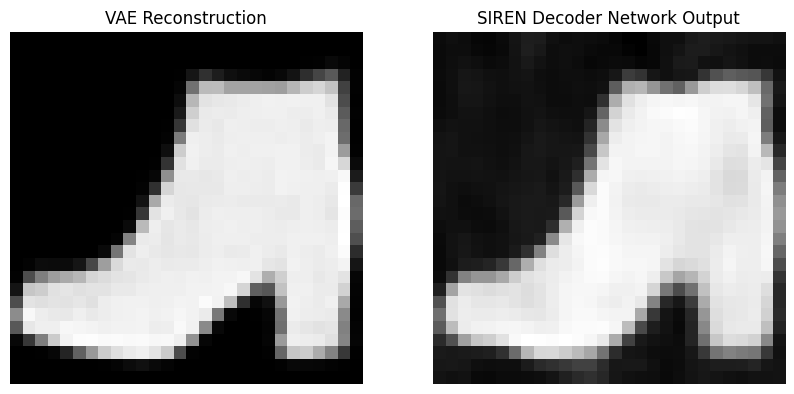

Epoch [13/20], Step [200/600], Loss: 1504.8684


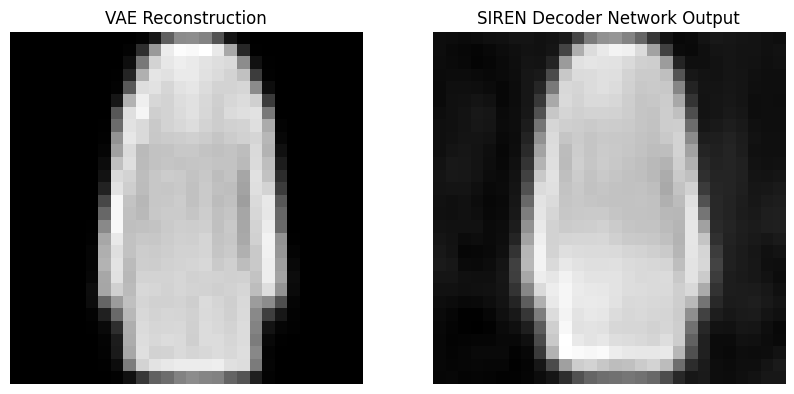

Epoch [13/20], Step [300/600], Loss: 1522.6813


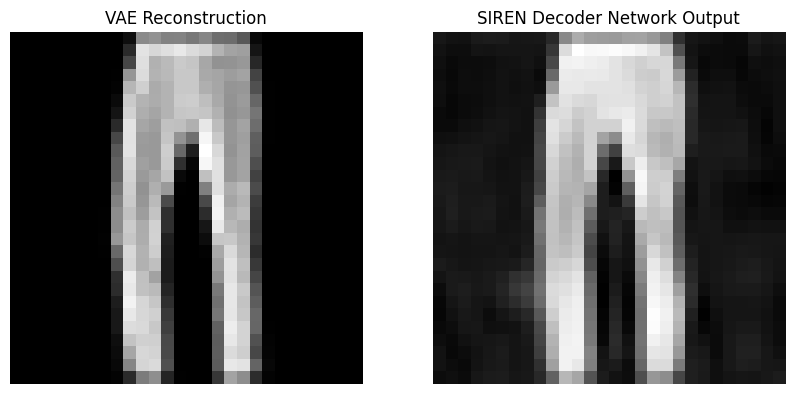

Epoch [13/20], Step [400/600], Loss: 1478.5710


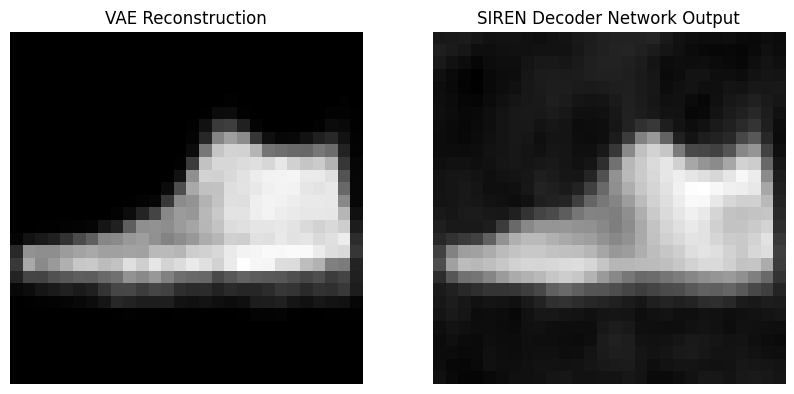

Epoch [13/20], Step [500/600], Loss: 1491.8470


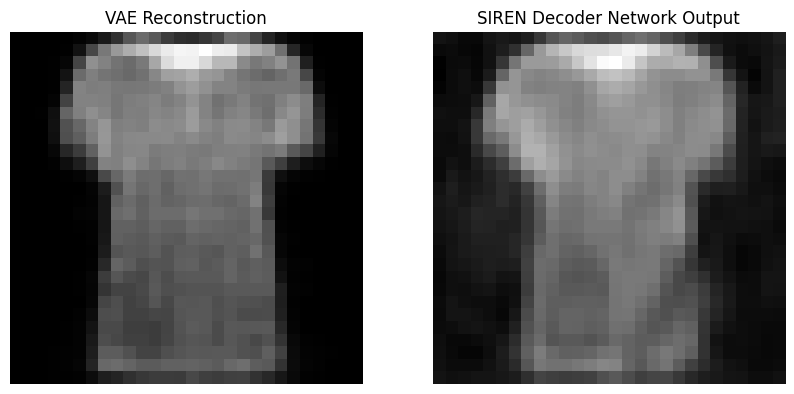

Epoch [13/20], Step [600/600], Loss: 1482.7808


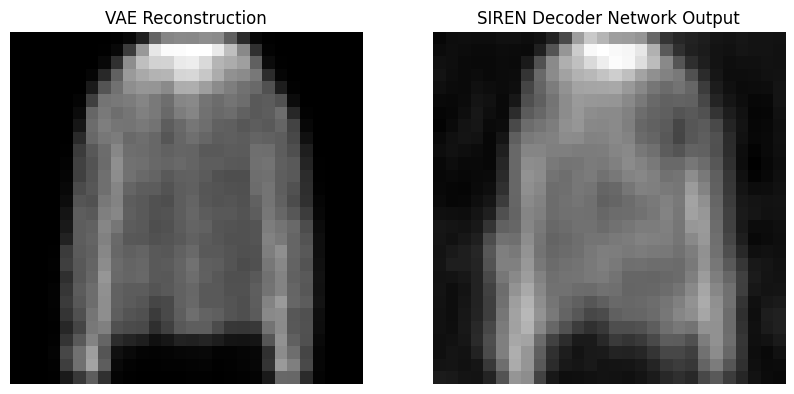

Epoch [14/20], Step [100/600], Loss: 1493.0854


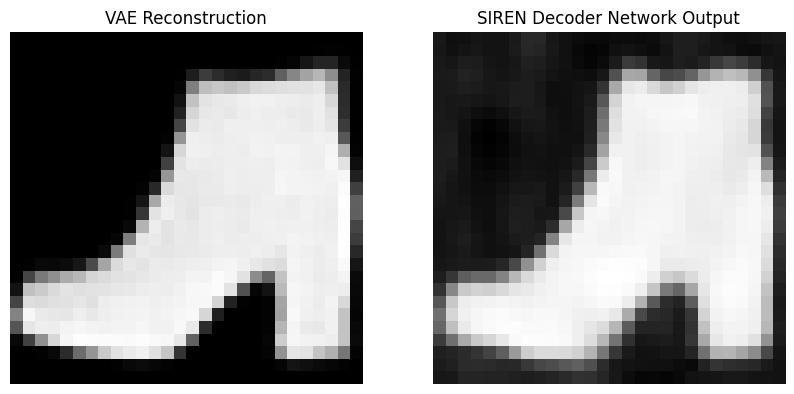

Epoch [14/20], Step [200/600], Loss: 1504.8678


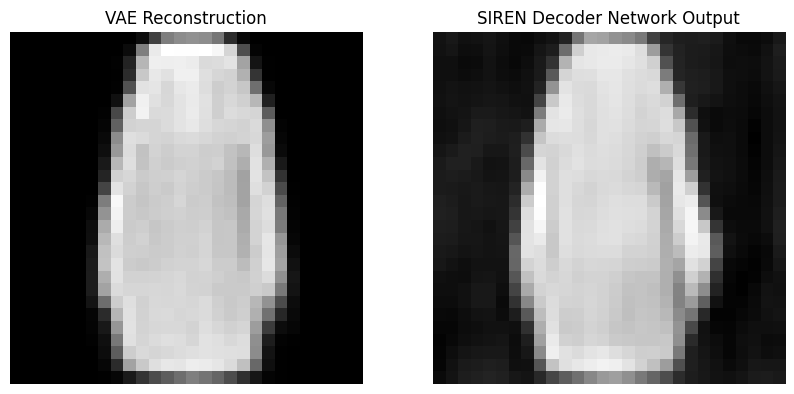

Epoch [14/20], Step [300/600], Loss: 1522.6812


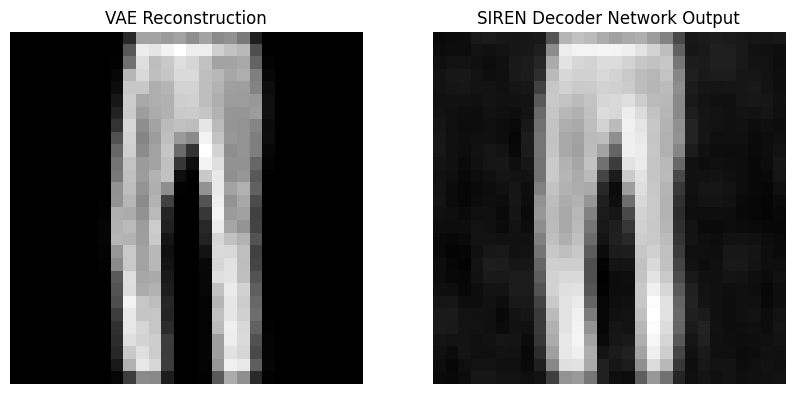

Epoch [14/20], Step [400/600], Loss: 1478.5704


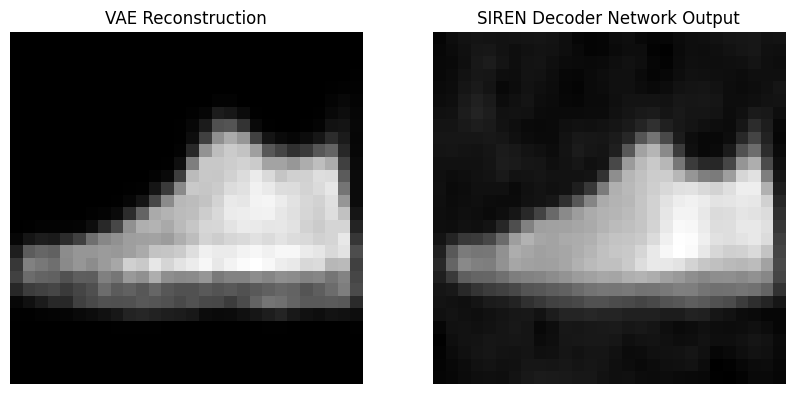

Epoch [14/20], Step [500/600], Loss: 1491.8472


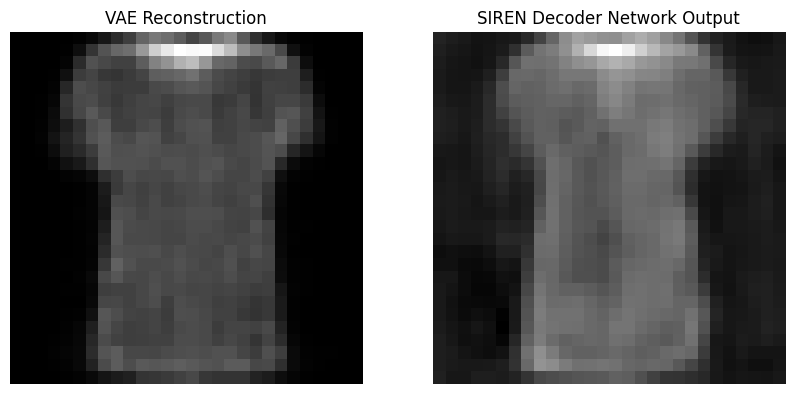

Epoch [14/20], Step [600/600], Loss: 1482.7806


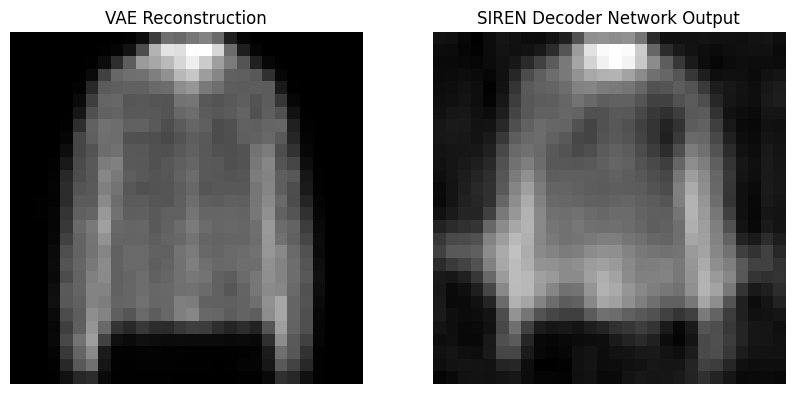

Epoch [15/20], Step [100/600], Loss: 1493.0852


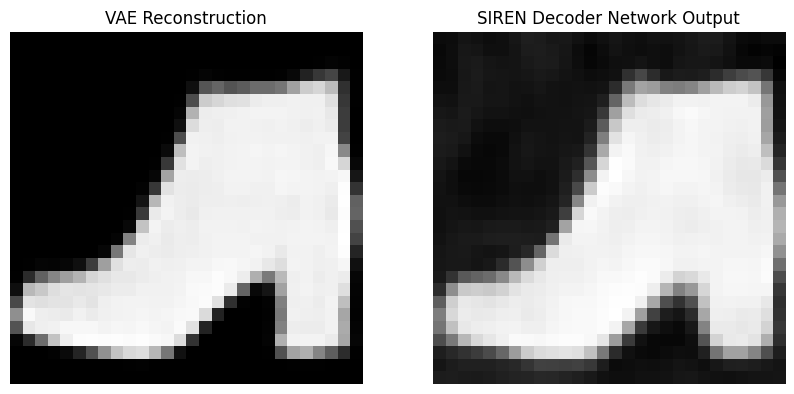

Epoch [15/20], Step [200/600], Loss: 1504.8676


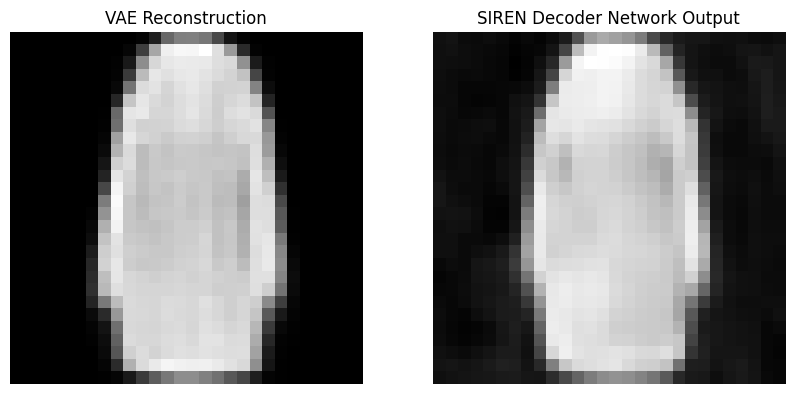

Epoch [15/20], Step [300/600], Loss: 1522.6804


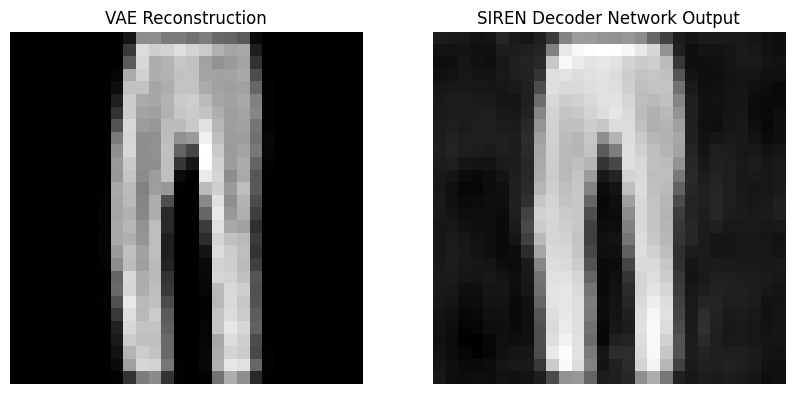

Epoch [15/20], Step [400/600], Loss: 1478.5701


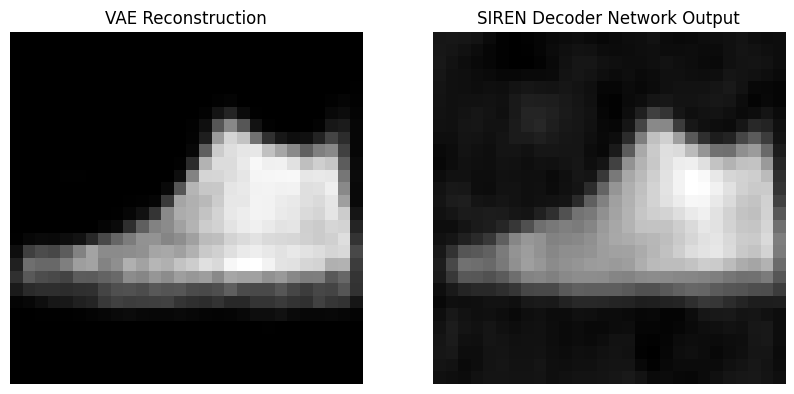

Epoch [15/20], Step [500/600], Loss: 1491.8479


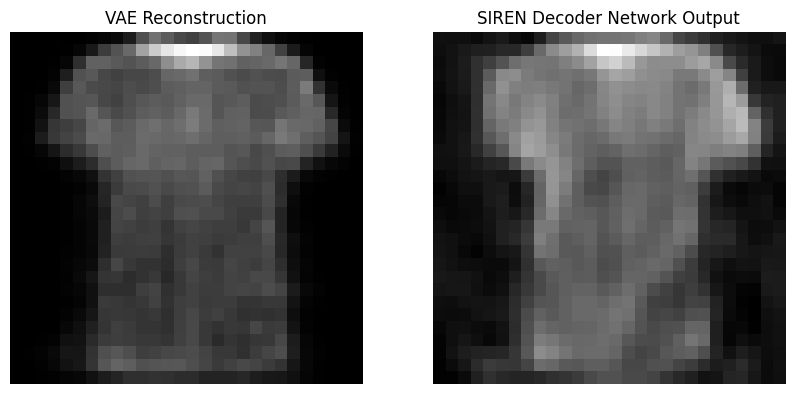

Epoch [15/20], Step [600/600], Loss: 1482.7808


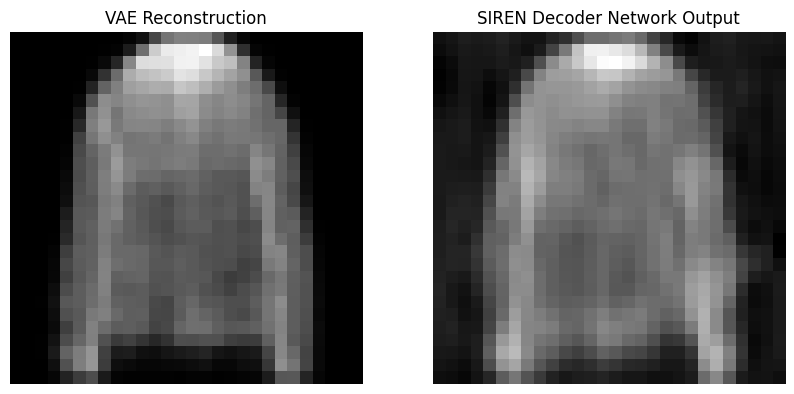

Epoch [16/20], Step [100/600], Loss: 1493.0856


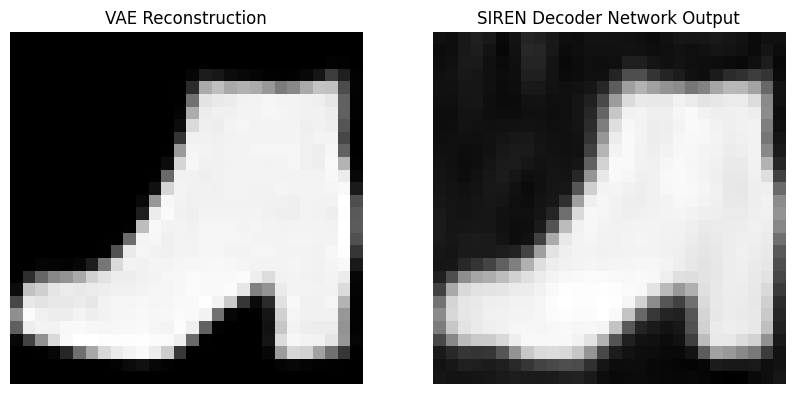

Epoch [16/20], Step [200/600], Loss: 1504.8684


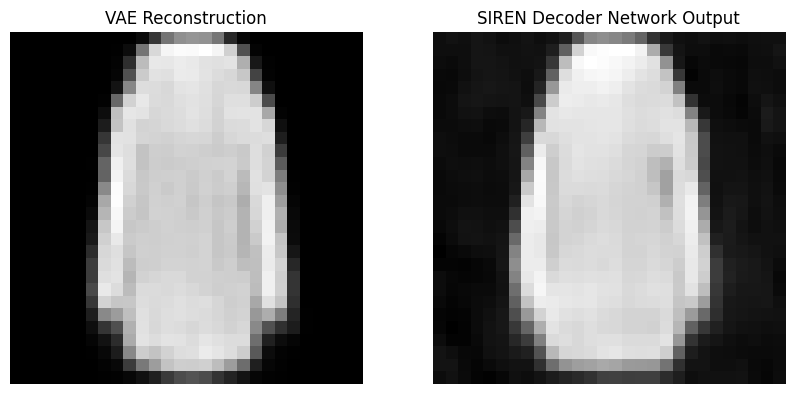

Epoch [16/20], Step [300/600], Loss: 1522.6803


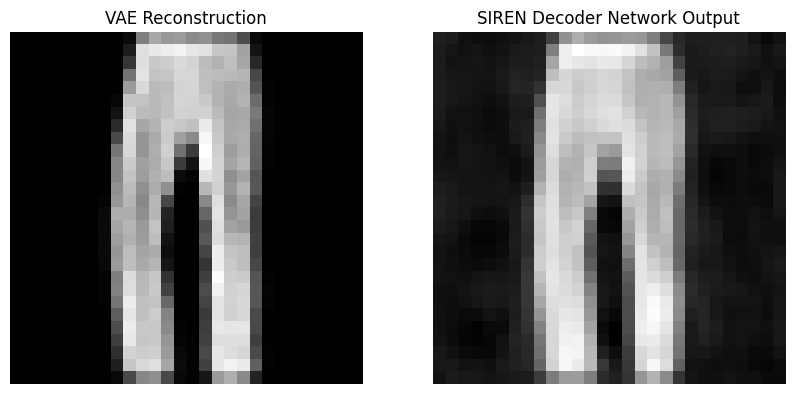

Epoch [16/20], Step [400/600], Loss: 1478.5712


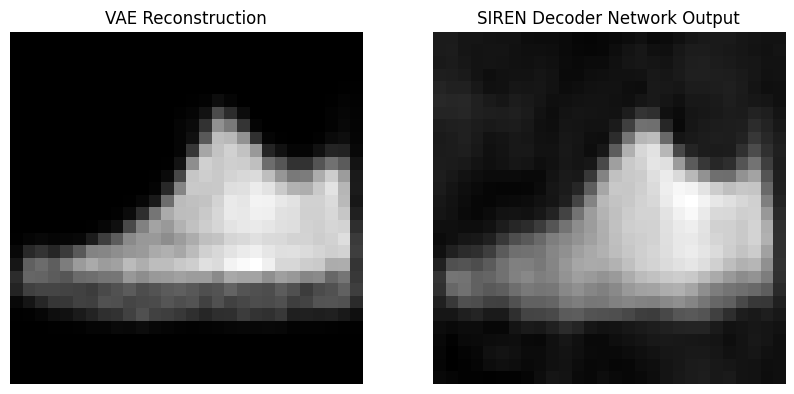

Epoch [16/20], Step [500/600], Loss: 1491.8467


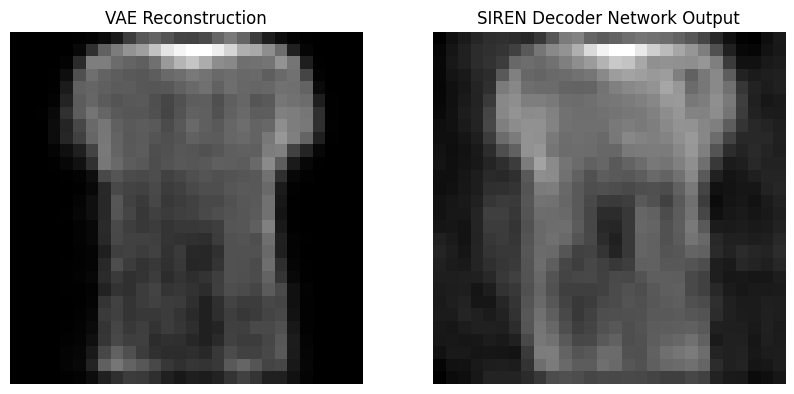

Epoch [16/20], Step [600/600], Loss: 1482.7812


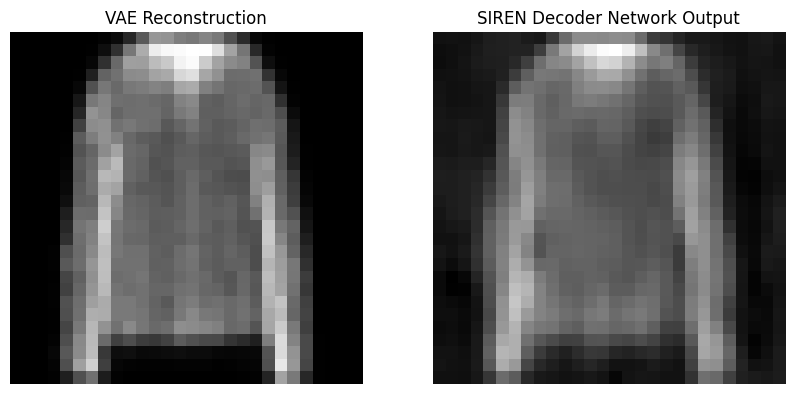

Epoch [17/20], Step [100/600], Loss: 1493.0853


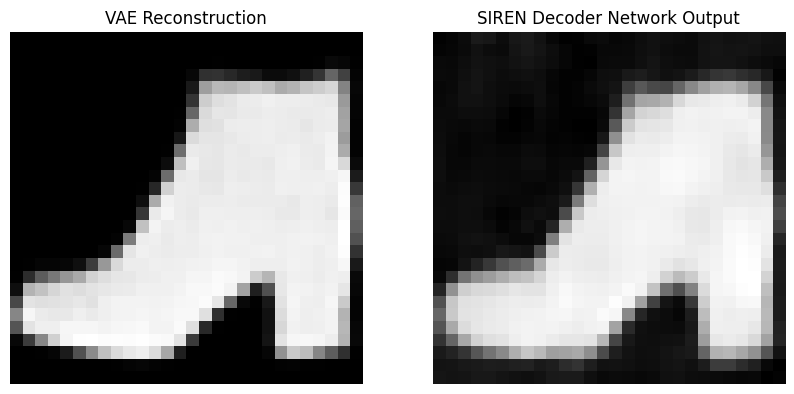

Epoch [17/20], Step [200/600], Loss: 1504.8677


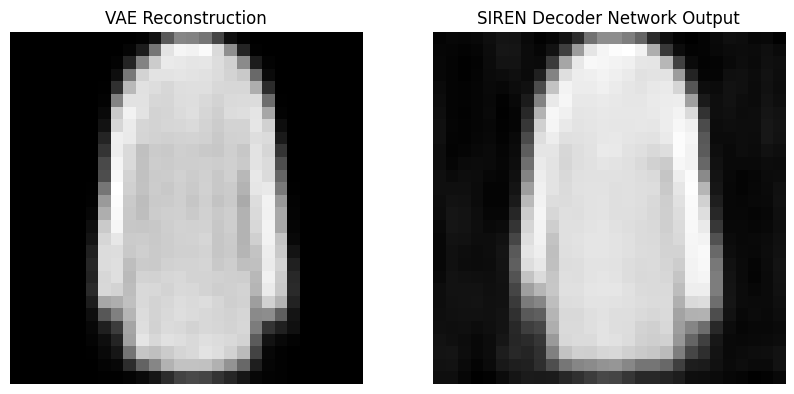

Epoch [17/20], Step [300/600], Loss: 1522.6804


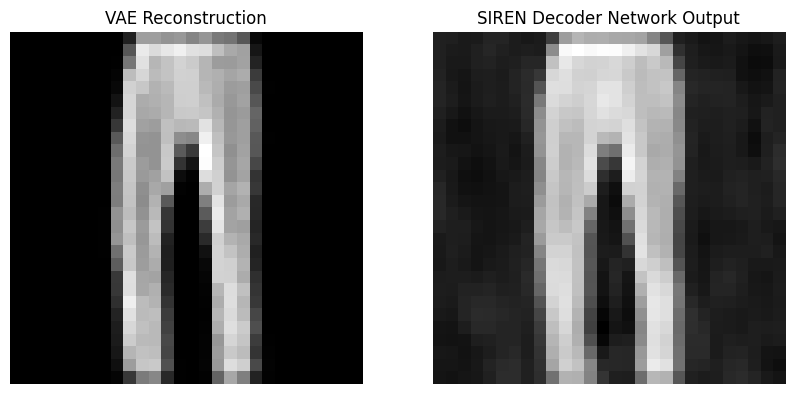

Epoch [17/20], Step [400/600], Loss: 1478.5704


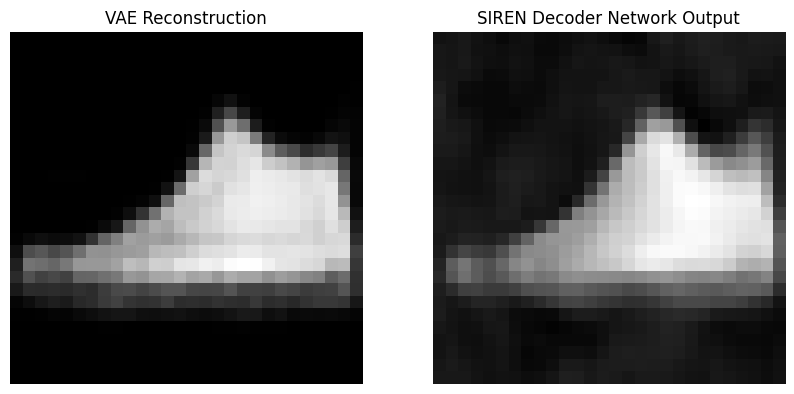

Epoch [17/20], Step [500/600], Loss: 1491.8467


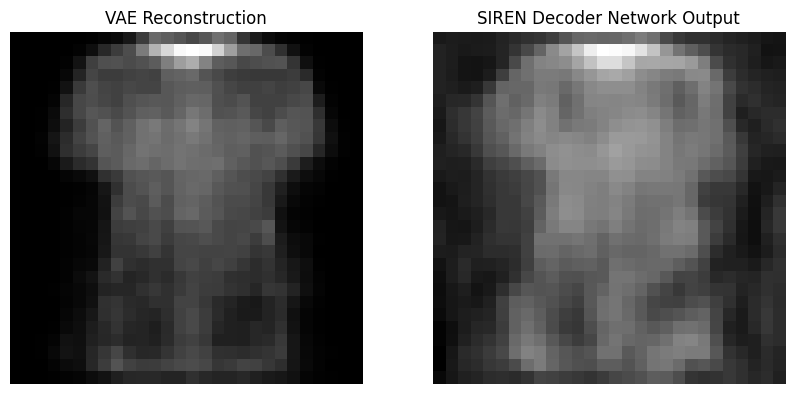

Epoch [17/20], Step [600/600], Loss: 1482.7810


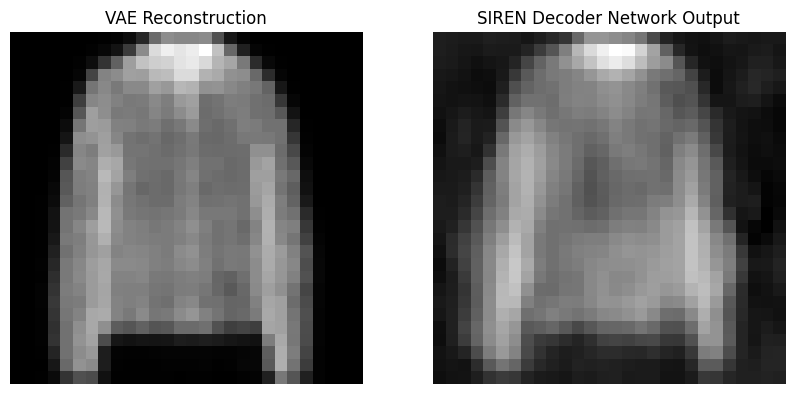

Epoch [18/20], Step [100/600], Loss: 1493.0847


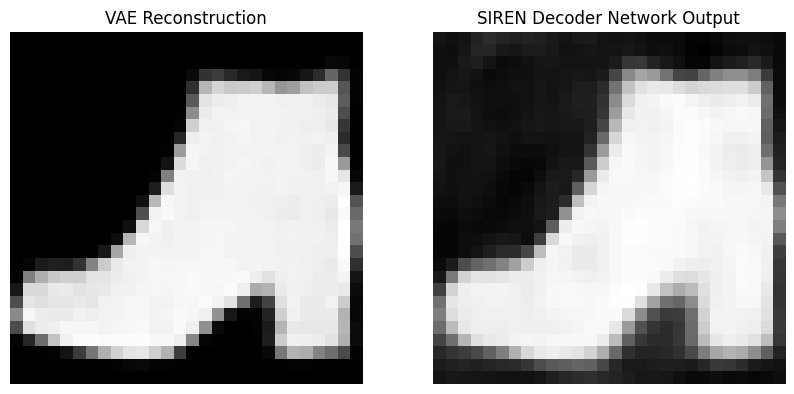

Epoch [18/20], Step [200/600], Loss: 1504.8687


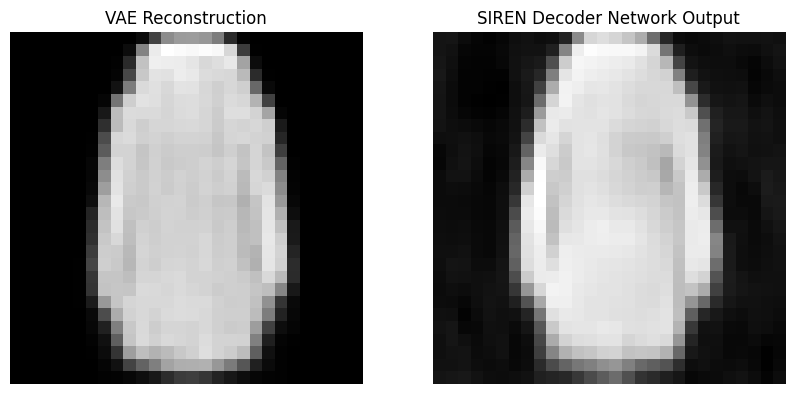

Epoch [18/20], Step [300/600], Loss: 1522.6804


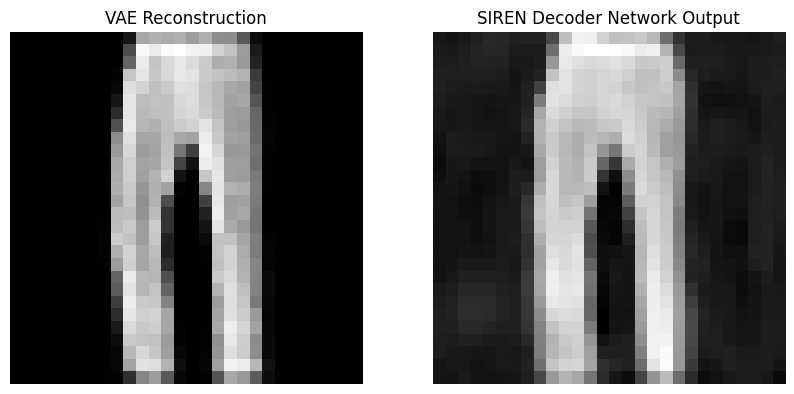

Epoch [18/20], Step [400/600], Loss: 1478.5706


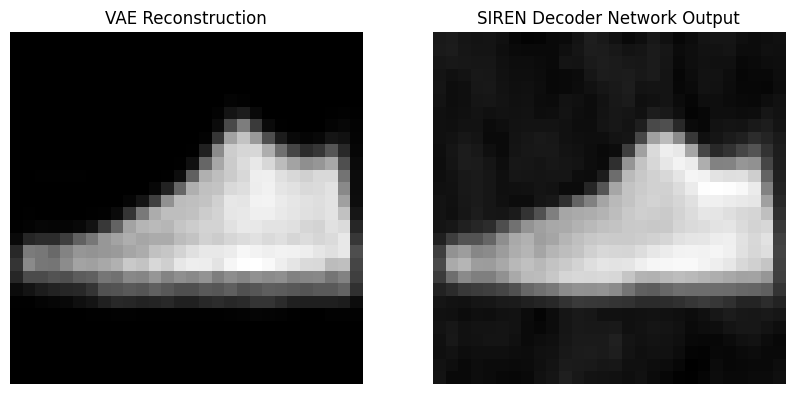

Epoch [18/20], Step [500/600], Loss: 1491.8473


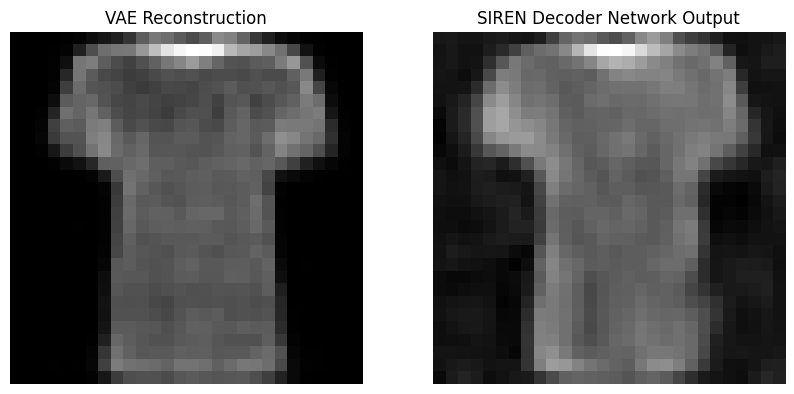

Epoch [18/20], Step [600/600], Loss: 1482.7808


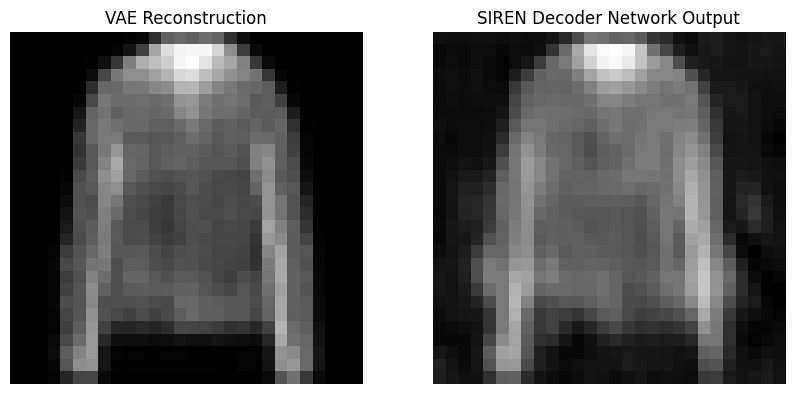

Epoch [19/20], Step [100/600], Loss: 1493.0853


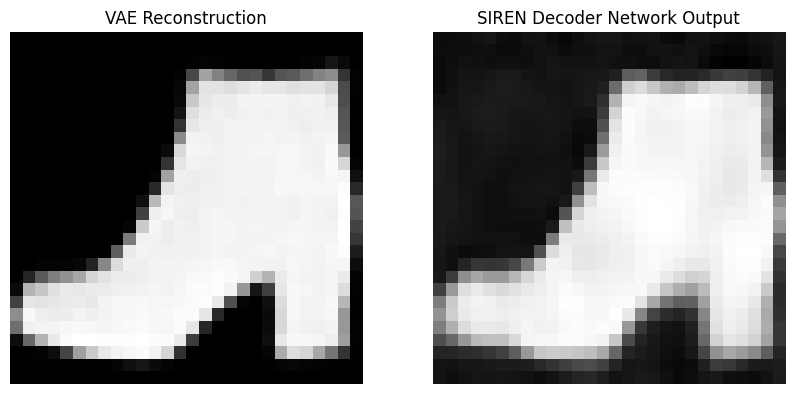

Epoch [19/20], Step [200/600], Loss: 1504.8673


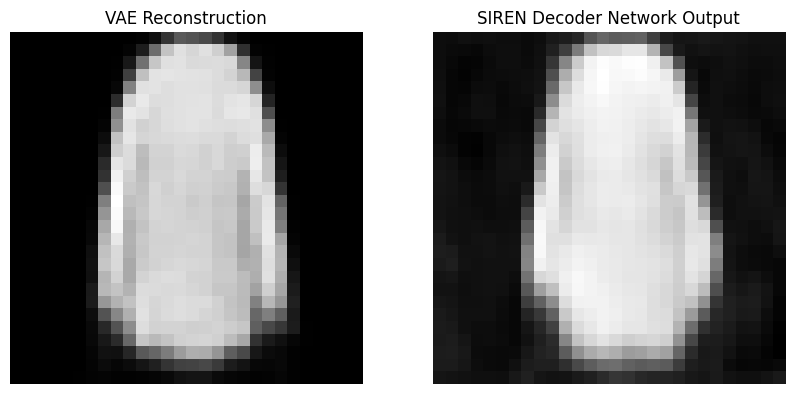

Epoch [19/20], Step [300/600], Loss: 1522.6808


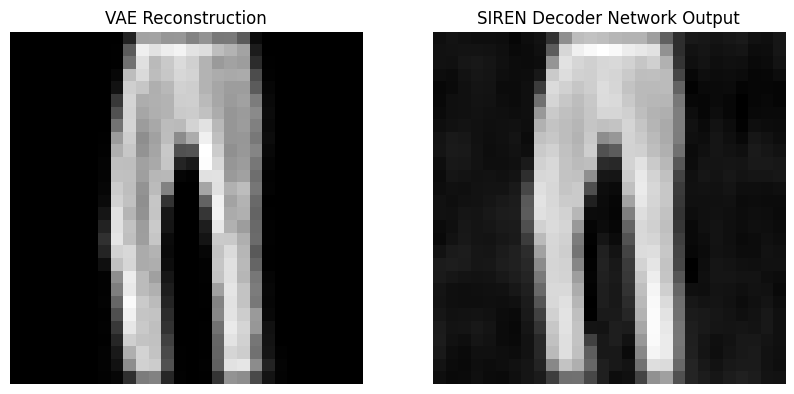

Epoch [19/20], Step [400/600], Loss: 1478.5709


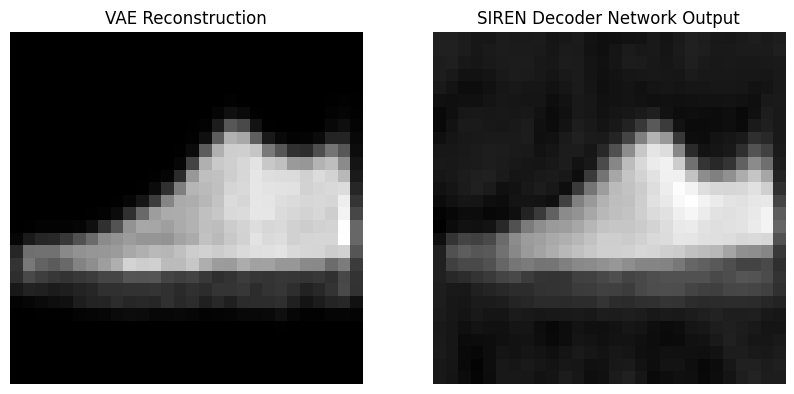

Epoch [19/20], Step [500/600], Loss: 1491.8475


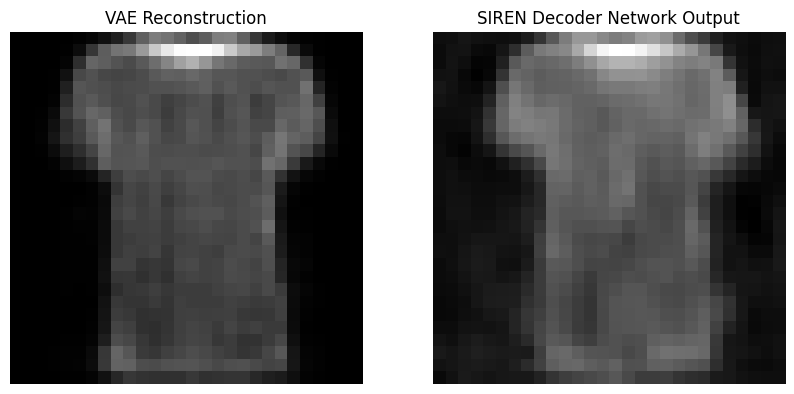

Epoch [19/20], Step [600/600], Loss: 1482.7811


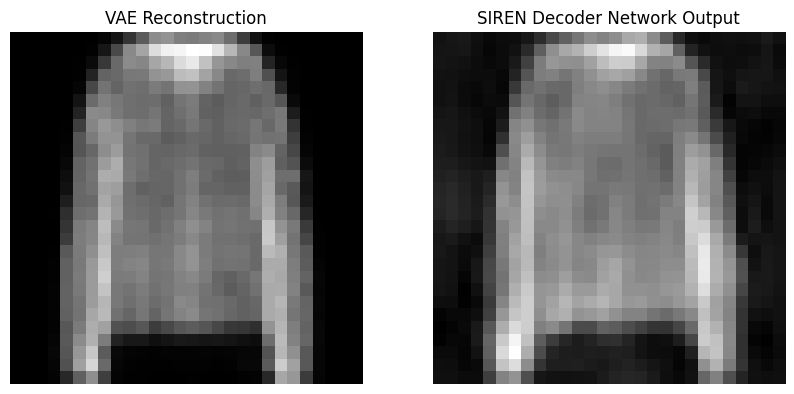

Epoch [20/20], Step [100/600], Loss: 1493.0850


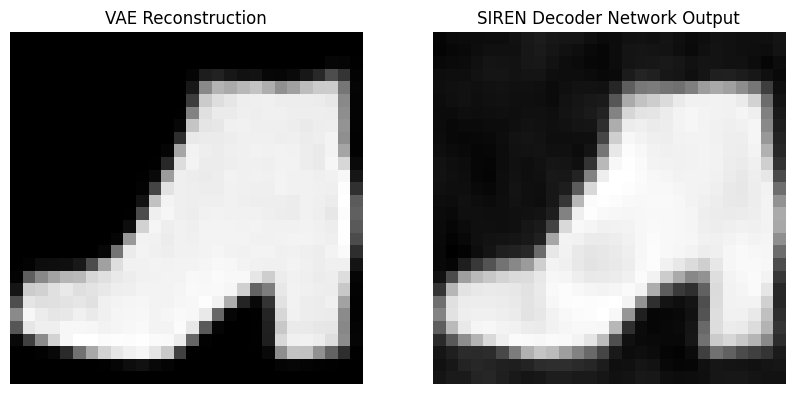

Epoch [20/20], Step [200/600], Loss: 1504.8673


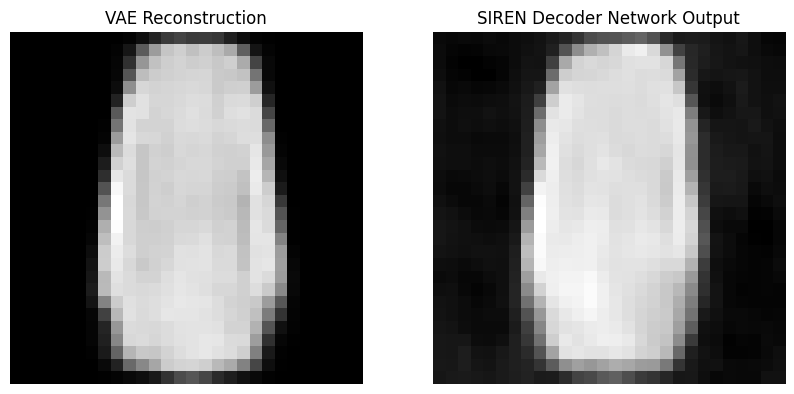

Epoch [20/20], Step [300/600], Loss: 1522.6808


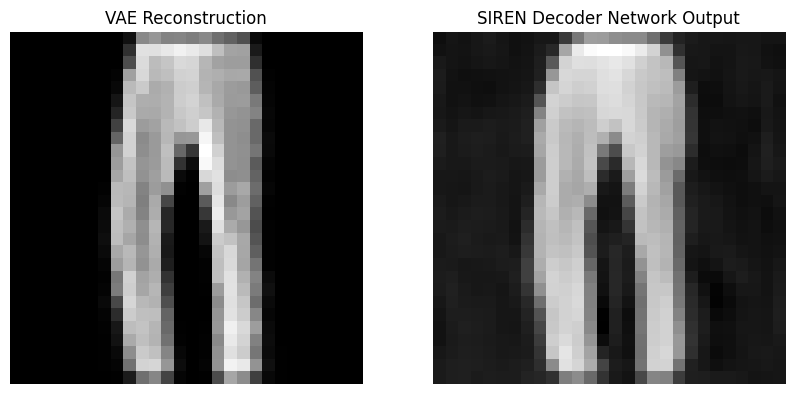

Epoch [20/20], Step [400/600], Loss: 1478.5697


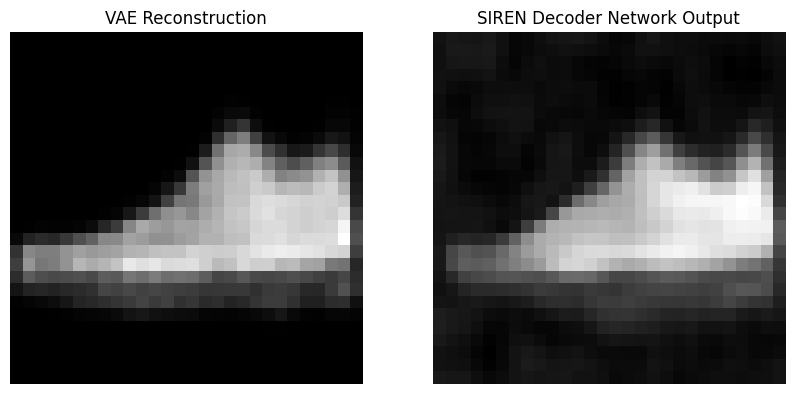

Epoch [20/20], Step [500/600], Loss: 1491.8470


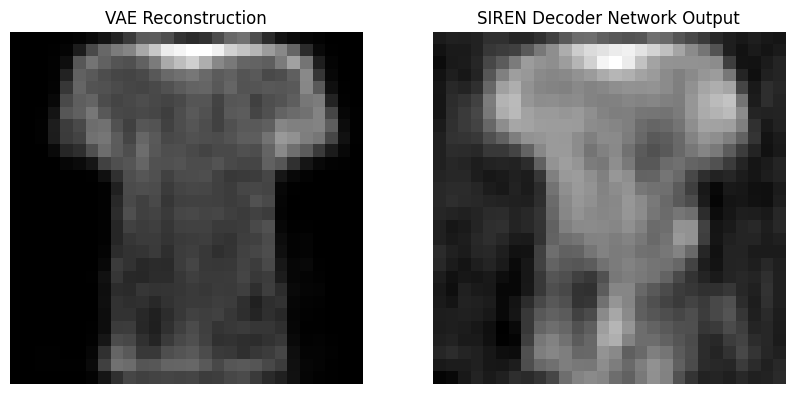

Epoch [20/20], Step [600/600], Loss: 1482.7806


In [76]:
for param in model.vae.parameters():
    param.requires_grad = False  # Freeze the VAE's parameters

# Initialize optimizer only for SIREN Decoder Network
optimizer = torch.optim.Adam(model.decoder.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(train_loader):
        images = images.to(device)

        z, mu, logvar = model.vae.encode(images)  # Get latent representation z from VAE

        coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)
        coords = coords.unsqueeze(0).repeat(images.size(0), 1, 1)
        z_expanded = z.unsqueeze(1).repeat(1, 784, 1)

        vae_reconstruction = model.vae.decode(z)

        decoder_image, _ = model.decoder(z_expanded, coords)  # Generate image

        reconst_loss = F.mse_loss(decoder_image.view(-1), vae_reconstruction.view(-1))  # Compare generated vs VAE image
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = reconst_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            # Visualize VAE reconstruction and SIREN Decoder output
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            # VAE reconstruction
            axes[0].imshow(vae_reconstruction[0].cpu().detach().numpy().squeeze(), cmap='gray')
            axes[0].set_title("VAE Reconstruction")
            axes[0].axis('off')

            # Decoder output
            axes[1].imshow(decoder_image[0].cpu().detach().numpy().reshape(28, 28), cmap='gray')
            axes[1].set_title("SIREN Decoder Network Output")
            axes[1].axis('off')

            plt.show()

            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

#### Visualize the SIREN Decoder output

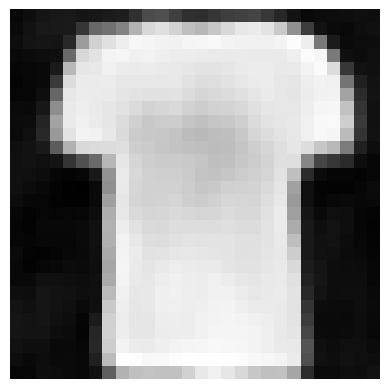

In [77]:
model.eval()
z_dim = 64
with torch.no_grad():
    random_idx = random.randint(0, len(test_loader) - 1)  # Random index
    imgs, _ = list(test_loader)[random_idx]  # Grab the image batch at the random index
    imgs = imgs.to(device)

    # Get the latent vector of the real image
    z, _, _ = model.vae.encode(imgs)

    # Use the first image's latent vector (z[0]) to generate a new image
    z_single = z[0].unsqueeze(0)

    # Generate coordinates for each pixel in the image (28x28)
    coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)
    coords_expanded = coords.unsqueeze(0)

    z_expanded = z_single.unsqueeze(1).repeat(1, 784, 1)

    # Pass latent vector and coordinates to the decoder
    decoder_image, _ = model.decoder(z_expanded, coords_expanded)

    # Reshape decoder output to form the 28x28 image
    generated_image = decoder_image.view(28, 28).cpu().numpy()

    plt.imshow(generated_image, cmap='gray')
    plt.axis('off')
    plt.show()

#### Compare the All Decoders output

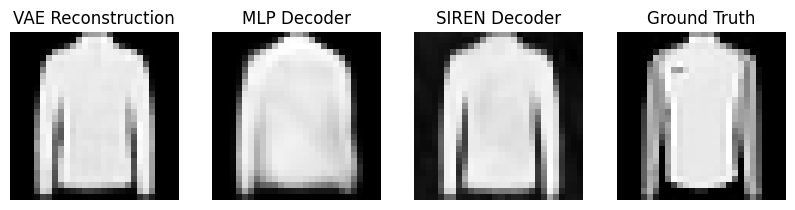

In [162]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

model.eval()
z_dim = 64
with torch.no_grad():
  random_idx = random.randint(0, len(test_loader) - 1)
  imgs, _ = list(test_loader)[random_idx]
  imgs = imgs.to(device)

  z, _, _ = model.vae.encode(imgs)
  z_single = z[0].unsqueeze(0)
  coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)

  coords_expanded = coords.unsqueeze(0)

  z_expanded = z_single.unsqueeze(1).repeat(1, 784, 1)

  siren_decoder_image, _ = model.decoder(z_expanded, coords_expanded)
  siren_generated_image = siren_decoder_image.view(28, 28).cpu().numpy()

  MLPVaeModel.eval()
  z, _, _ = MLPVaeModel.vae.encode(imgs)
  z_single = z[0].unsqueeze(0)
  coords = torch.stack([torch.tensor([i % 28, i // 28]).float() for i in range(784)], dim=0).to(device)

  coords_expanded = coords.unsqueeze(0)

  z_expanded = z_single.unsqueeze(1).repeat(1, 784, 1)

  mlp_decoder_image = MLPVaeModel.decoder(z_expanded, coords_expanded)
  mlp_generated_image = mlp_decoder_image.view(28, 28).cpu().numpy()

  vae_reconstruction = model.vae.decode(z)

# VAE reconstruction
axes[0].imshow(vae_reconstruction[0].cpu().detach().numpy().squeeze(), cmap='gray')
axes[0].set_title("VAE Reconstruction")
axes[0].axis('off')

# MLP Decoder network output
axes[1].imshow(mlp_generated_image, cmap='gray')
axes[1].set_title("MLP Decoder")
axes[1].axis('off')

# SIREN Decoder network output
axes[2].imshow(siren_generated_image, cmap='gray')
axes[2].set_title("SIREN Decoder")
axes[2].axis('off')

# Ground Truth output
axes[3].imshow(imgs[0].reshape(28,28), cmap='gray')
axes[3].set_title("Ground Truth")
axes[3].axis('off')

plt.show()